In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses, observableClasses
import datetime
import numpy as np
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy import stats
import pickle
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [29]:
dataset = baseClasses.Data()

In [3]:
ce1t = sensorClasses.Sensor(dataset, id=1017)
ce1i = sensorClasses.Sensor(dataset, id=1018)
ce1v = sensorClasses.Sensor(dataset, id=1019)
ce1truev = sensorClasses.Sensor(dataset, id=1020)
ce1status = sensorClasses.Sensor(dataset, id=1021)
ce2t = sensorClasses.Sensor(dataset, id=1022)
ce2i = sensorClasses.Sensor(dataset, id=1023)
ce2v = sensorClasses.Sensor(dataset, id=1024)
ce2truev = sensorClasses.Sensor(dataset, id=1025)
ce2status = sensorClasses.Sensor(dataset, id=1026)
ce3t = sensorClasses.Sensor(dataset, id=1027)
ce3i = sensorClasses.Sensor(dataset, id=1028)
ce3v = sensorClasses.Sensor(dataset, id=1029)
ce3truev = sensorClasses.Sensor(dataset, id=1030)
ce3status = sensorClasses.Sensor(dataset, id=1031)
ce4t = sensorClasses.Sensor(dataset, id=1032)
ce4i = sensorClasses.Sensor(dataset, id=1033)
ce4v = sensorClasses.Sensor(dataset, id=1034)
ce4truev = sensorClasses.Sensor(dataset, id=1035)
ce4status = sensorClasses.Sensor(dataset, id=1036)


# Cold Electronics Status

The changes in the operation mode of the 4 CE during the whole run

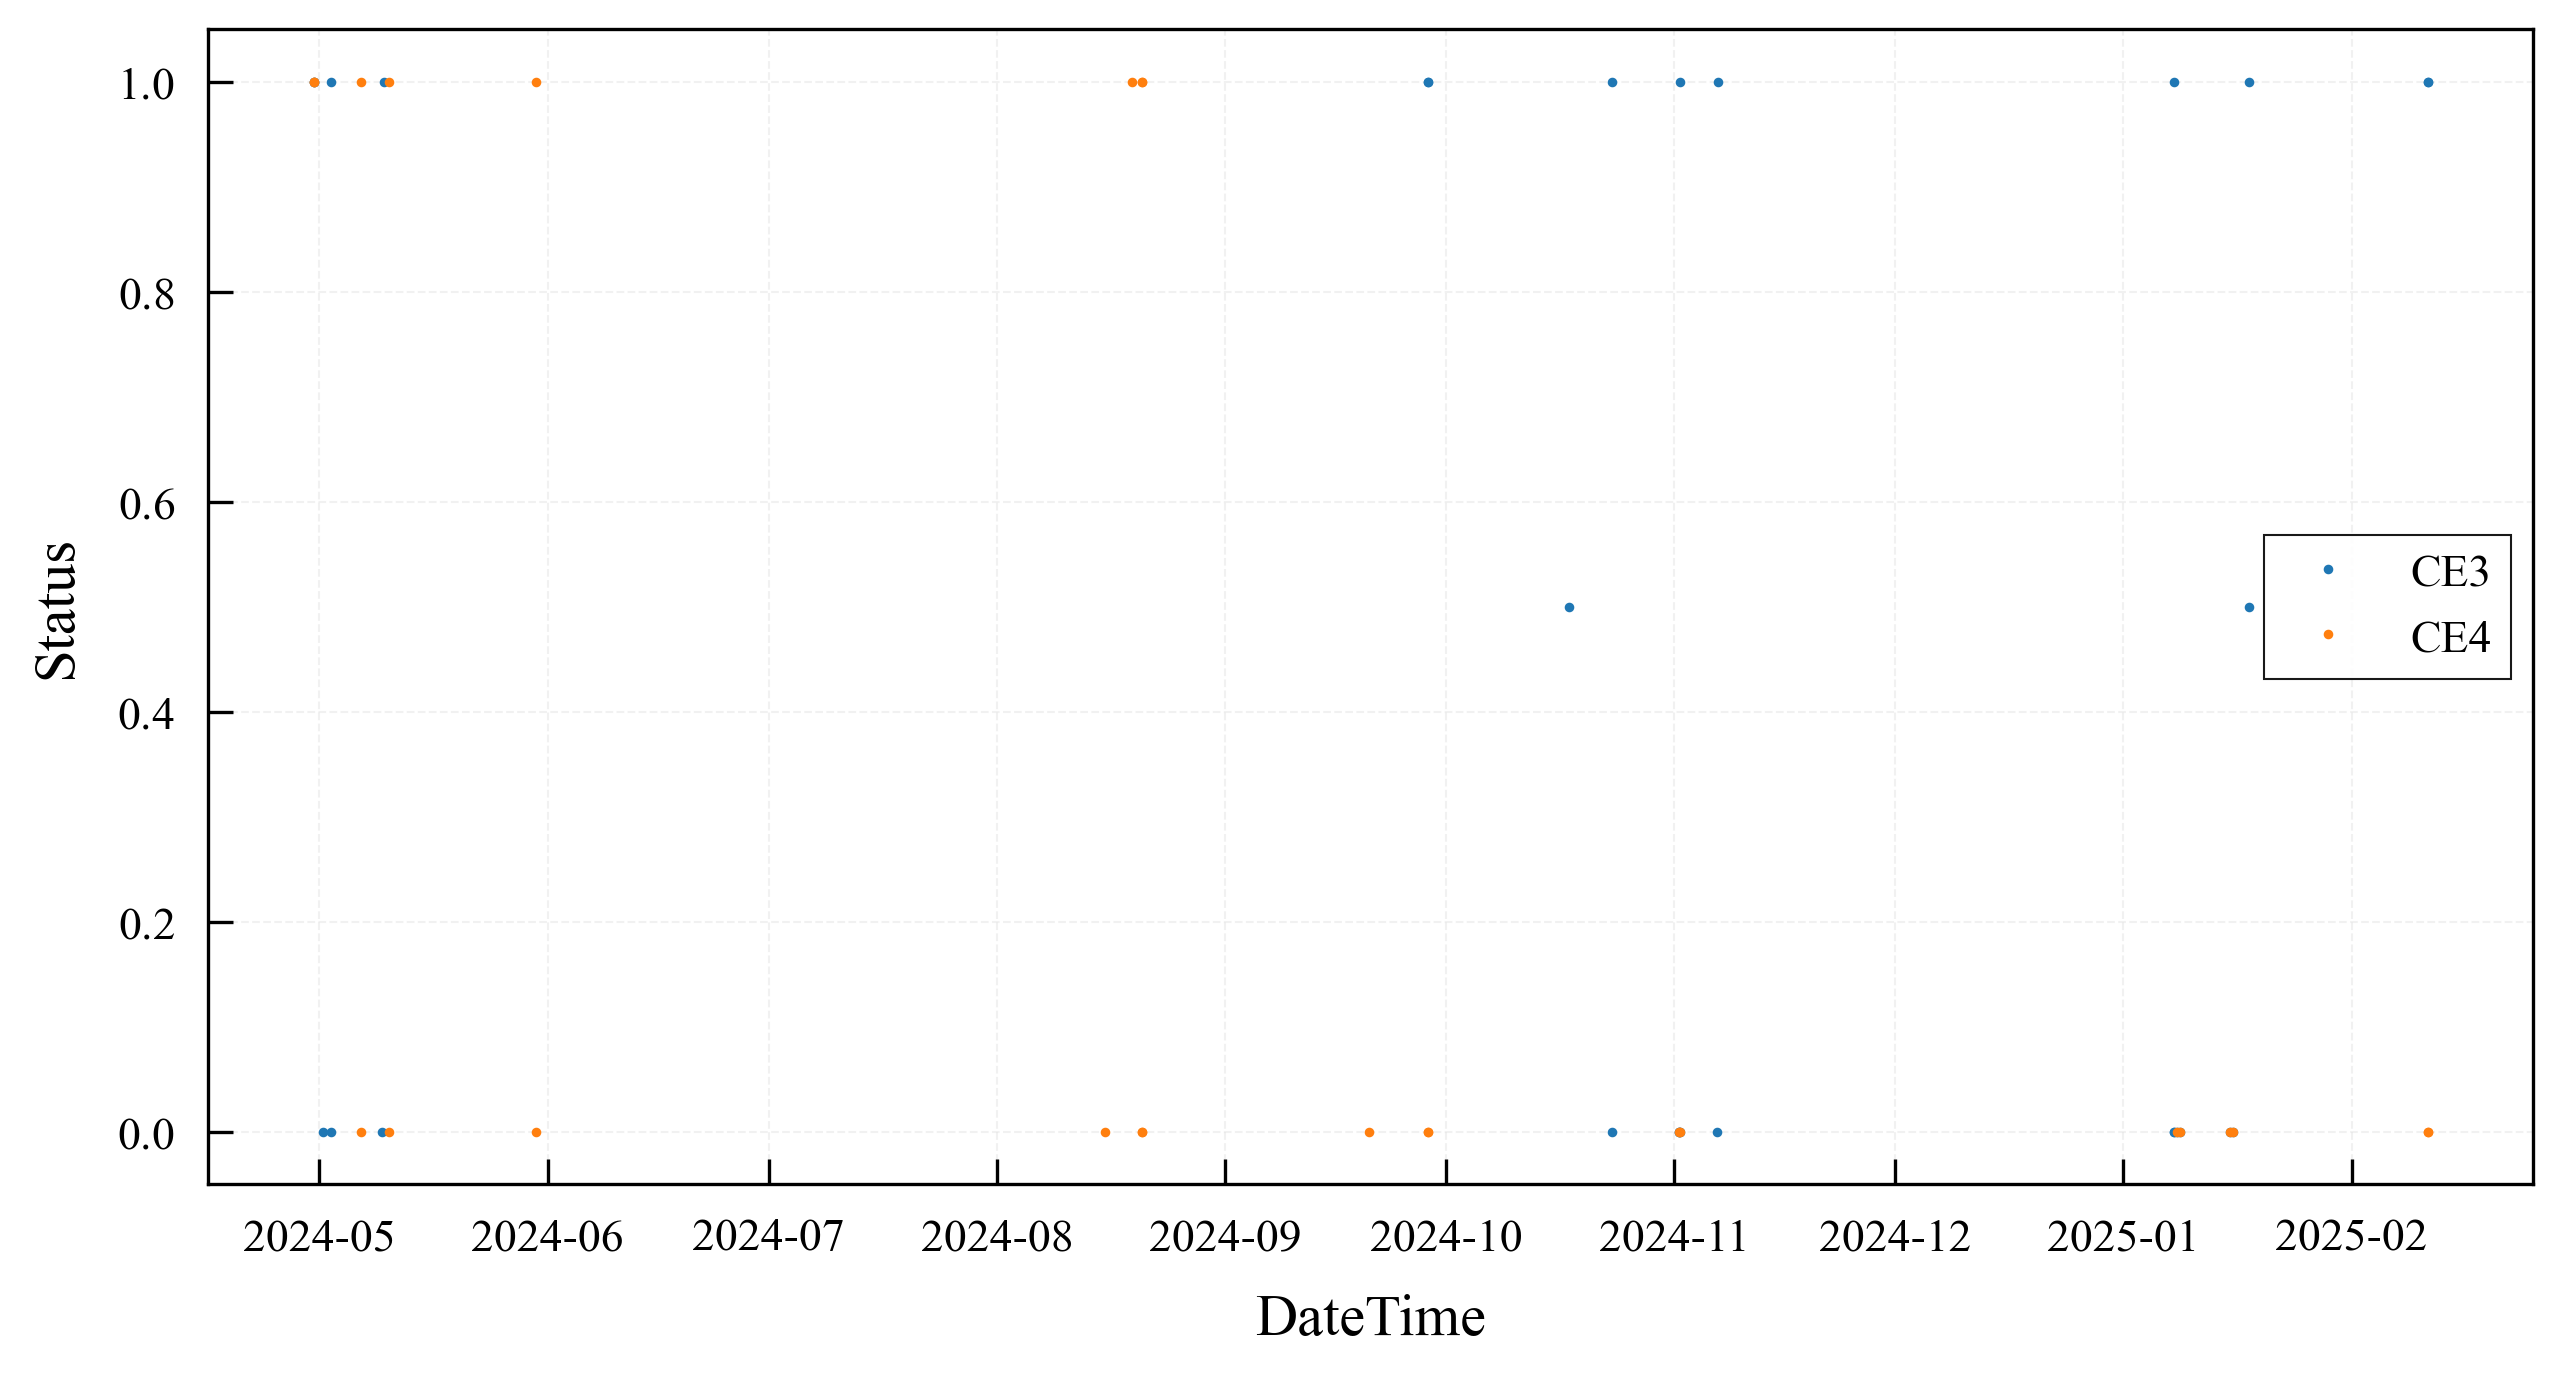

In [46]:
fig, axes = plt.subplots(1,1)
# axes.plot(ce1status.data.index.values, ce1status.data.values, marker="o", markersize=1.5, linestyle="None", label="CE1")
# axes.plot(ce2status.data.index.values, ce2status.data.values, marker="o", markersize=1.5, linestyle="None", label="CE2")
axes.plot(ce3status.data.index.values, ce3status.data.values, marker="o", markersize=1.5, linestyle="None", label="CE3")
axes.plot(ce4status.data.index.values, ce4status.data.values, marker="o", markersize=1.5, linestyle="None", label="CE4")
axes.set_xlabel("DateTime")
axes.set_ylabel("Status")
axes.legend()
fig.set_size_inches(10, 5)


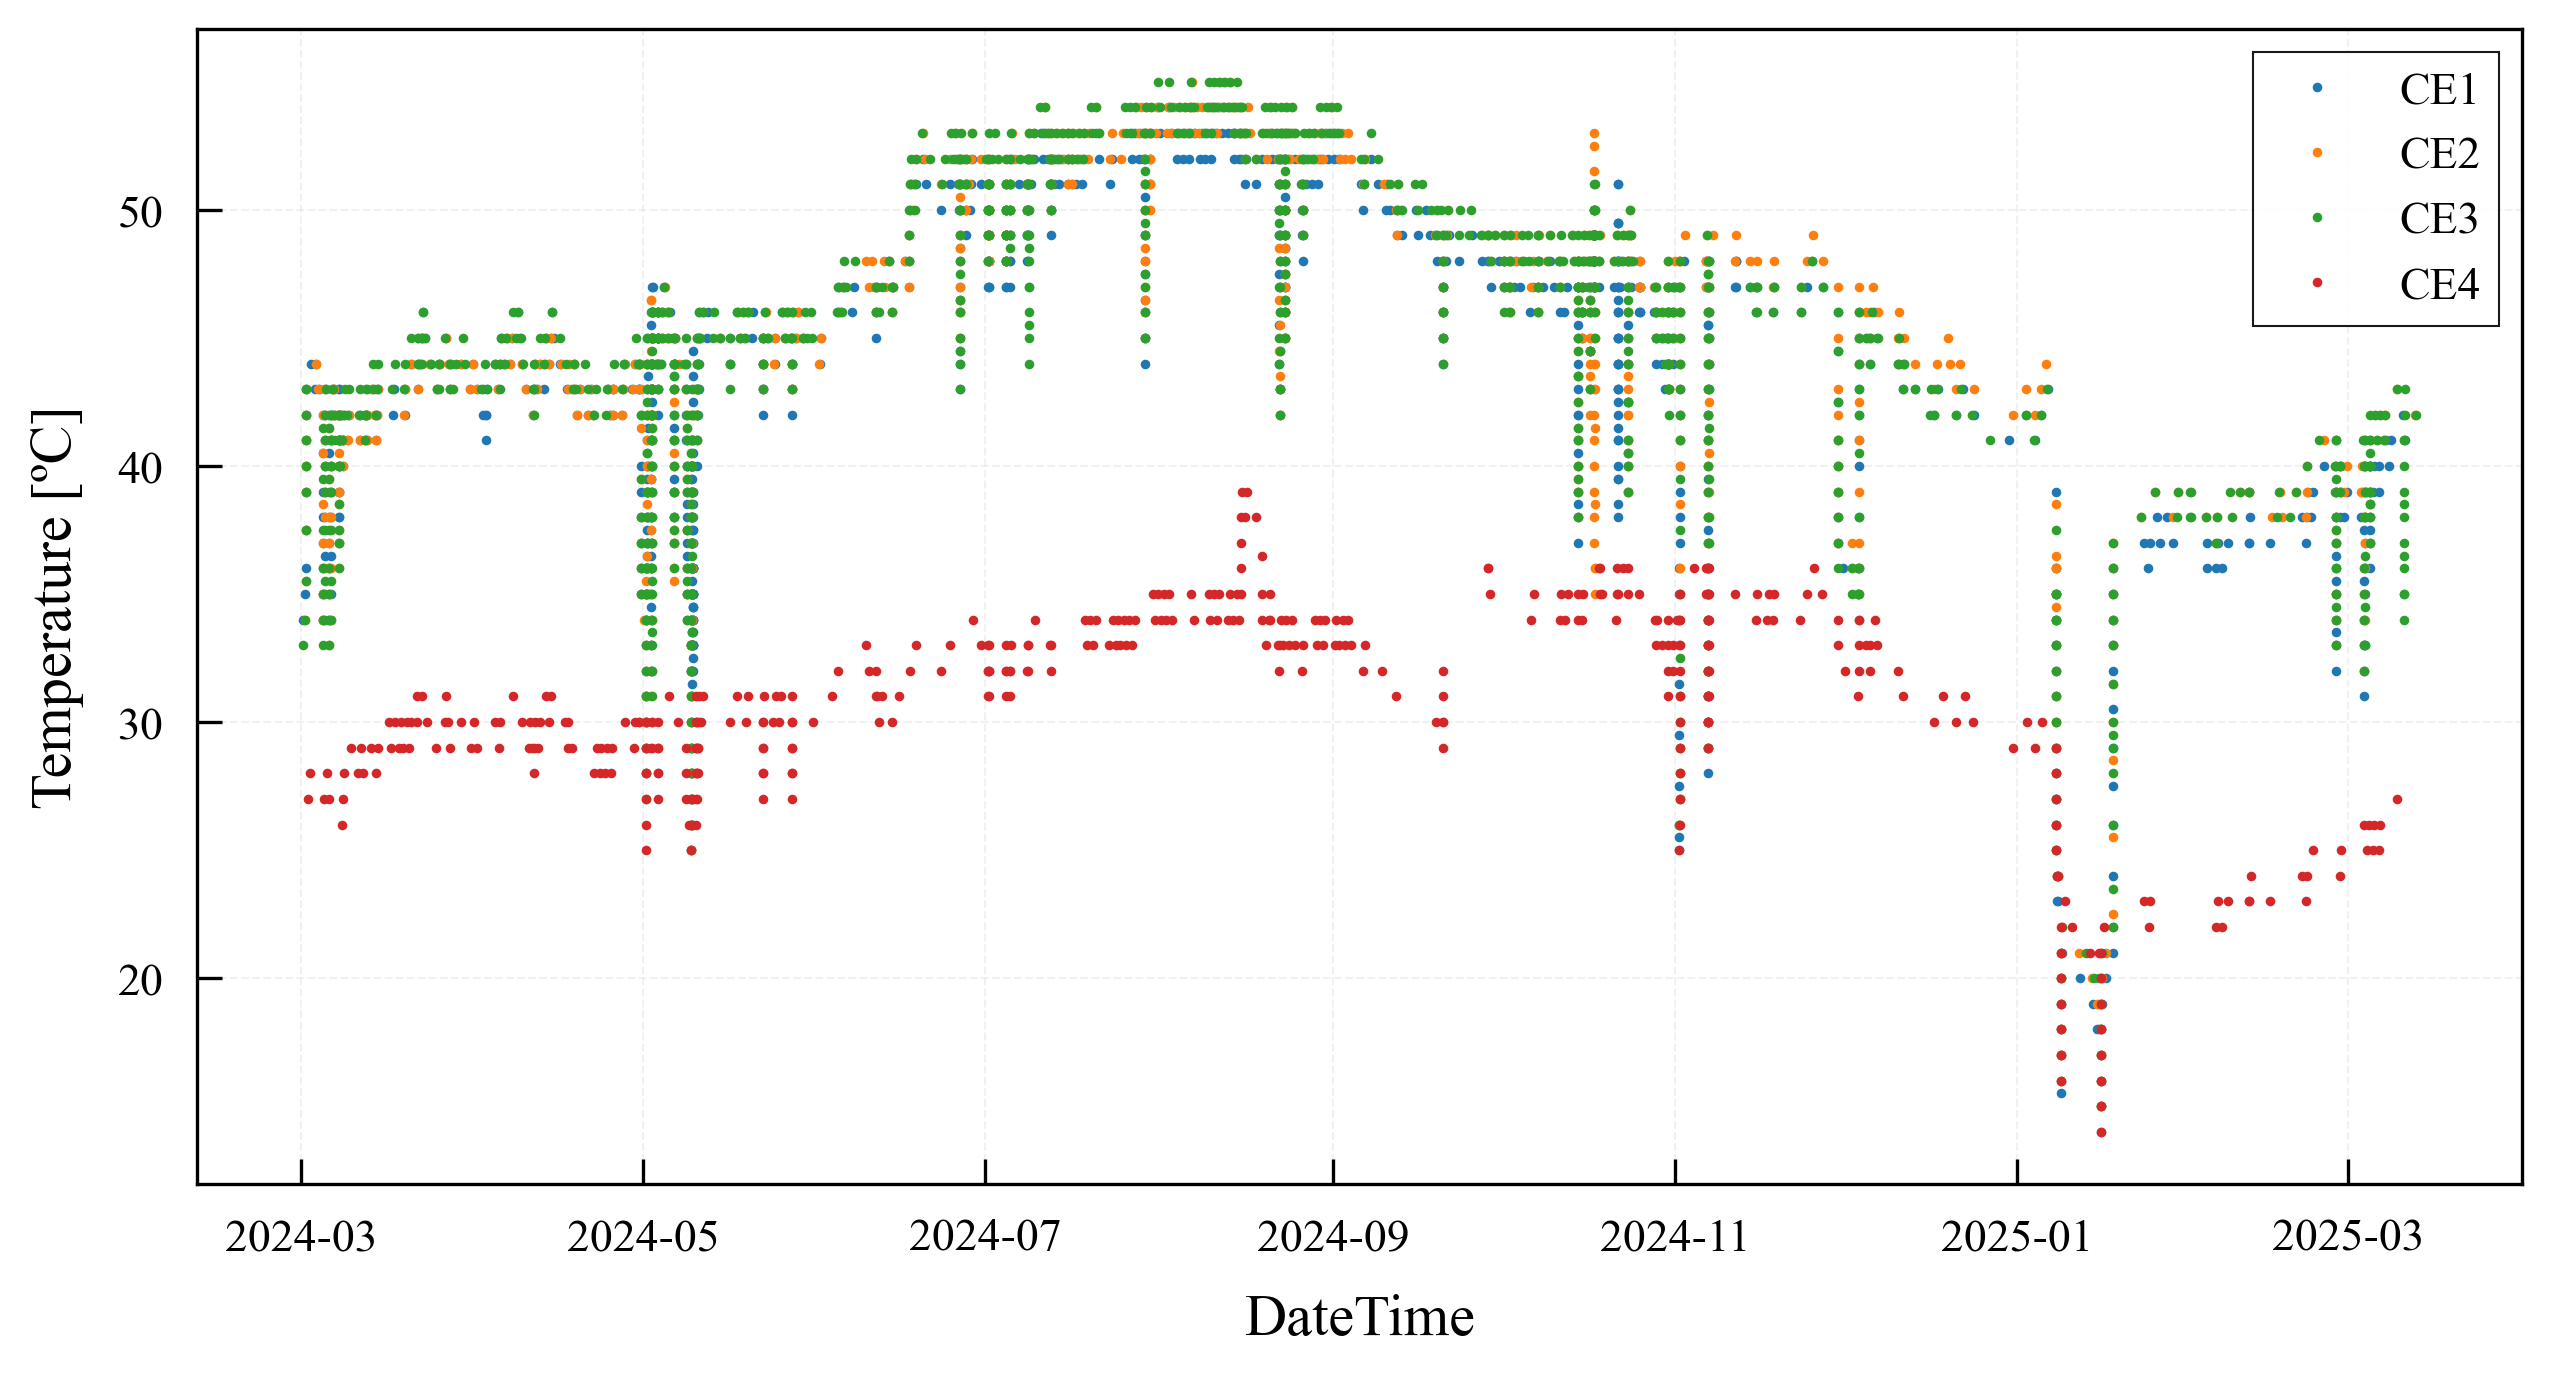

In [47]:
fig, axes = plt.subplots(1,1)
axes.plot(ce1t.data.index.values, ce1t.data.values, marker="o", markersize=1.5, linestyle="None", label="CE1")
axes.plot(ce2t.data.index.values, ce2t.data.values, marker="o", markersize=1.5, linestyle="None", label="CE2")
axes.plot(ce3t.data.index.values, ce3t.data.values, marker="o", markersize=1.5, linestyle="None", label="CE3")
axes.plot(ce4t.data.index.values, ce4t.data.values, marker="o", markersize=1.5, linestyle="None", label="CE4")
axes.set_xlabel("DateTime")
axes.set_ylabel("Temperature [ºC]")
axes.legend()
fig.set_size_inches(10, 5)

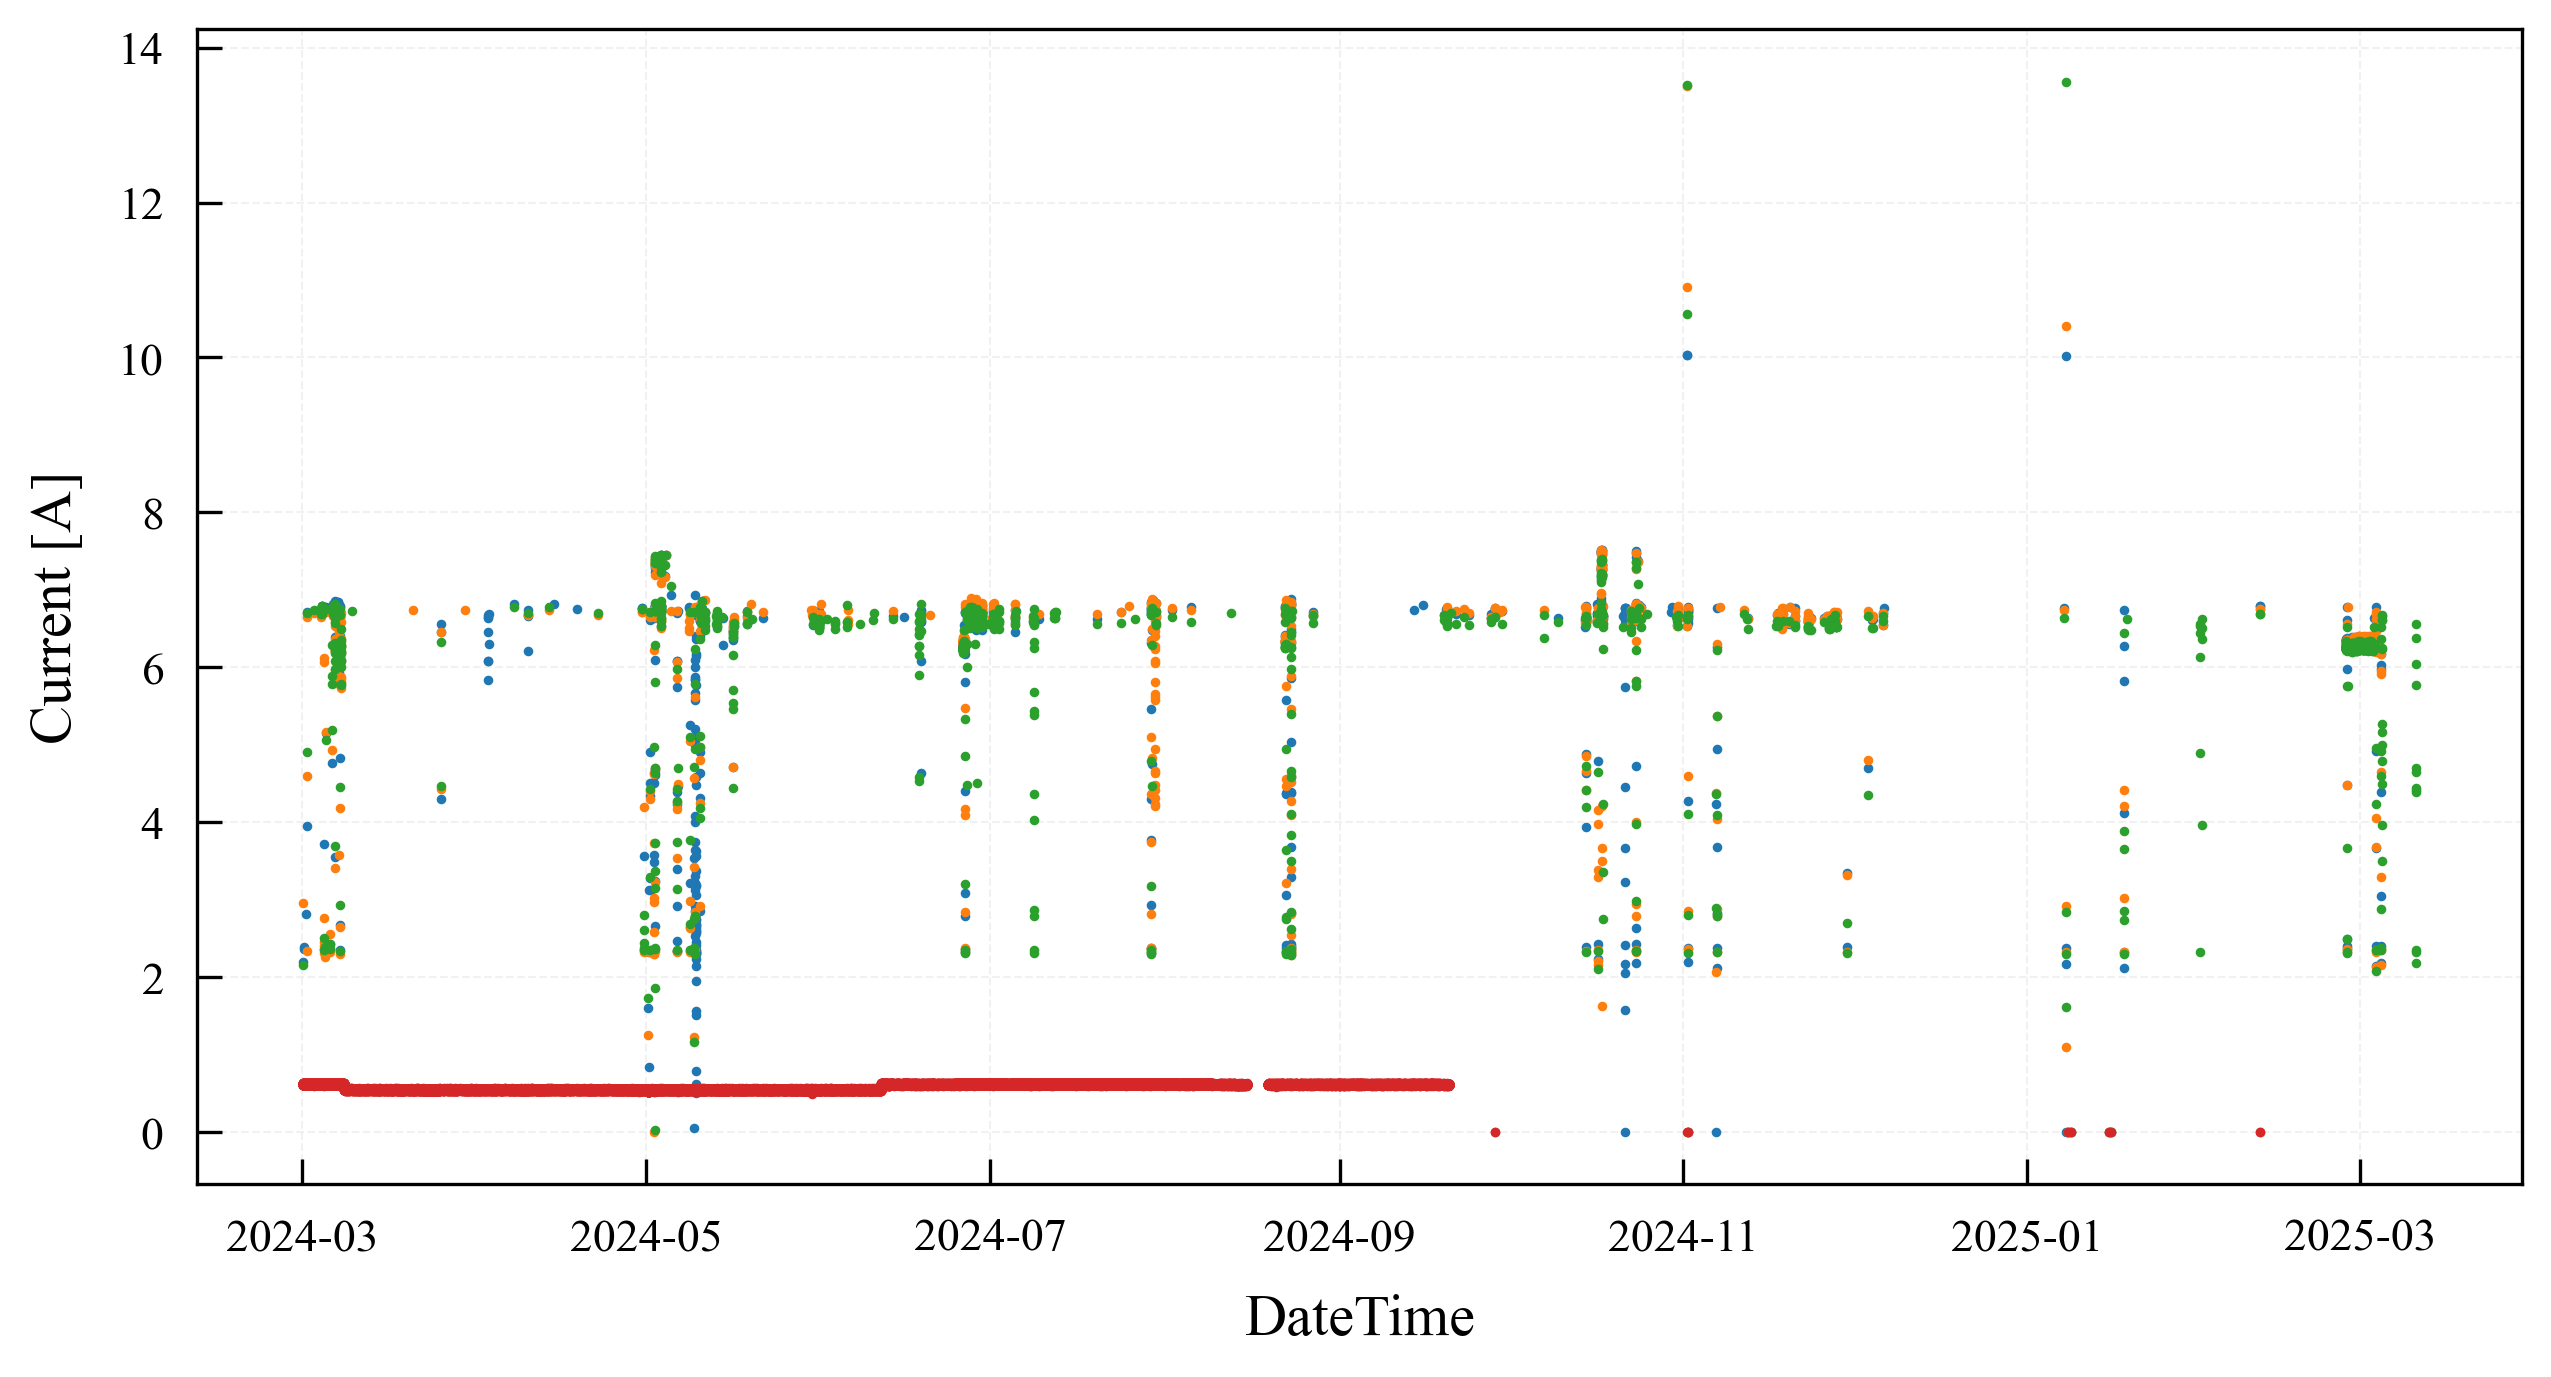

In [48]:
fig, axes = plt.subplots(1,1)
axes.plot(ce1i.data.index.values, ce1i.data.values, marker="o", markersize=1.5, linestyle="None", label="CE1")
axes.plot(ce2i.data.index.values, ce2i.data.values, marker="o", markersize=1.5, linestyle="None", label="CE2")
axes.plot(ce3i.data.index.values, ce3i.data.values, marker="o", markersize=1.5, linestyle="None", label="CE3")
axes.plot(ce4i.data.index.values, ce4i.data.values, marker="o", markersize=1.5, linestyle="None", label="CE4")
axes.set_xlabel("DateTime")
axes.set_ylabel("Current [A]")
fig.set_size_inches(10, 5)

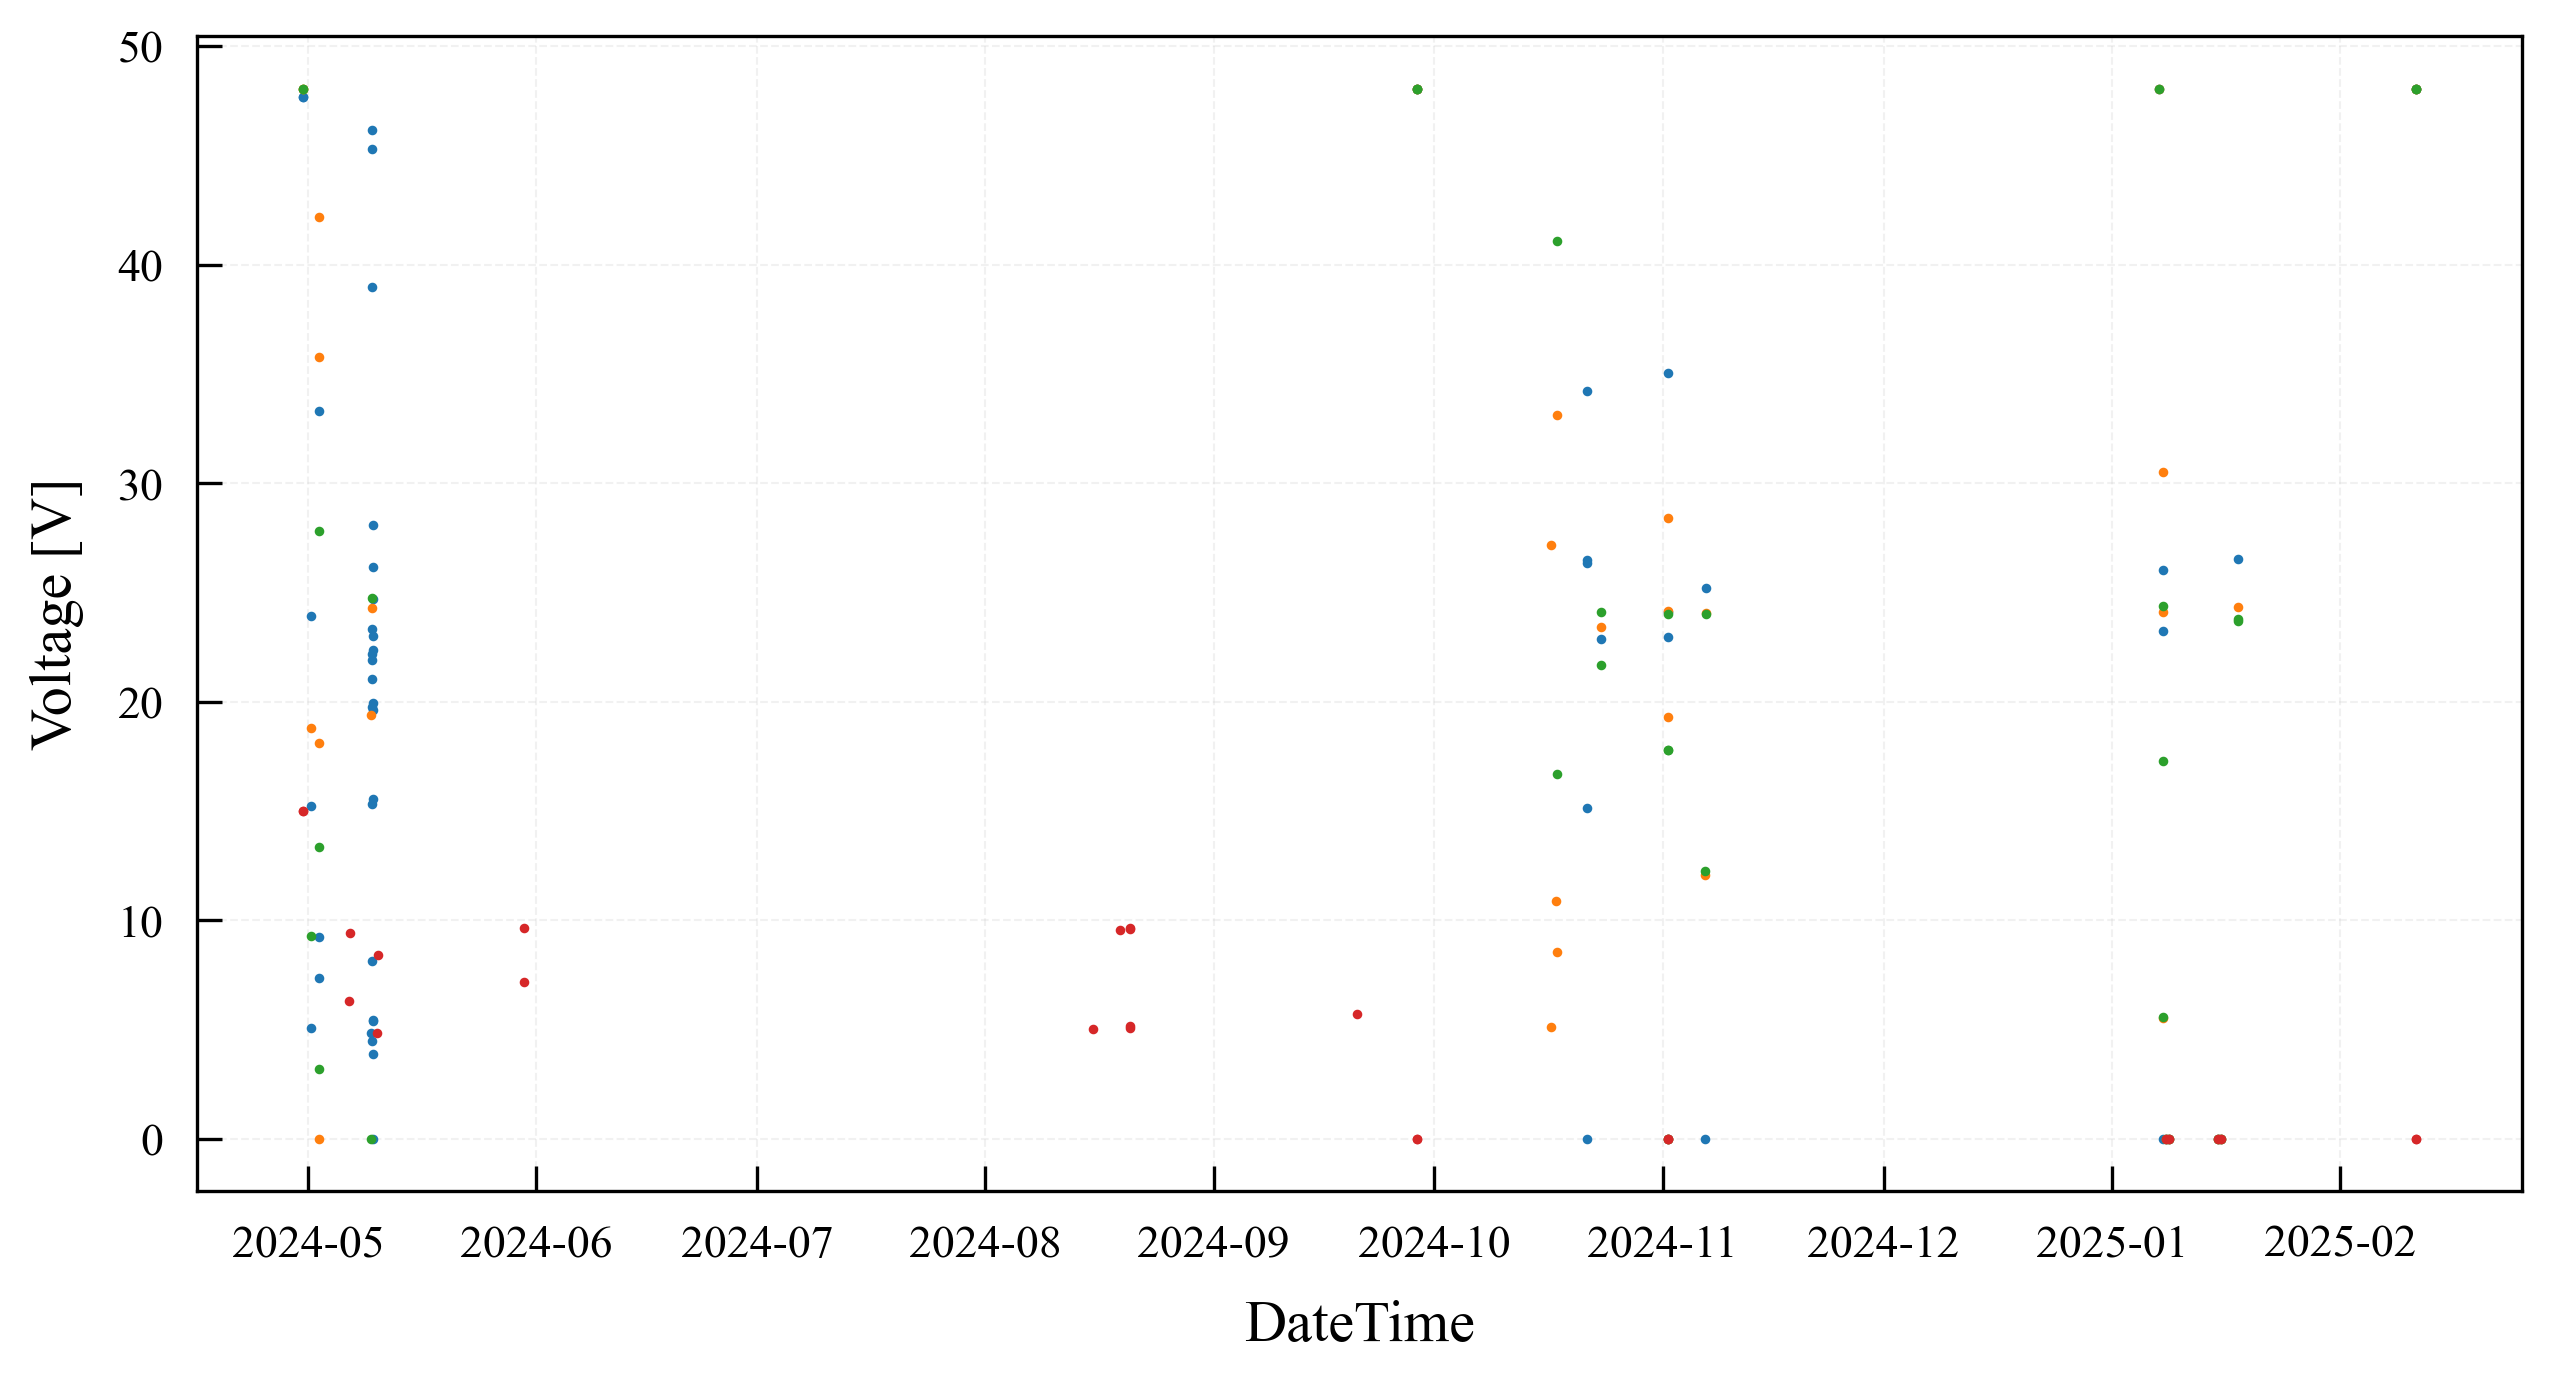

In [49]:
fig, axes = plt.subplots(1,1)
axes.plot(ce1v.data.index.values, ce1v.data.values, marker="o", markersize=1.5, linestyle="None", label="CE1")
axes.plot(ce2v.data.index.values, ce2v.data.values, marker="o", markersize=1.5, linestyle="None", label="CE2")
axes.plot(ce3v.data.index.values, ce3v.data.values, marker="o", markersize=1.5, linestyle="None", label="CE3")
axes.plot(ce4v.data.index.values, ce4v.data.values, marker="o", markersize=1.5, linestyle="None", label="CE4")
axes.set_xlabel("DateTime")
axes.set_ylabel("Voltage [V]")
fig.set_size_inches(10, 5)

From the available quantities on the slow controls of the CE, the one that can help better to nderstand the status of them is the temperature. It is assumed it is the temperature of the CE in warm, as it is correlated with the room temperature.

In [13]:
mask_first_poff = (
    ((dataset.data.index > datetime.datetime(2024, 4, 30)) & (dataset.data.index < datetime.datetime(2024, 5, 5)))
)

dataset.data = dataset.data.loc[mask_first_poff]
dataset.err = dataset.err.loc[mask_first_poff]

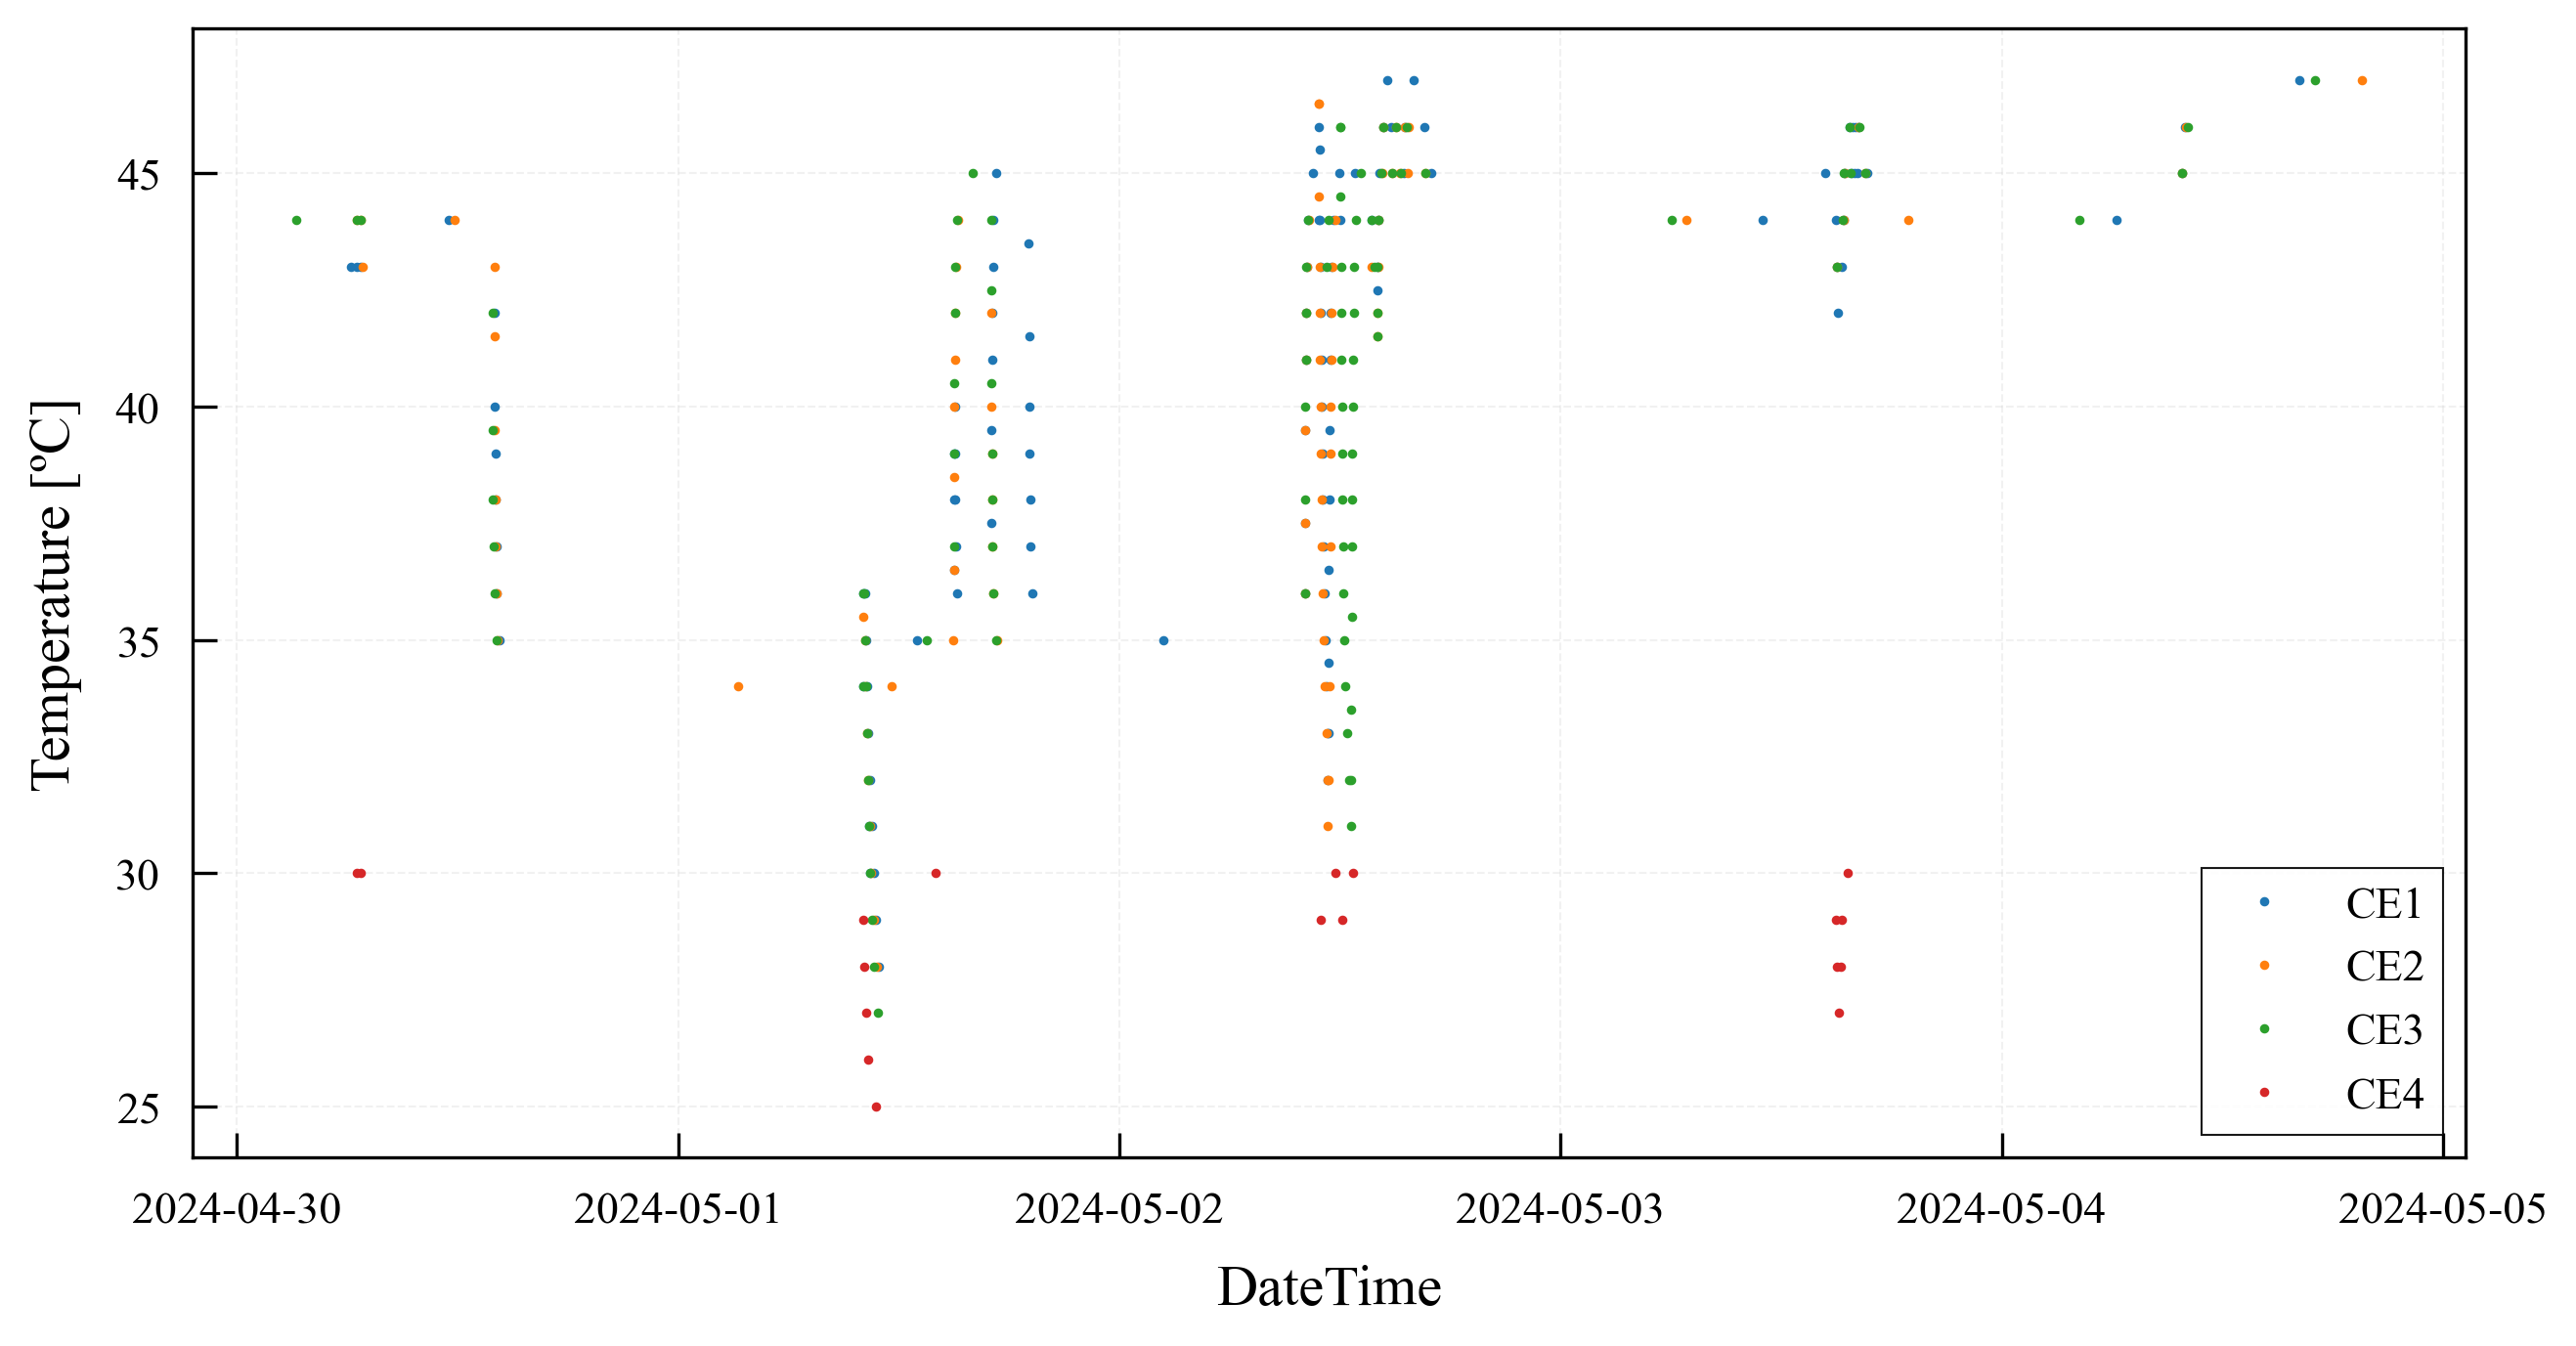

In [14]:
ce1t_first_poff = sensorClasses.Sensor(dataset, id=1017)

ce2t_first_poff = sensorClasses.Sensor(dataset, id=1022)

ce3t_first_poff = sensorClasses.Sensor(dataset, id=1027)

ce4t_first_poff = sensorClasses.Sensor(dataset, id=1032)

fig, axes = plt.subplots(1,1)
axes.plot(ce1t_first_poff.data.index.values, ce1t_first_poff.data.values, marker="o", markersize=1.5, linestyle="None", label="CE1")
axes.plot(ce2t_first_poff.data.index.values, ce2t_first_poff.data.values, marker="o", markersize=1.5, linestyle="None", label="CE2")
axes.plot(ce3t_first_poff.data.index.values, ce3t_first_poff.data.values, marker="o", markersize=1.5, linestyle="None", label="CE3")
axes.plot(ce4t_first_poff.data.index.values, ce4t_first_poff.data.values, marker="o", markersize=1.5, linestyle="None", label="CE4")
axes.set_xlabel("DateTime")
axes.set_ylabel("Temperature [ºC]")
axes.legend()
fig.set_size_inches(10, 5)

In [30]:
tgrad = systemClasses.System(dataset, "TGRAD")
hawai = systemClasses.System(dataset, "HAWAI")
prm = systemClasses.System(dataset, "PRM")
apa1 = systemClasses.System(dataset, sensor_names=["APA1LAr1", "APA1LAr4"])
apa2 = systemClasses.System(dataset, sensor_names=["APA2LAr1", "APA2LAr2", "APA2LAr3", "APA2LAr4"])
apa3 = systemClasses.System(dataset, sensor_names=["APA3LAr1", "APA3LAr2", "APA3LAr3", "APA3LAr4"])
apa4 = systemClasses.System(dataset, sensor_names=["APA4LAr1", "APA4LAr4"])
inlet = systemClasses.System(dataset, sensor_names=["1-I", "3-I", "4-I"])
upstream = systemClasses.System(dataset, sensor_names=["2-M", "4-M"])
middle = systemClasses.System(dataset, sensor_names=["1-M", "3-M"])
downstream = systemClasses.System(dataset, sensor_names=["1-U", "2-U", "3-U", "4-U"])
pipes = systemClasses.System(dataset, "PIPE")
pumps = systemClasses.System(dataset, "PP")
tgrad.calibrate("SECOND_POFF_OCTOBER")
hawai.calibrate("SECOND_POFF_EMPTY")
prm.calibrate("SECOND_POFF_OCTOBER")
pipes.calibrate("SECOND_POFF_OCTOBER")
pumps.calibrate("SECOND_POFF_OCTOBER")
inlet.calibrate("SECOND_POFF_OCTOBER")
upstream.calibrate("SECOND_POFF_OCTOBER")
middle.calibrate("SECOND_POFF_OCTOBER")
downstream.calibrate("SECOND_POFF_OCTOBER")
apa1.calibrate("SECOND_POFF_OCTOBER")
apa2.calibrate("SECOND_POFF_OCTOBER")
apa3.calibrate("SECOND_POFF_OCTOBER")
apa4.calibrate("SECOND_POFF_OCTOBER")


Initializing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Initializing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00,  3.77sensor/s]


ERROR: Channel (TE0120) not found


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:02<00:00,  4.12sensor/s]


ERROR: Channel (TE0120) not found


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:13<00:00,  3.58sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 48/48 [00:00<00:00, 51.23sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:06<00:00,  3.44sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 24/24 [00:00<00:00, 26.17sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:02<00:00,  2.25sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 14.41sensor/s]
Equalizing PIPE Sensors:  92%|█████████▏| 11/12 [00:04<00:00,  3.32sensor/s]

ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:04<00:00,  2.81sensor/s]
Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 79.14sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  3.93sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 98.75sensor/s]
Equalizing Custom Sensors: 100%|██████████| 3/3 [00:00<00:00,  3.71sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 3/3 [00:00<00:00, 100.71sensor/s]
Equalizing Custom Sensors:  50%|█████     | 1/2 [00:00<00:00,  3.62sensor/s]

ERROR: Channel (TE0120) not found


Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00,  3.79sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 52.12sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00,  3.84sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 84.45sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:01<00:00,  3.83sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 4/4 [00:00<00:00, 93.48sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00,  4.24sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 105.39sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00,  7.55sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 4/4 [00:00<00:00, 73.65sensor/s]
Equalizing Custom Sensor

In [31]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
hawai.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
prm.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
pipes.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
pumps.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
inlet.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
upstream.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
middle.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
downstream.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
apa1.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
apa2.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
apa3.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))
apa4.makeProfiles(tini=datetime.datetime(2024, 5, 1, 7, 20), tend=datetime.datetime(2024, 5, 1, 8, 20))

pre_hawai = hawai.profiles
pre_tgrad = tgrad.profiles
apa1_pre = apa1.profiles
apa2_pre = apa2.profiles
apa3_pre = apa3.profiles
apa4_pre = apa4.profiles


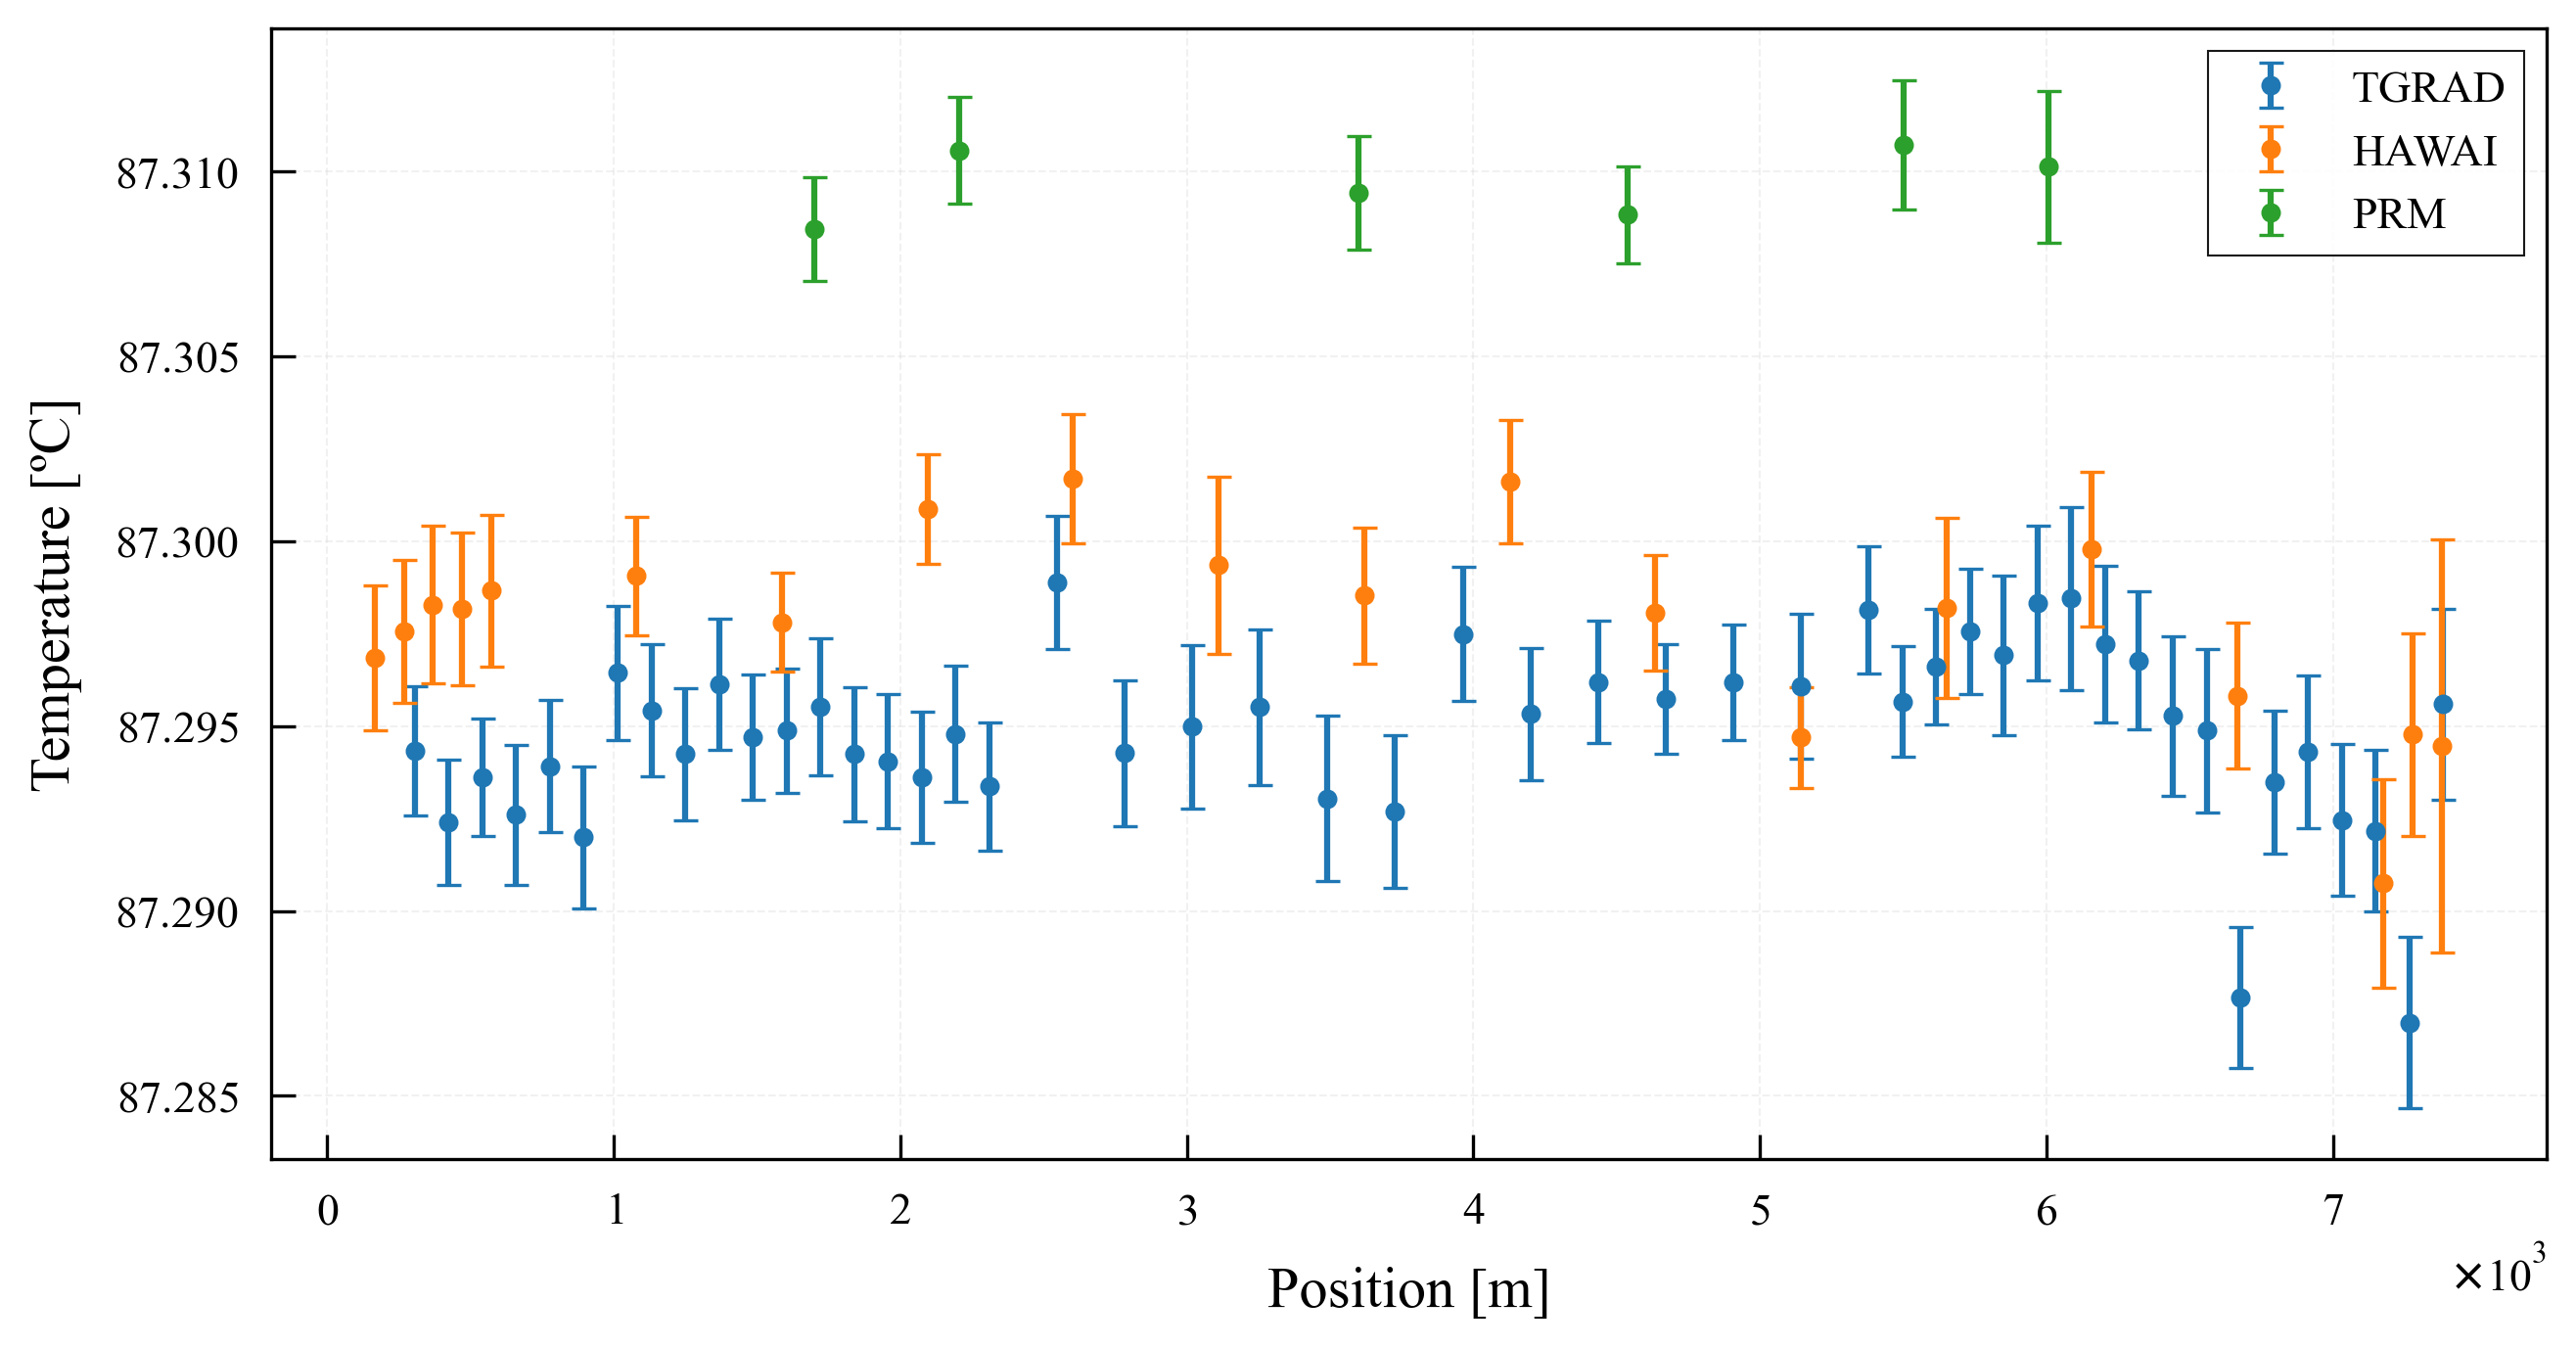

In [54]:
fig, axes = plt.subplots(1,1)
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, marker="o", linestyle="None", label="TGRAD")
axes.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, marker="o", linestyle="None", label="HAWAI")
axes.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, marker="o", linestyle="None", label="PRM")
axes.set_xlabel("Position [m]")
axes.set_ylabel("Temperature [ºC]")
axes.legend()
fig.set_size_inches(10, 5)


In [32]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
hawai.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
prm.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
pipes.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
pumps.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
inlet.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
upstream.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
middle.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
downstream.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
apa1.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
apa2.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
apa3.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))
apa4.makeProfiles(tini=datetime.datetime(2024, 5, 1, 16, 3), tend=datetime.datetime(2024, 5, 1, 17, 3))

during_hawai = hawai.profiles
during_tgrad = tgrad.profiles
apa1_during = apa1.profiles
apa2_during = apa2.profiles
apa3_during = apa3.profiles
apa4_during = apa4.profiles


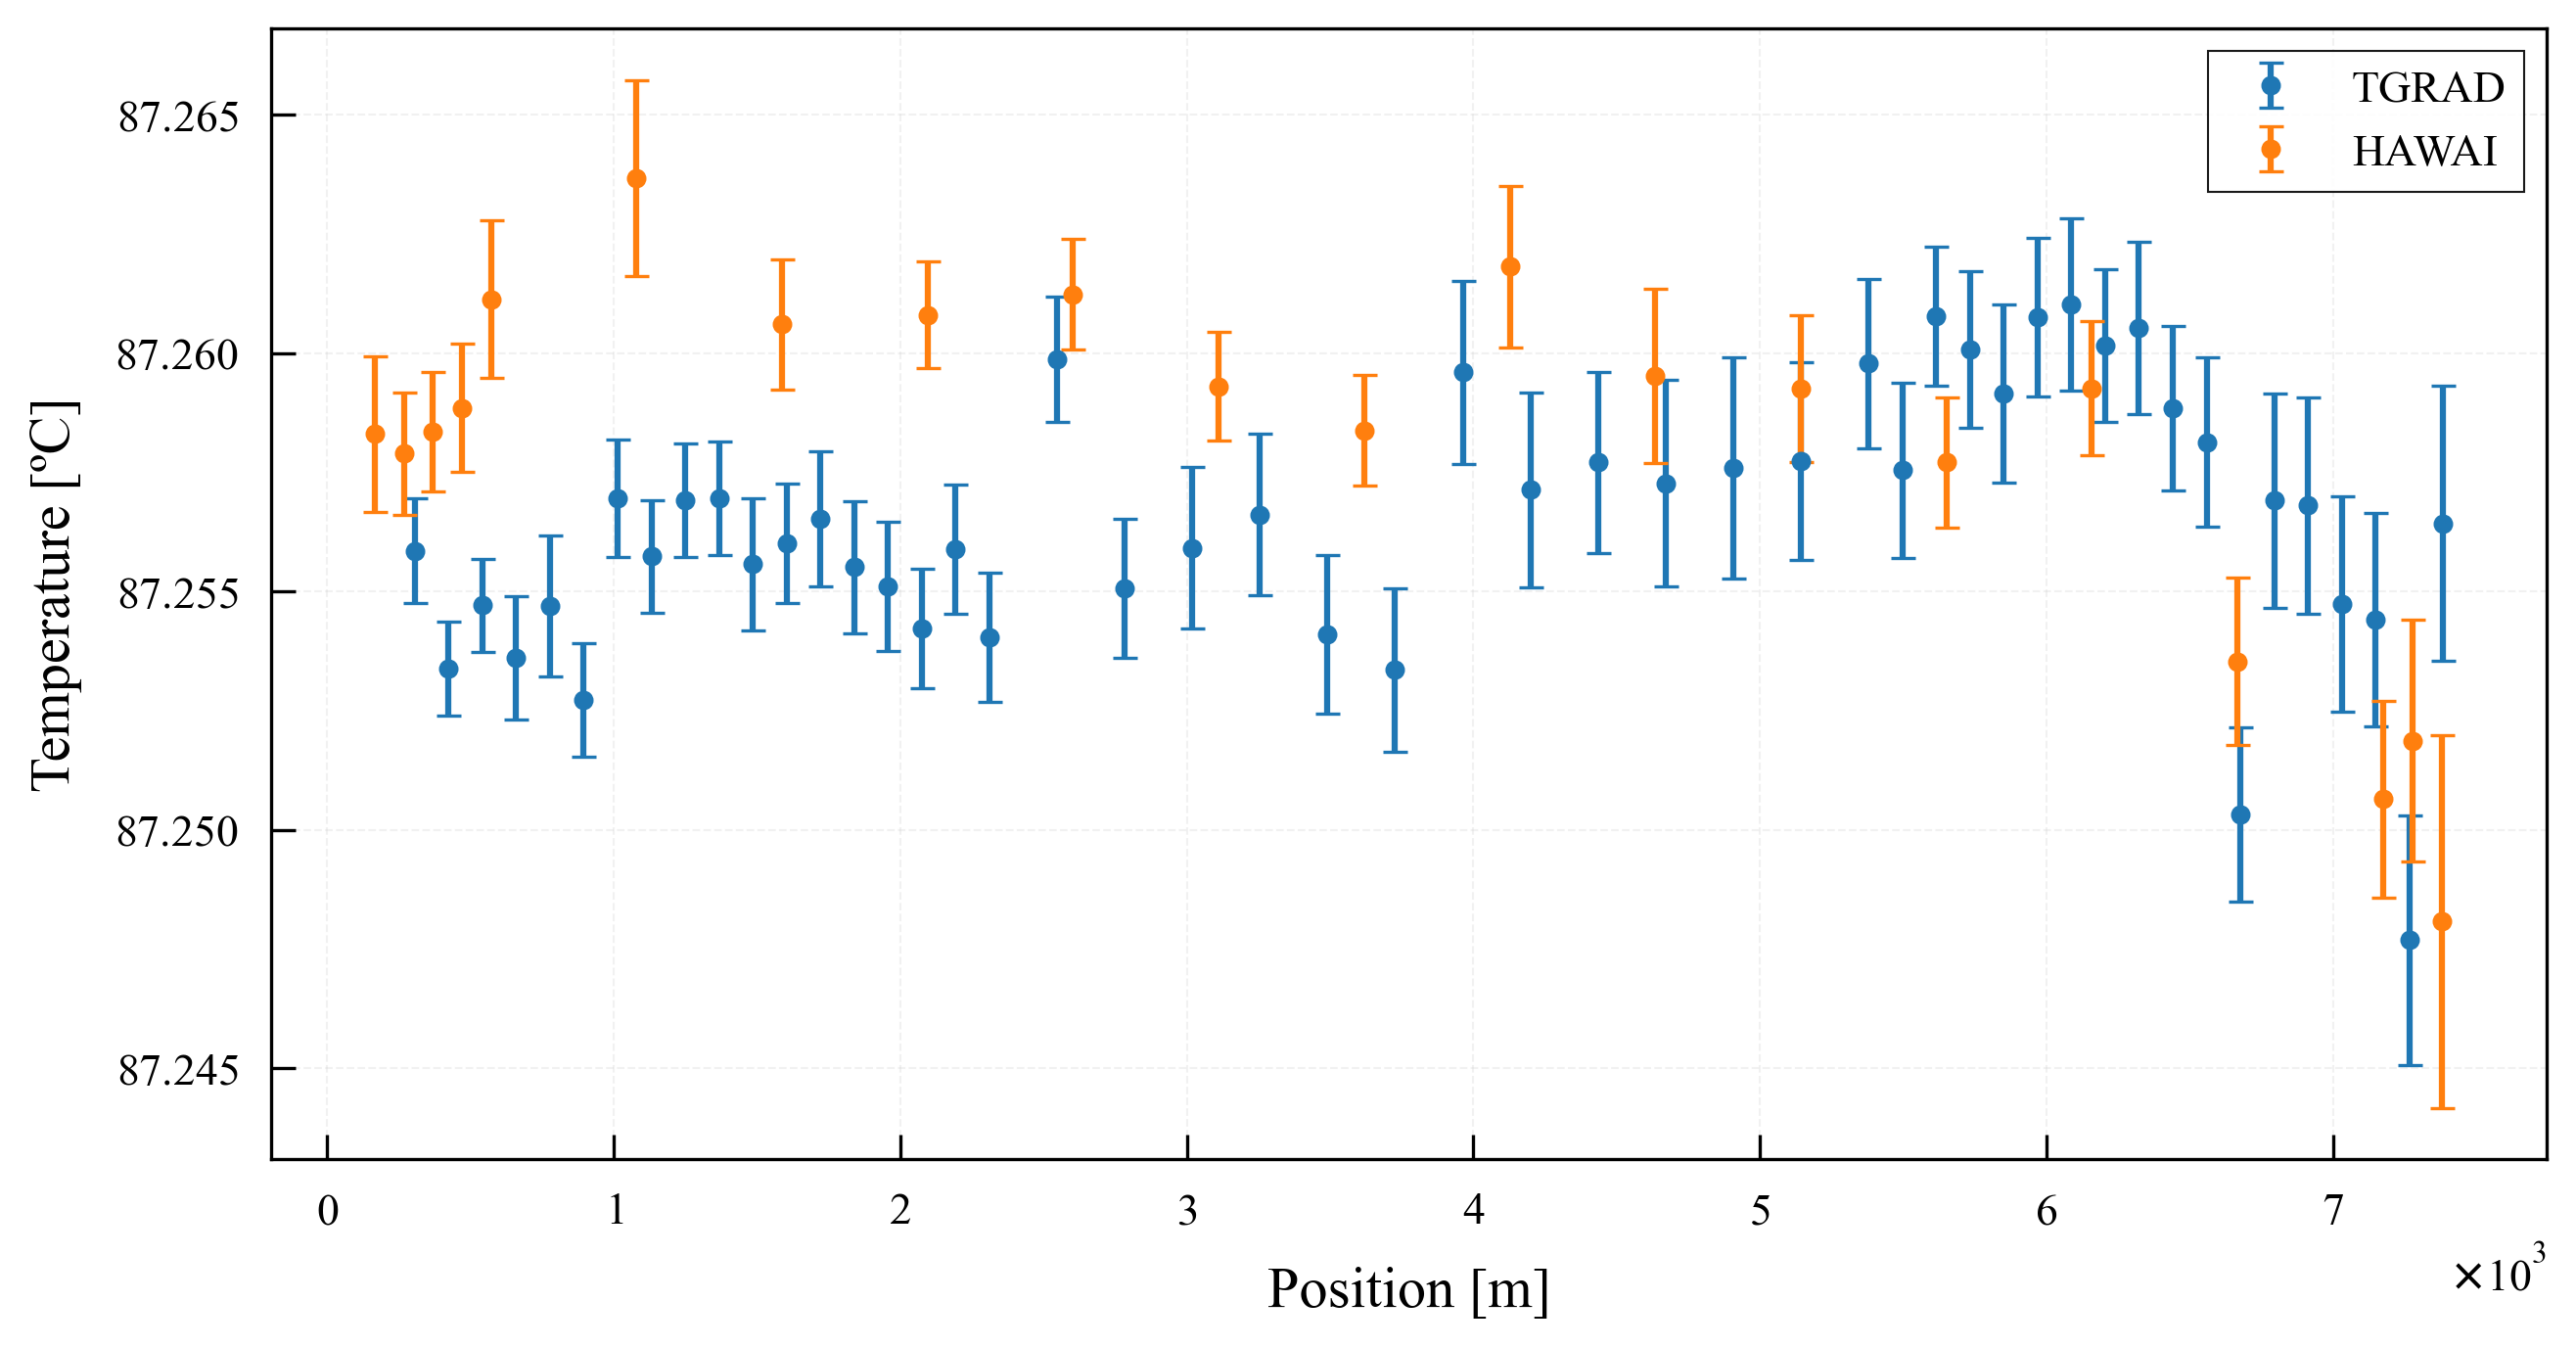

In [56]:
fig, axes = plt.subplots(1,1)
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, marker="o", linestyle="None", label="TGRAD")
axes.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, marker="o", linestyle="None", label="HAWAI")
# axes.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, marker="o", linestyle="None", label="PRM")
axes.set_xlabel("Position [m]")
axes.set_ylabel("Temperature [ºC]")
axes.legend()
fig.set_size_inches(10, 5)

In [33]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
hawai.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
prm.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
pipes.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
pumps.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
inlet.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
upstream.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
middle.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
downstream.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
apa1.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
apa2.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
apa3.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))
apa4.makeProfiles(tini=datetime.datetime(2024, 5, 1, 17, 3), tend=datetime.datetime(2024, 5, 1, 19, 3))

post_hawai = hawai.profiles
post_tgrad = tgrad.profiles
apa1_post = apa1.profiles
apa2_post = apa2.profiles
apa3_post = apa3.profiles
apa4_post = apa4.profiles


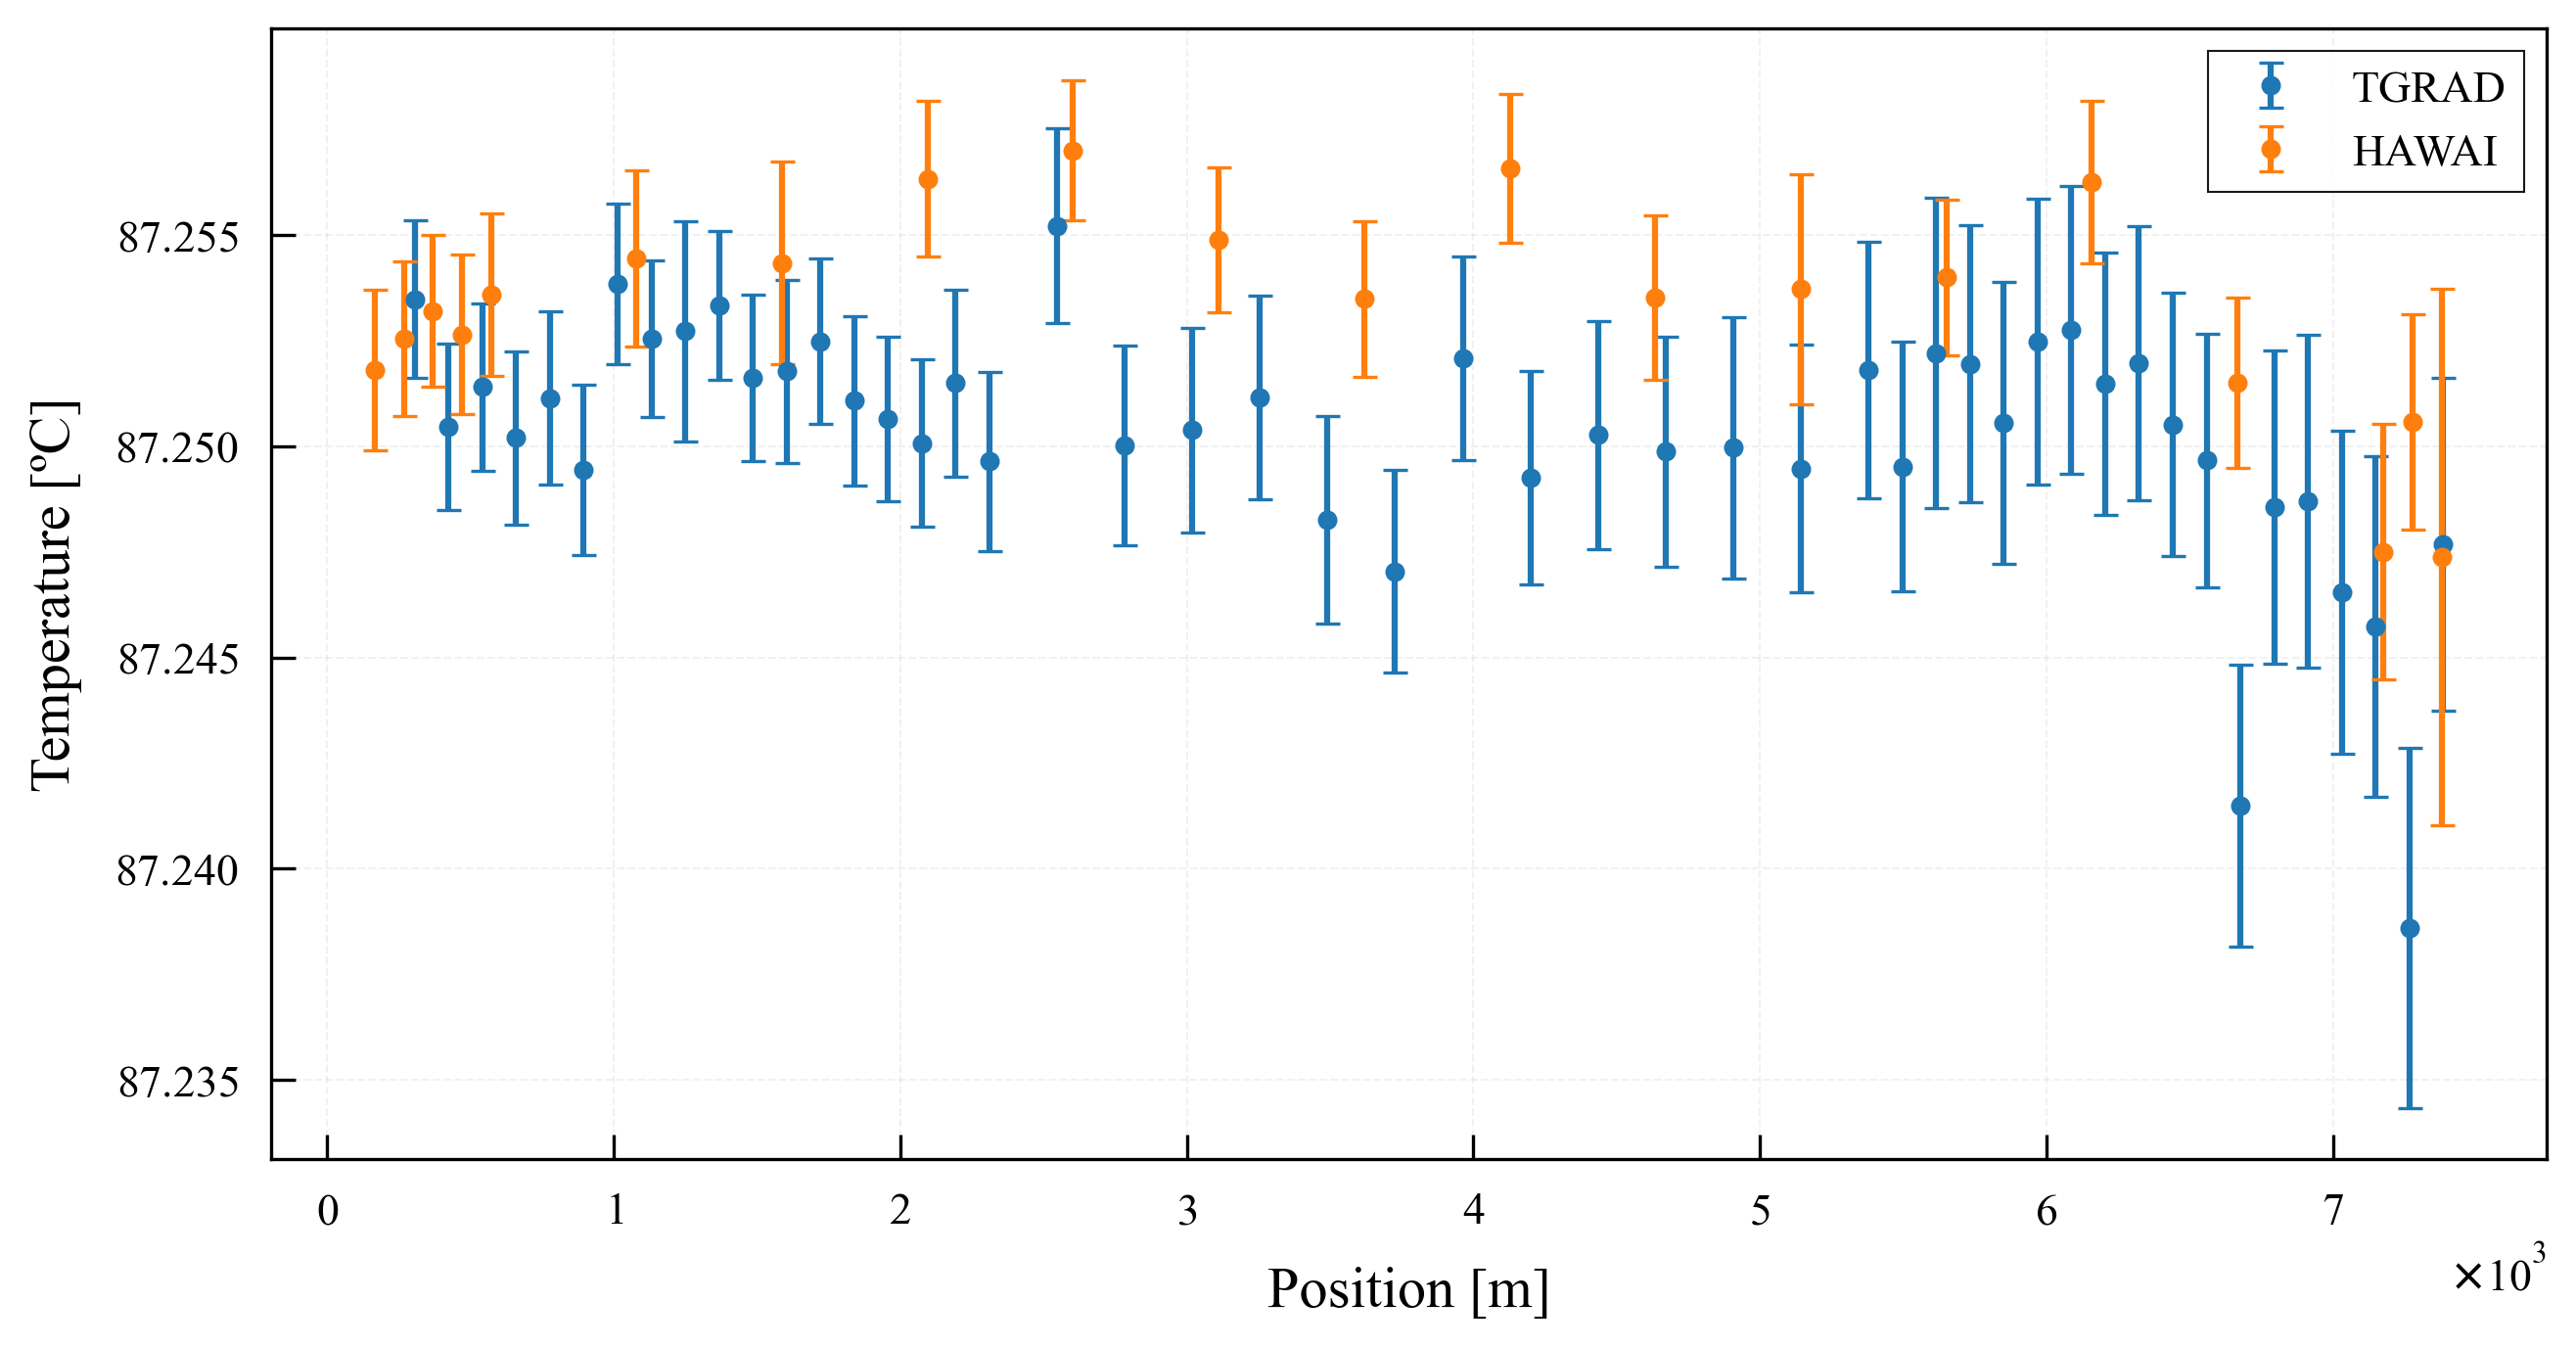

In [58]:
fig, axes = plt.subplots(1,1)
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, marker="o", linestyle="None", label="TGRAD")
axes.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, marker="o", linestyle="None", label="HAWAI")
# axes.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, marker="o", linestyle="None", label="PRM")
axes.set_xlabel("Position [m]")
axes.set_ylabel("Temperature [ºC]")
axes.legend()
fig.set_size_inches(10, 5)

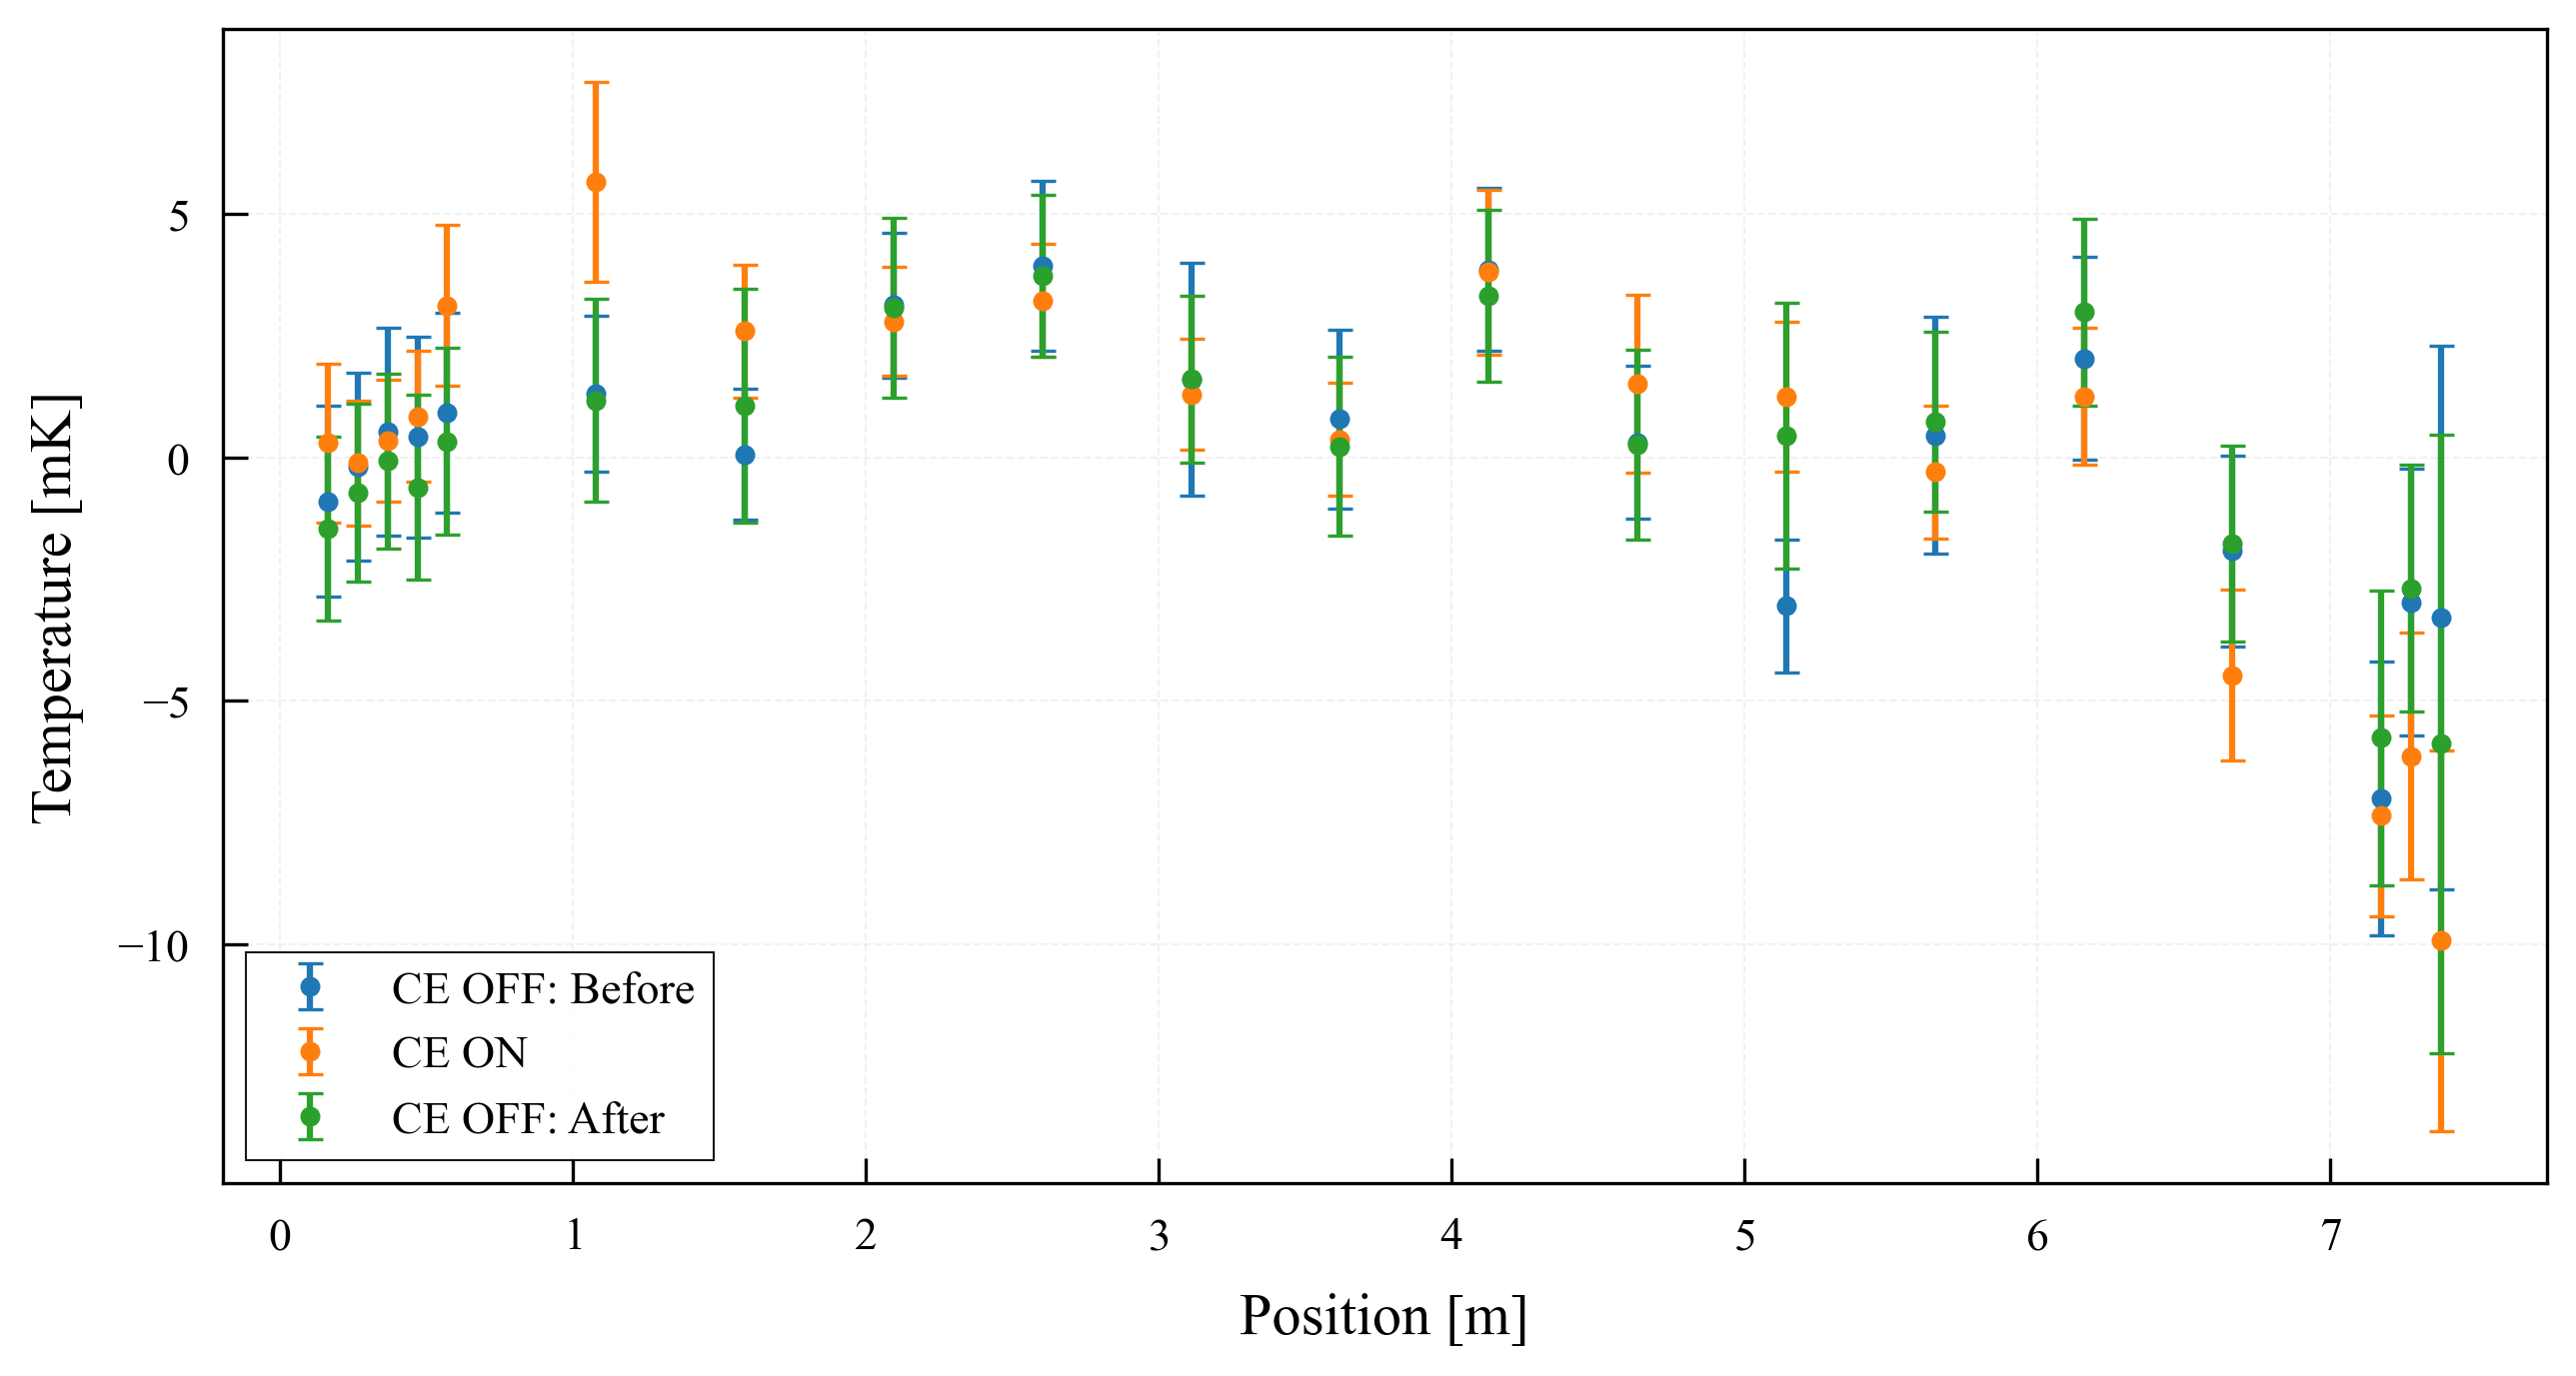

In [59]:
fig, axes = plt.subplots(1,1)
axes.errorbar(1e-3*pre_hawai["Y"].values, 1e3*pre_hawai["temp"].values - 1e3*pre_hawai["temp"].mean(), yerr=1e3*pre_hawai["err"].values, marker="o", linestyle="None", label="CE OFF: Before")
axes.errorbar(1e-3*during_hawai["Y"].values, 1e3*during_hawai["temp"].values - 1e3*during_hawai["temp"].mean(), yerr=1e3*during_hawai["err"].values, marker="o", linestyle="None", label="CE ON")
axes.errorbar(1e-3*post_hawai["Y"].values, 1e3*post_hawai["temp"].values - 1e3*post_hawai["temp"].mean(), yerr=1e3*post_hawai["err"].values, marker="o", linestyle="None", label="CE OFF: After")
axes.set_xlabel("Position [m]")
axes.set_ylabel("Temperature [mK]")
axes.legend()
fig.set_size_inches(10, 5)


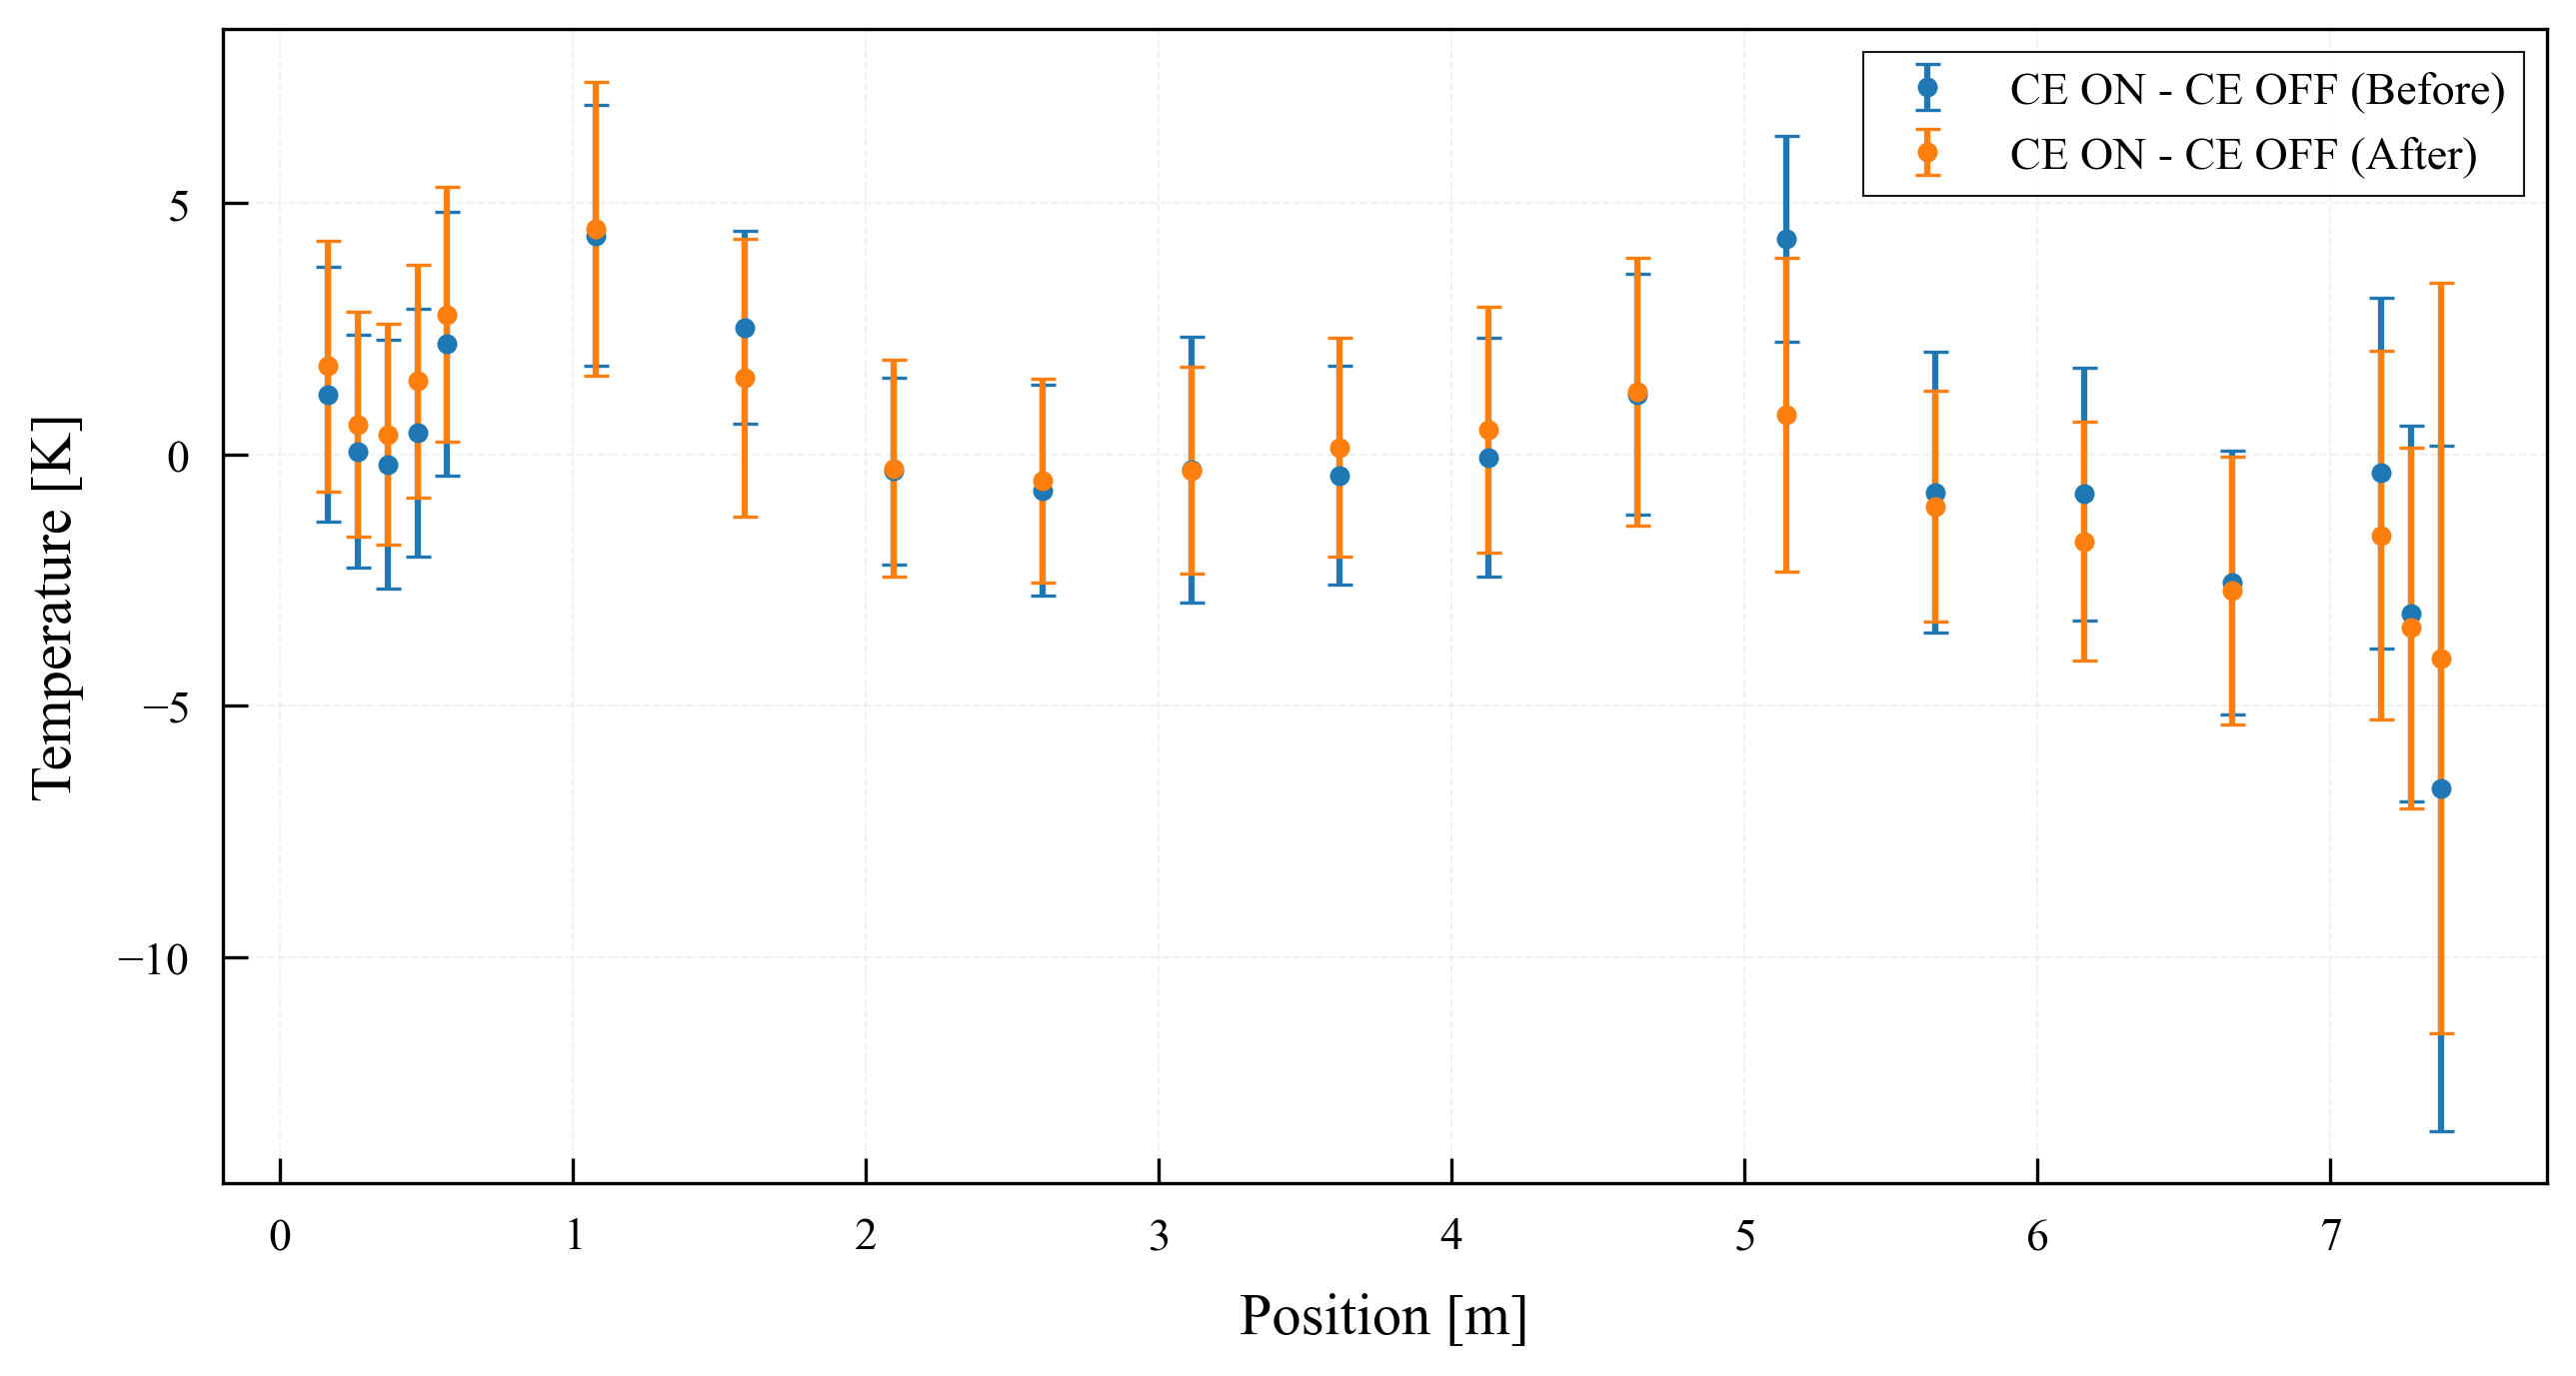

In [60]:
fig, axes = plt.subplots(1,1)
axes.errorbar(1e-3*pre_hawai["Y"].values, 1e3*(during_hawai["temp"].values - pre_hawai["temp"].values - (during_hawai["temp"] - pre_hawai["temp"]).mean()), yerr=1e3*np.sqrt(pre_hawai["err"].values**2 + during_hawai["err"].values**2), marker="o", linestyle="None", label="CE ON - CE OFF (Before)")
axes.errorbar(1e-3*during_hawai["Y"].values, 1e3*(during_hawai["temp"].values - post_hawai["temp"].values - (during_hawai["temp"] - post_hawai["temp"]).mean()), yerr=1e3*np.sqrt(during_hawai["err"].values**2 + post_hawai["err"].values**2), marker="o", linestyle="None", label="CE ON - CE OFF (After)")
axes.set_xlabel("Position [m]")
axes.set_ylabel("Temperature [K]")
axes.legend()
fig.set_size_inches(10, 5)



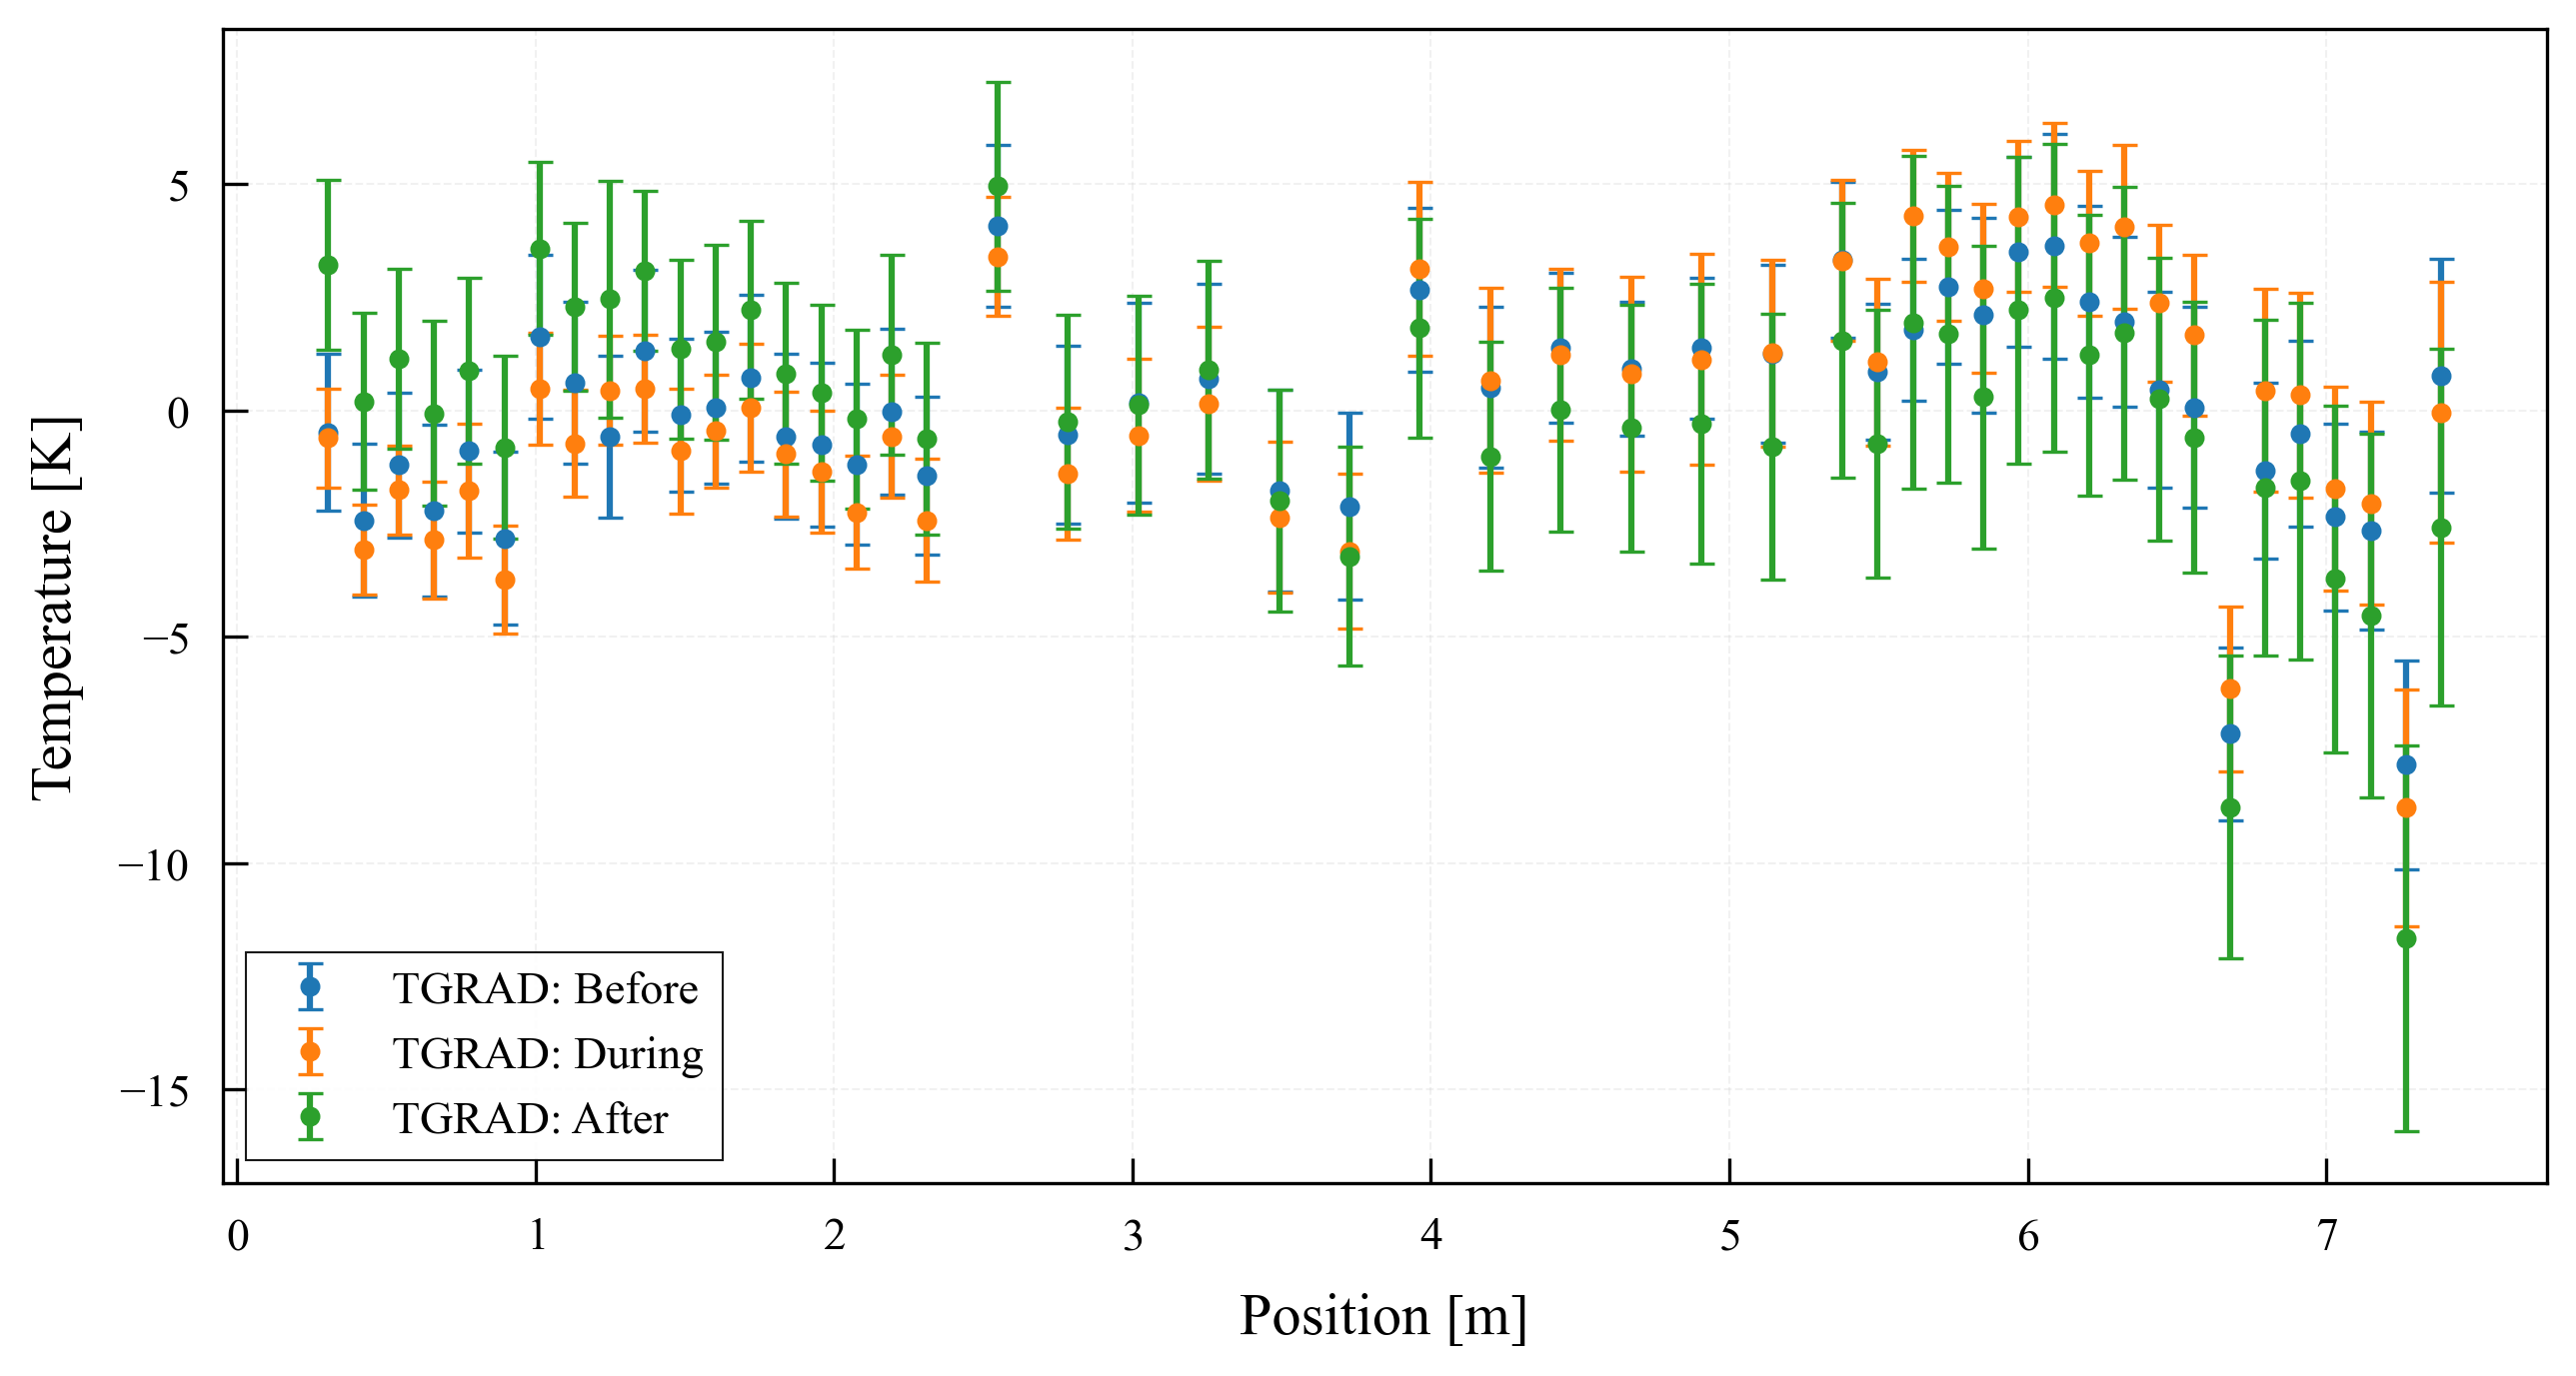

In [61]:
fig, axes = plt.subplots(1,1)
axes.errorbar(1e-3*pre_tgrad["Y"].values, 1e3*pre_tgrad["temp"].values - 1e3*pre_tgrad["temp"].mean(), yerr=1e3*pre_tgrad["err"].values, marker="o", linestyle="None", label="TGRAD: Before")
axes.errorbar(1e-3*during_tgrad["Y"].values, 1e3*during_tgrad["temp"].values - 1e3*during_tgrad["temp"].mean(), yerr=1e3*during_tgrad["err"].values, marker="o", linestyle="None", label="TGRAD: During")
axes.errorbar(1e-3*post_tgrad["Y"].values, 1e3*post_tgrad["temp"].values - 1e3*post_tgrad["temp"].mean(), yerr=1e3*post_tgrad["err"].values, marker="o", linestyle="None", label="TGRAD: After")
axes.set_xlabel("Position [m]")
axes.set_ylabel("Temperature [K]")
axes.legend()
fig.set_size_inches(10, 5)

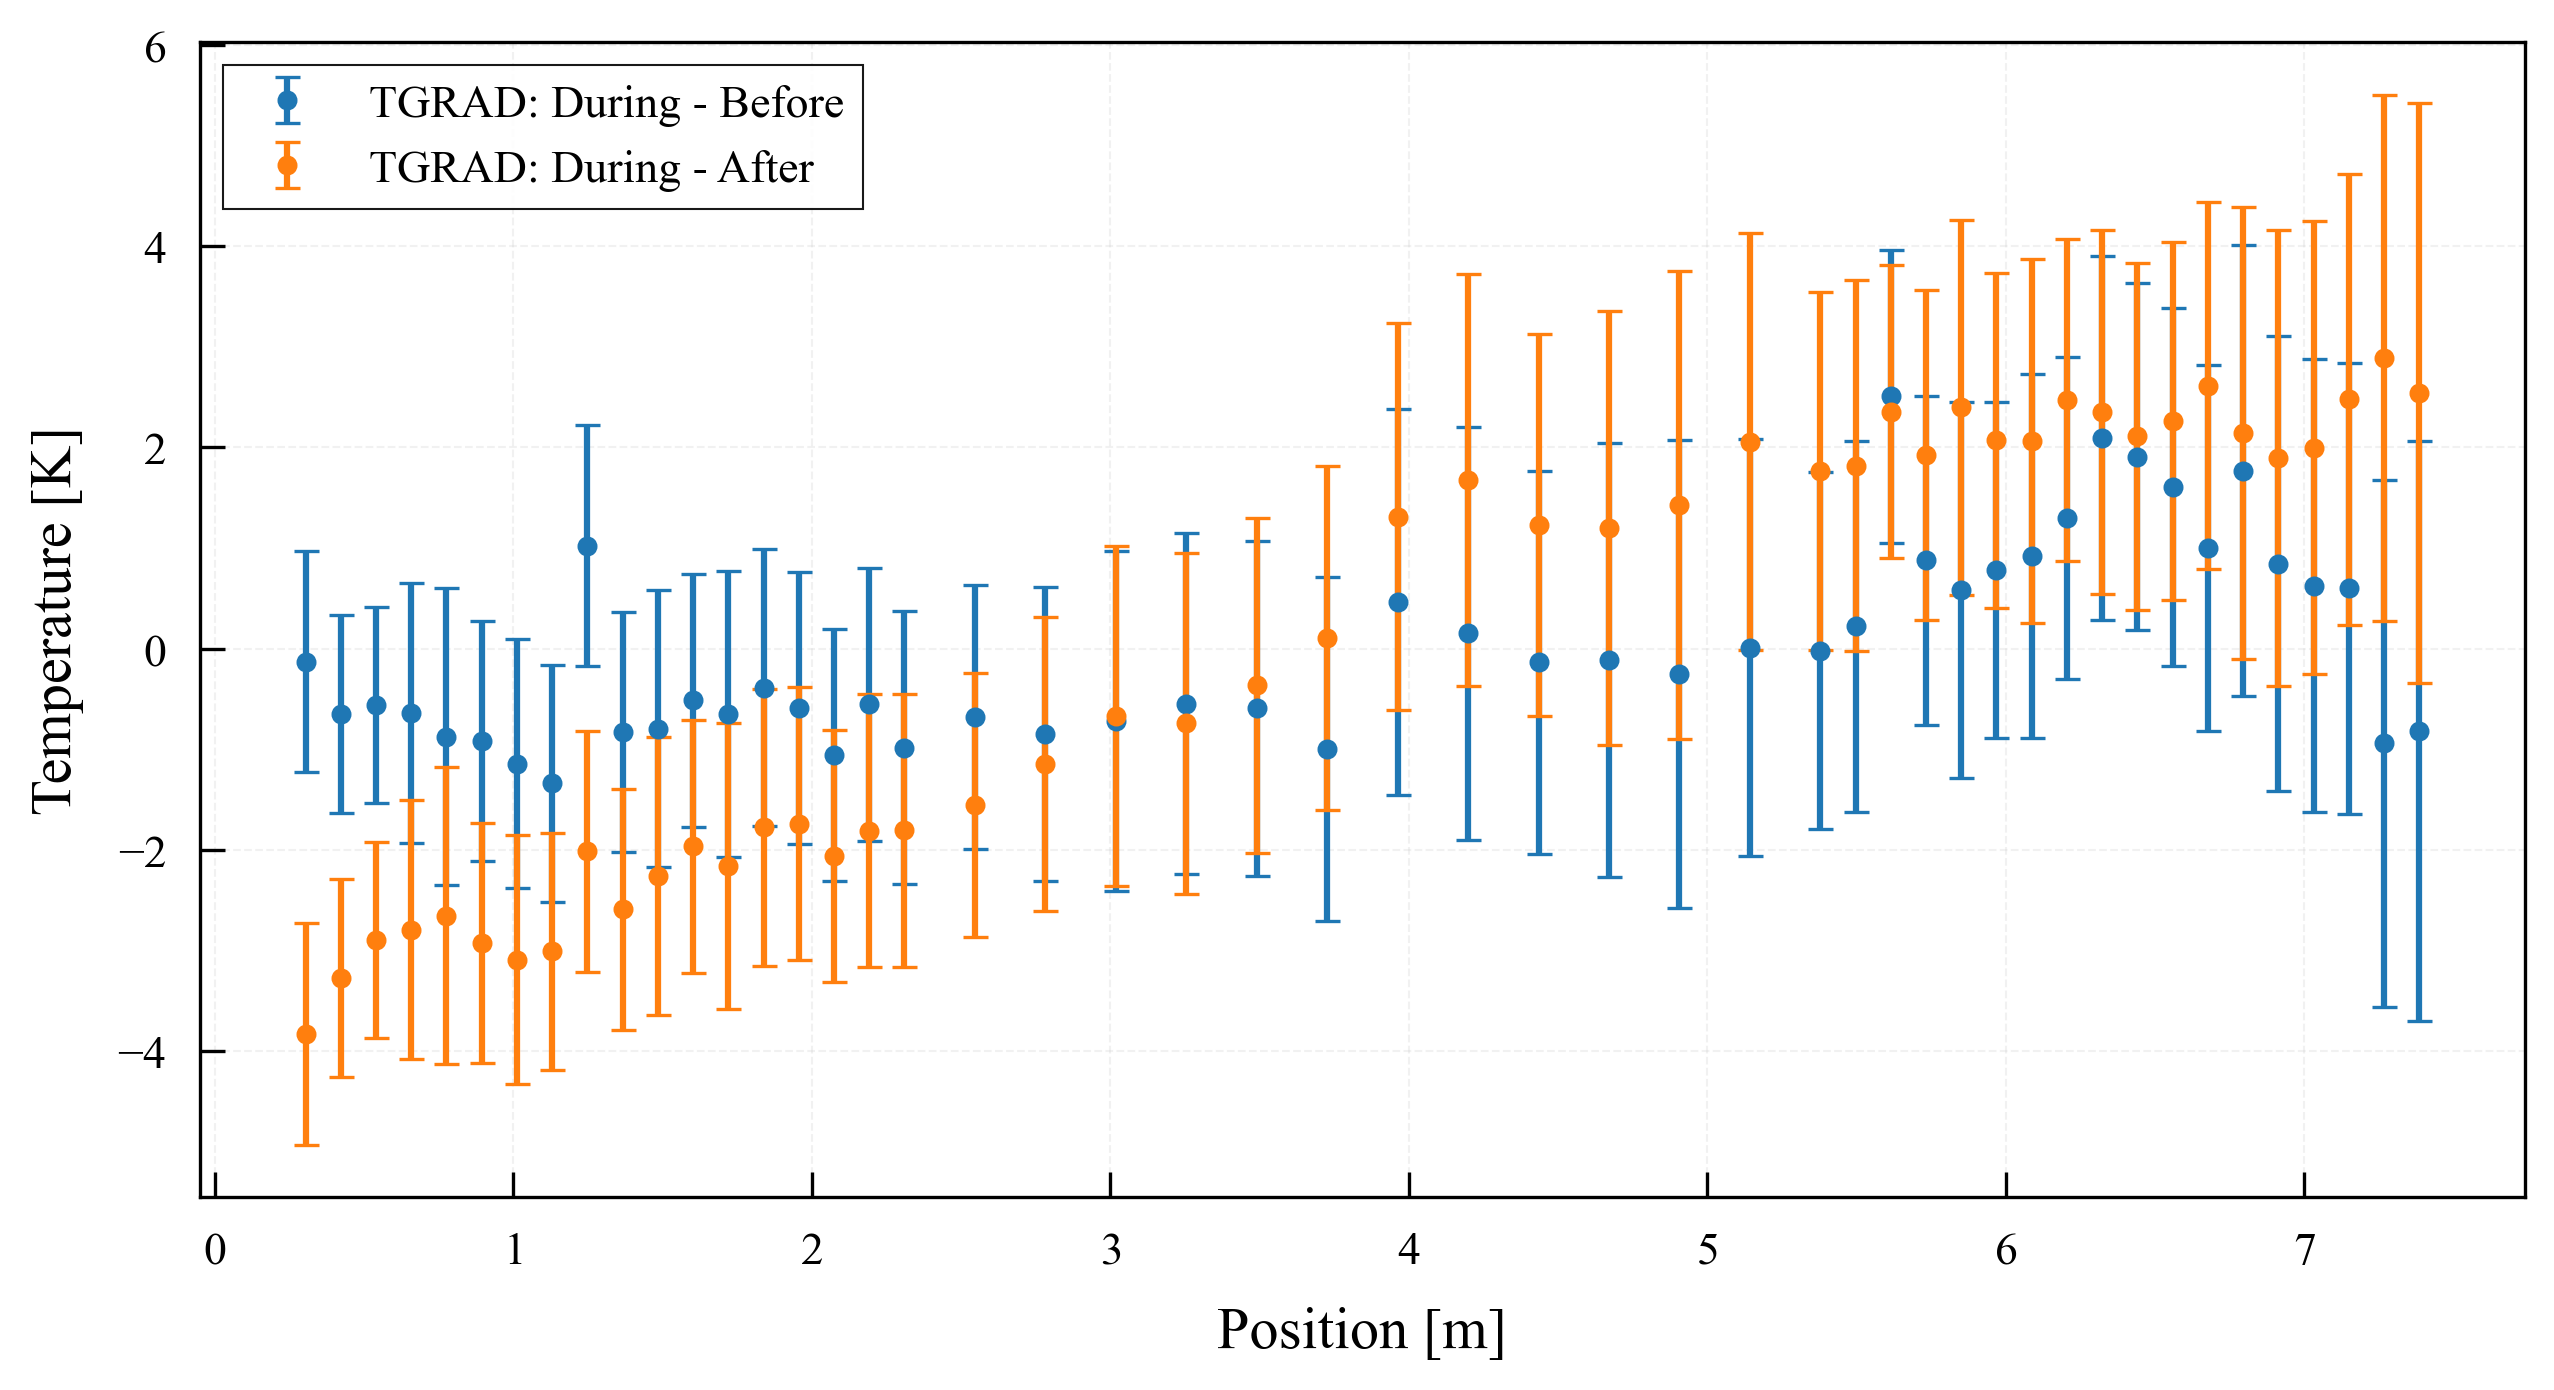

In [62]:
fig, axes = plt.subplots(1,1)
axes.errorbar(1e-3*pre_tgrad["Y"].values, 1e3*(during_tgrad["temp"] - pre_tgrad["temp"]) - 1e3*(during_tgrad["temp"] - pre_tgrad["temp"]).mean(), yerr=1e3*during_tgrad["err"].values, marker="o", linestyle="None", label="TGRAD: During - Before")
axes.errorbar(1e-3*post_tgrad["Y"].values, 1e3*(during_tgrad["temp"] - post_tgrad["temp"]) - 1e3*(during_tgrad["temp"] - post_tgrad["temp"]).mean(), yerr=1e3*during_tgrad["err"].values, marker="o", linestyle="None", label="TGRAD: During - After")
axes.set_xlabel("Position [m]")
axes.set_ylabel("Temperature [K]")
axes.legend()
fig.set_size_inches(10, 5)


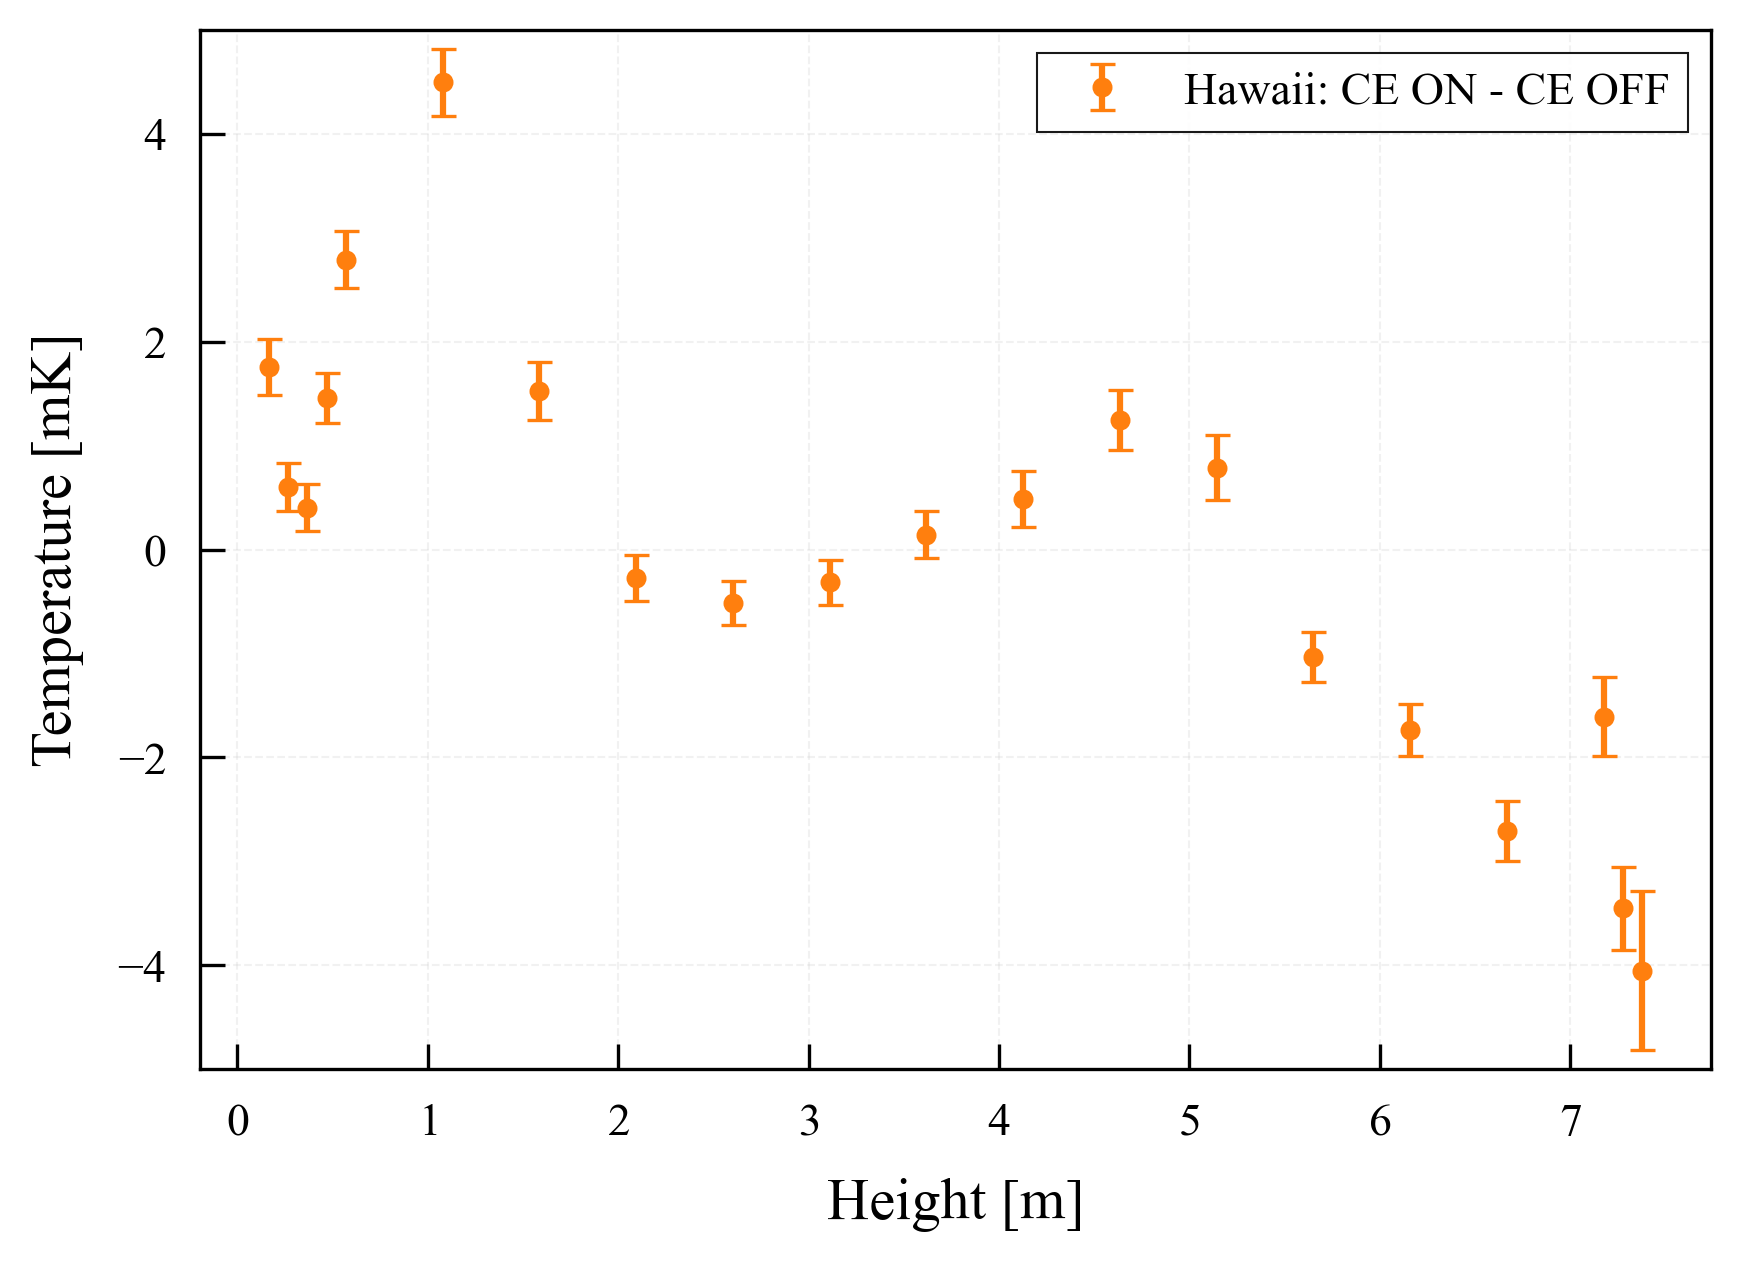

In [35]:
fig, axes = plt.subplots(1,1)
# axes.errorbar(1e-3*apa1_pre["Y"].values, 1e3*(apa1_during["temp"] - apa1_post["temp"]).values - 1e3*(apa1_during["temp"] - apa1_post["temp"]).mean(), yerr=1e3*np.sqrt(apa1_post["err"].values**2 + apa1_during["err"].values**2)/np.sqrt(len(during_hawai["temp"])), marker="o", linestyle="None", color="tab:gray", label="APA1: CE ON - CE OFF")
# axes.errorbar(1e-3*apa2_pre["Y"].values, 1e3*(apa2_during["temp"] - apa2_post["temp"]).values - 1e3*(apa2_during["temp"] - apa2_post["temp"]).mean(), yerr=1e3*np.sqrt(apa2_post["err"].values**2 + apa2_during["err"].values**2)/np.sqrt(len(during_hawai["temp"])), marker="o", linestyle="None", color="tab:pink", label="APA2: CE ON - CE OFF")
# axes.errorbar(1e-3*apa3_pre["Y"].values, 1e3*(apa3_during["temp"] - apa3_post["temp"]).values - 1e3*(apa3_during["temp"] - apa3_post["temp"]).mean(), yerr=1e3*np.sqrt(apa3_post["err"].values**2 + apa3_during["err"].values**2)/np.sqrt(len(during_hawai["temp"])), marker="o", linestyle="None", color="tab:olive", label="APA3: CE ON - CE OFF")
# axes.errorbar(1e-3*apa4_pre["Y"].values, 1e3*(apa4_during["temp"] - apa4_post["temp"]).values - 1e3*(apa4_during["temp"] - apa4_post["temp"]).mean(), yerr=1e3*np.sqrt(apa4_post["err"].values**2 + apa4_during["err"].values**2)/np.sqrt(len(during_hawai["temp"])), marker="o", linestyle="None", color="tab:cyan", label="APA4: CE ON - CE OFF")
# axes.errorbar(1e-3*pre_hawai["Y"].values, 1e3*(during_hawai["temp"].values - pre_hawai["temp"].values - (during_hawai["temp"] - pre_hawai["temp"]).mean()), yerr=1e3*np.sqrt(pre_hawai["err"].values**2 + during_hawai["err"].values**2), marker="o", linestyle="None", label="CE ON - CE OFF (Before)")
axes.errorbar(1e-3*during_hawai["Y"].values, 1e3*(during_hawai["temp"].values - post_hawai["temp"].values - (during_hawai["temp"] - post_hawai["temp"]).mean()), yerr=1e3*np.sqrt(during_hawai["err"].values**2 + post_hawai["err"].values**2), marker="o", linestyle="None", color="tab:orange", label="Hawaii: CE ON - CE OFF")
axes.set_xlabel("Height [m]")
axes.set_ylabel("Temperature [mK]")
axes.legend(ncol=1)
axes.set_ylim(-5, 5)
# fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/SENSITIVITY/CEON-CEOFF_hawaii_apa.png")
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/SENSITIVITY/CEON-CEOFF_hawaii.png")

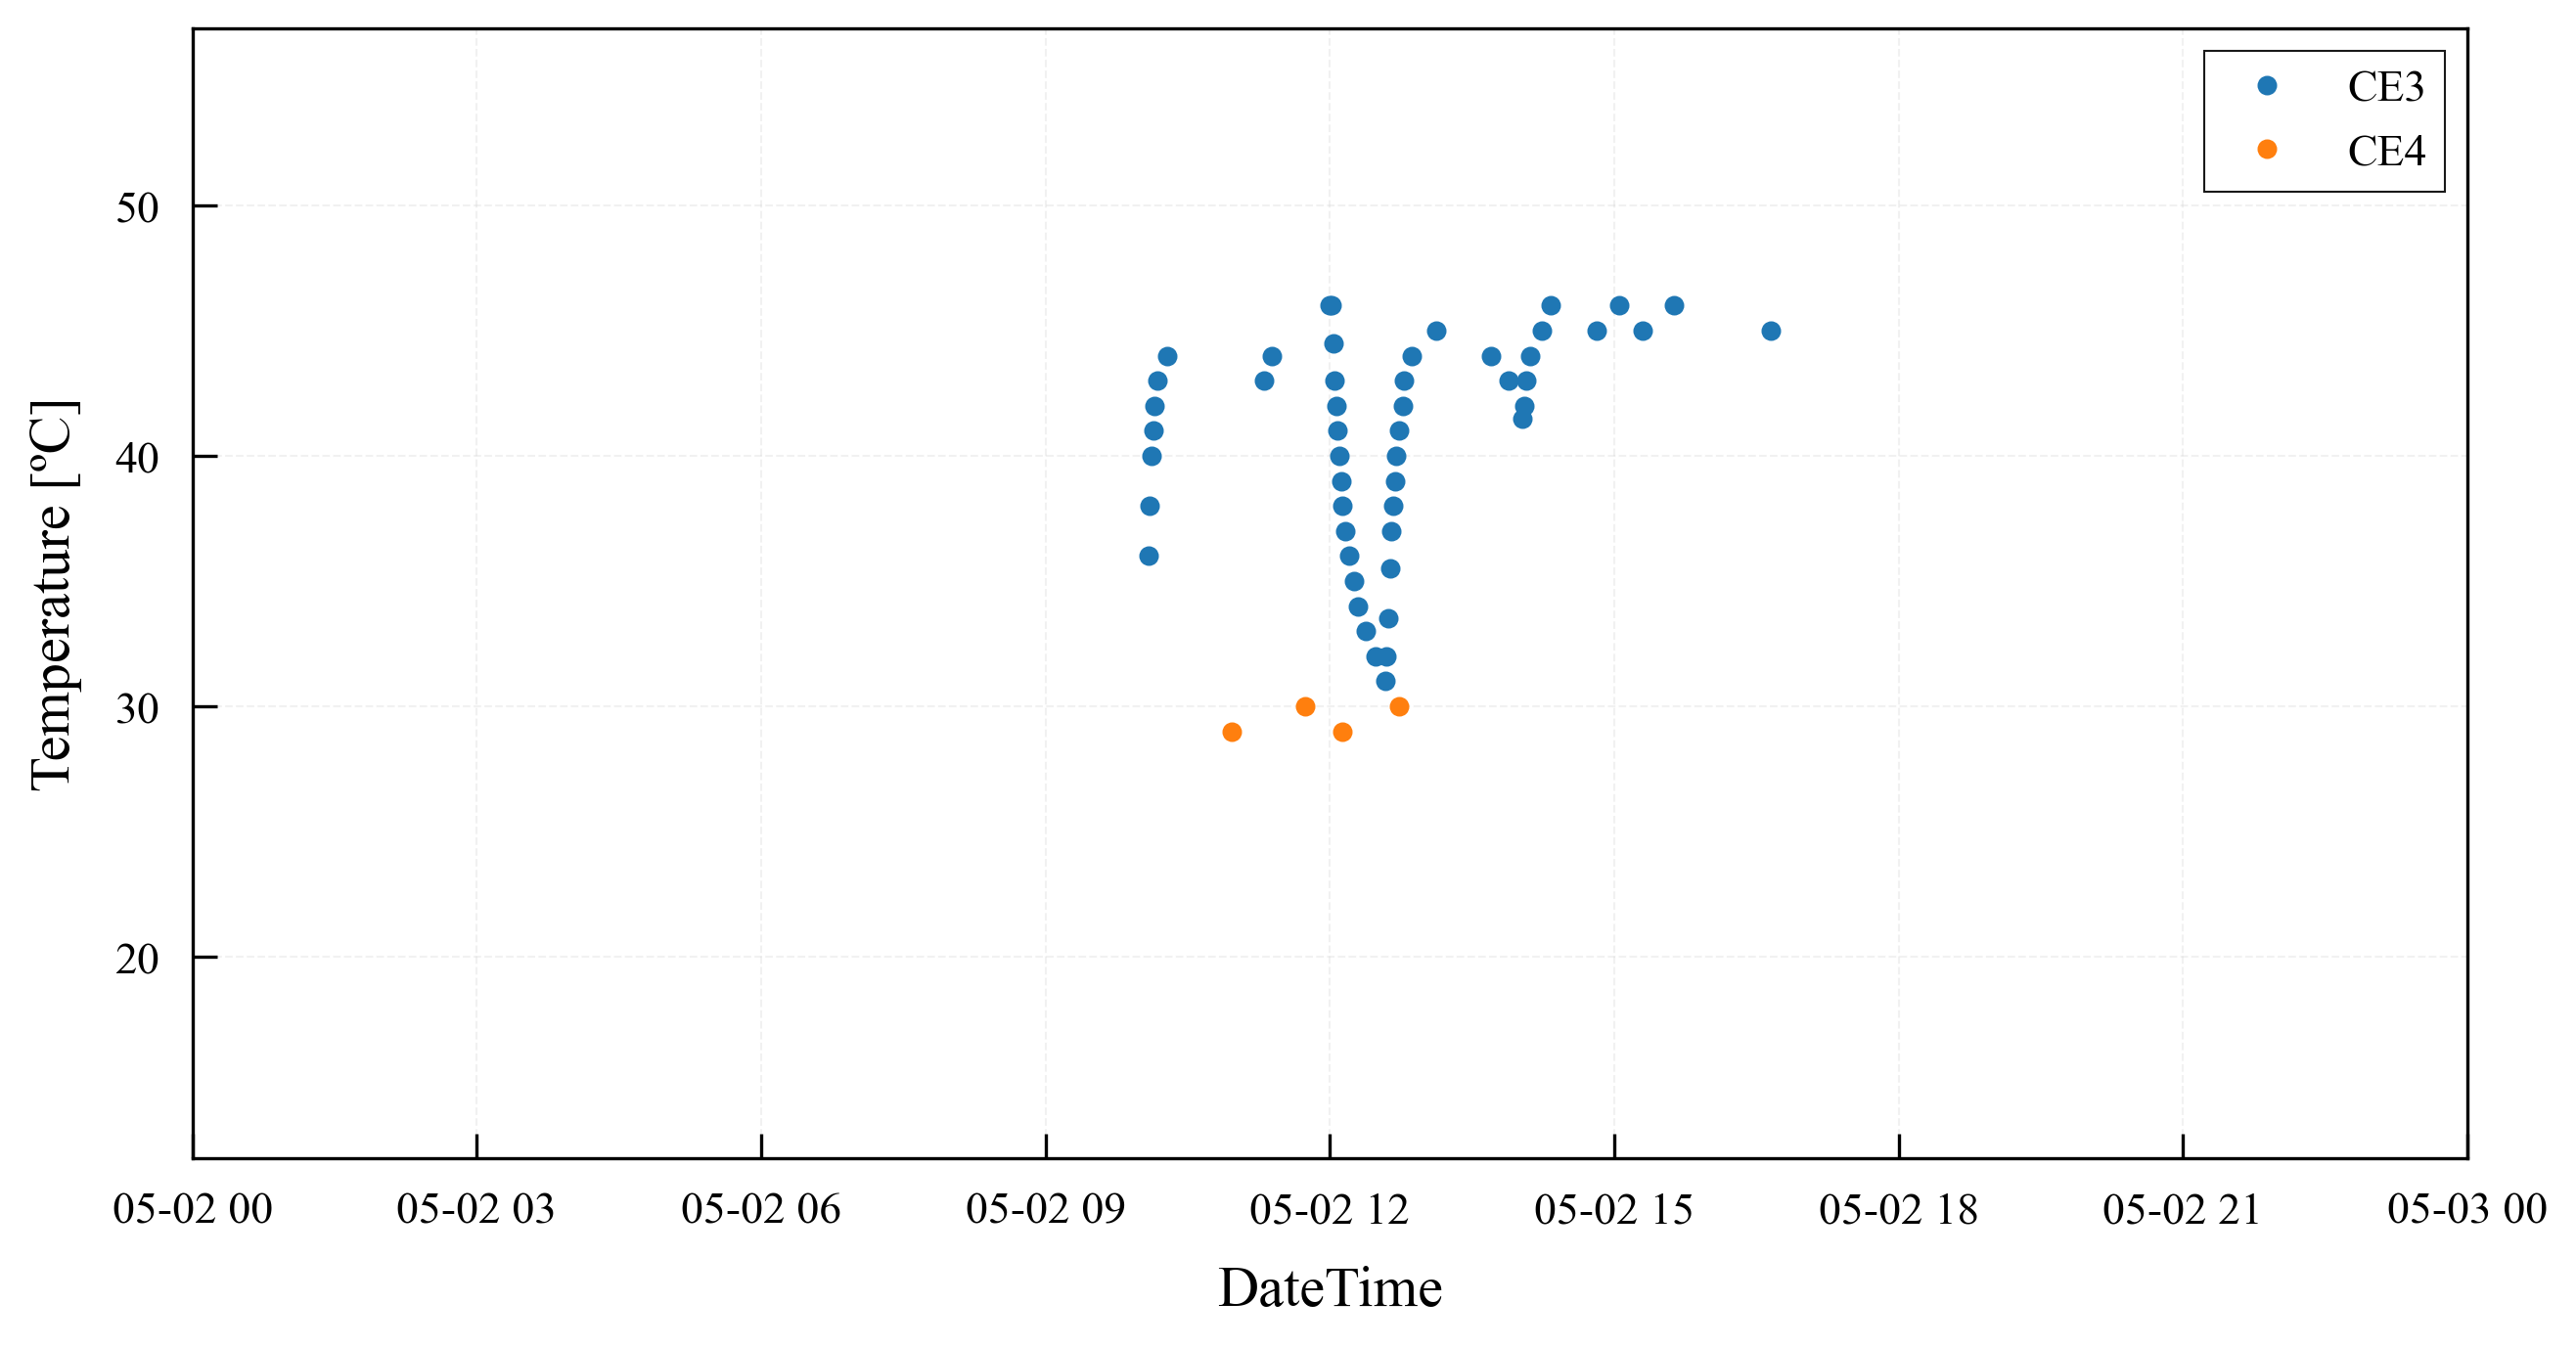

In [72]:
fig, axes = plt.subplots(1,1)
# axes.plot(ce1t.data.index.values, ce1t.data.values, marker="o", markersize=1.5, linestyle="None", label="CE1")
# axes.plot(ce2t.data.index.values, ce2t.data.values, marker="o", markersize=1.5, linestyle="None", label="CE2")
axes.plot(ce3t.data.index.values, ce3t.data.values, marker="o", linestyle="None", label="CE3")
axes.plot(ce4t.data.index.values, ce4t.data.values, marker="o", linestyle="None", label="CE4")
axes.set_xlabel("DateTime")
axes.set_ylabel("Temperature [ºC]")
axes.legend()
axes.set_xlim(datetime.datetime(2024, 5, 2, 0, 0), datetime.datetime(2024, 5, 3, 0, 0))
fig.set_size_inches(10, 5)

# Turning ON all the Cold Electronics

In [23]:
wall = systemClasses.System(dataset, "WALL")

Initializing WALL Sensors: 100%|██████████| 5/5 [00:00<00:00, 14.09sensor/s]


In [24]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
pipes.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
pumps.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
inlet.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
upstream.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
middle.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
downstream.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
apa1.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
apa2.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
apa3.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
apa4.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))
wall.makeProfiles(tini=datetime.datetime(2024, 5, 2, 9, 30), tend=datetime.datetime(2024, 5, 2, 10, 0))

preall_hawai = hawai.profiles
preall_tgrad = tgrad.profiles
preall_prm = prm.profiles
preall_apa1 = apa1.profiles
preall_apa2 = apa2.profiles
preall_apa3 = apa3.profiles
preall_apa4 = apa4.profiles
preall_pumps = pumps.profiles
preall_inlet = inlet.profiles
preall_upstream = upstream.profiles
preall_middle = middle.profiles
preall_downstream = downstream.profiles
preall_wall = wall.profiles


In [25]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
hawai.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
prm.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
pipes.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
pumps.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
inlet.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
upstream.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
middle.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
downstream.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
apa1.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
apa2.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
apa3.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
apa4.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))
wall.makeProfiles(tini=datetime.datetime(2024, 5, 2, 10, 5), tend=datetime.datetime(2024, 5, 2, 10, 40))

duringall_hawai = hawai.profiles
duringall_tgrad = tgrad.profiles
duringall_prm = prm.profiles
duringall_apa1 = apa1.profiles
duringall_apa2 = apa2.profiles
duringall_apa3 = apa3.profiles
duringall_apa4 = apa4.profiles
duringall_pumps = pumps.profiles
duringall_inlet = inlet.profiles
duringall_upstream = upstream.profiles
duringall_middle = middle.profiles
duringall_downstream = downstream.profiles
duringall_wall = wall.profiles

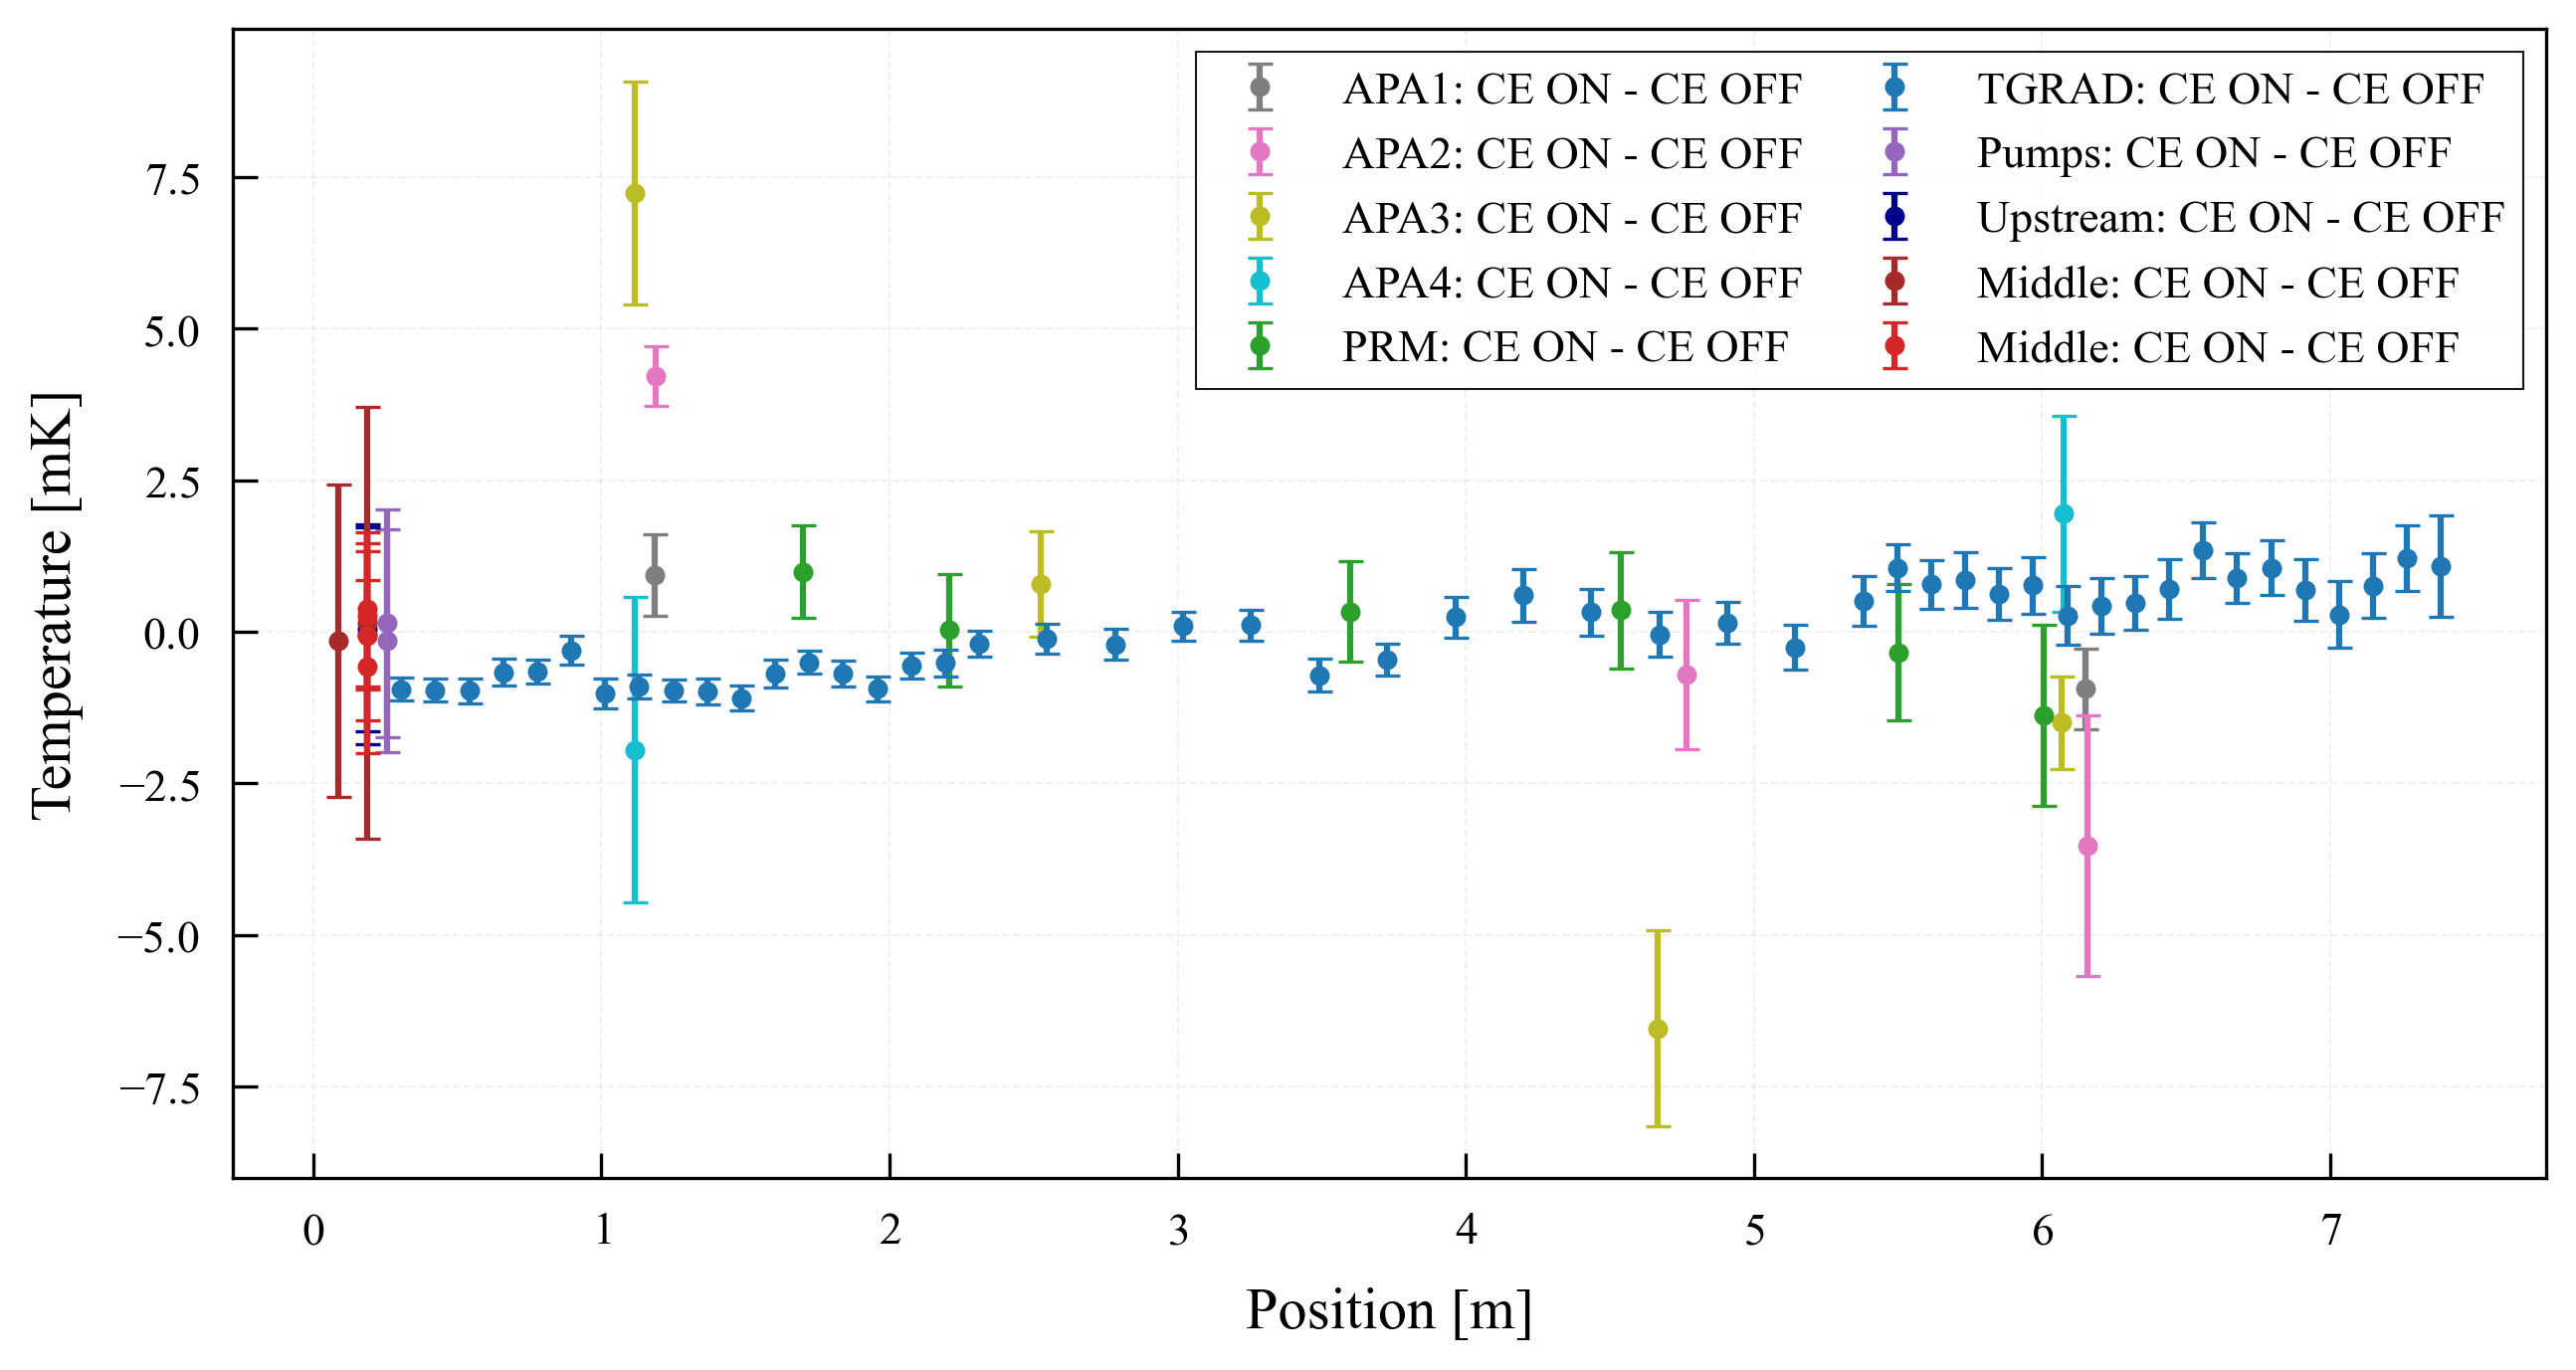

In [26]:
fig, axes = plt.subplots(1,1)
axes.errorbar(1e-3*duringall_apa1["Y"].values, 1e3*(duringall_apa1["temp"] - preall_apa1["temp"]).values - 1e3*(duringall_apa1["temp"] - preall_apa1["temp"]).mean(), yerr=1e3*np.sqrt(preall_apa1["err"].values**2 + duringall_apa1["err"].values**2)/np.sqrt(len(duringall_apa1["temp"])), marker="o", linestyle="None", color="tab:gray", label="APA1: CE ON - CE OFF")
axes.errorbar(1e-3*duringall_apa2["Y"].values, 1e3*(duringall_apa2["temp"] - preall_apa2["temp"]).values - 1e3*(duringall_apa2["temp"] - preall_apa2["temp"]).mean(), yerr=1e3*np.sqrt(preall_apa2["err"].values**2 + duringall_apa2["err"].values**2)/np.sqrt(len(duringall_apa2["temp"])), marker="o", linestyle="None", color="tab:pink", label="APA2: CE ON - CE OFF")
axes.errorbar(1e-3*duringall_apa3["Y"].values, 1e3*(duringall_apa3["temp"] - preall_apa3["temp"]).values - 1e3*(duringall_apa3["temp"] - preall_apa3["temp"]).mean(), yerr=1e3*np.sqrt(preall_apa3["err"].values**2 + duringall_apa3["err"].values**2)/np.sqrt(len(duringall_apa3["temp"])), marker="o", linestyle="None", color="tab:olive", label="APA3: CE ON - CE OFF")
axes.errorbar(1e-3*duringall_apa4["Y"].values, 1e3*(duringall_apa4["temp"] - preall_apa4["temp"]).values - 1e3*(duringall_apa4["temp"] - preall_apa4["temp"]).mean(), yerr=1e3*np.sqrt(preall_apa4["err"].values**2 + duringall_apa4["err"].values**2)/np.sqrt(len(duringall_apa4["temp"])), marker="o", linestyle="None", color="tab:cyan", label="APA4: CE ON - CE OFF")
axes.errorbar(1e-3*duringall_prm["Y"].values, 1e3*(duringall_prm["temp"] - preall_prm["temp"]).values - 1e3*(duringall_prm["temp"] - preall_prm["temp"]).mean(), yerr=1e3*np.sqrt(preall_prm["err"].values**2 + duringall_prm["err"].values**2)/np.sqrt(len(duringall_prm["temp"])), marker="o", linestyle="None", color="tab:green", label="PRM: CE ON - CE OFF")
axes.errorbar(1e-3*duringall_tgrad["Y"].values, 1e3*(duringall_tgrad["temp"] - preall_tgrad["temp"]).values - 1e3*(duringall_tgrad["temp"] - preall_tgrad["temp"]).mean(), yerr=1e3*np.sqrt(preall_tgrad["err"].values**2 + duringall_tgrad["err"].values**2)/np.sqrt(len(duringall_tgrad["temp"])), marker="o", linestyle="None", color="tab:blue", label="TGRAD: CE ON - CE OFF")
axes.errorbar(1e-3*duringall_pumps["Y"].values, 1e3*(duringall_pumps["temp"] - preall_pumps["temp"]).values - 1e3*(duringall_pumps["temp"] - preall_pumps["temp"]).mean(), yerr=1e3*np.sqrt(preall_pumps["err"].values**2 + duringall_pumps["err"].values**2)/np.sqrt(len(duringall_pumps["temp"])), marker="o", linestyle="None", color="tab:purple", label="Pumps: CE ON - CE OFF")
axes.errorbar(1e-3*duringall_upstream["Y"].values, 1e3*(duringall_upstream["temp"] - preall_upstream["temp"]).values - 1e3*(duringall_upstream["temp"] - preall_upstream["temp"]).mean(), yerr=1e3*np.sqrt(preall_upstream["err"].values**2 + duringall_upstream["err"].values**2)/np.sqrt(len(duringall_upstream["temp"])), marker="o", linestyle="None", color="darkblue", label="Upstream: CE ON - CE OFF")
axes.errorbar(1e-3*duringall_middle["Y"].values, 1e3*(duringall_middle["temp"] - preall_middle["temp"]).values - 1e3*(duringall_middle["temp"] - preall_middle["temp"]).mean(), yerr=1e3*np.sqrt(preall_middle["err"].values**2 + duringall_middle["err"].values**2)/np.sqrt(len(duringall_middle["temp"])), marker="o", linestyle="None", color="brown", label="Middle: CE ON - CE OFF")
axes.errorbar(1e-3*duringall_downstream["Y"].values, 1e3*(duringall_downstream["temp"] - preall_downstream["temp"]).values - 1e3*(duringall_downstream["temp"] - preall_downstream["temp"]).mean(), yerr=1e3*np.sqrt(preall_downstream["err"].values**2 + duringall_downstream["err"].values**2)/np.sqrt(len(duringall_downstream["temp"])), marker="o", linestyle="None", color="tab:red", label="Middle: CE ON - CE OFF")
# axes.errorbar(1e-3*duringall_wall["Y"].values, 1e3*(duringall_wall["temp"] - preall_wall["temp"]).values - 1e3*(duringall_wall["temp"] - preall_wall["temp"]).mean(), yerr=1e3*np.sqrt(preall_wall["err"].values**2 + duringall_wall["err"].values**2)/np.sqrt(len(duringall_wall["temp"])), marker="o", linestyle="None", color="darkgreen", label="Wall: CE ON - CE OFF")
axes.set_xlabel("Position [m]")
axes.set_ylabel("Temperature [mK]")
axes.legend(ncol=1)

axes.set_ylabel("Temperature [mK]")
axes.legend(ncol=2)
fig.set_size_inches(10, 5)
# fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/SENSITIVITY/CEON-CEOFF_hawaii_apa.png")

# Second Pumps-Off Period

In [22]:
dataset = baseClasses.Data()

In [23]:
mask_second_poff = (
    ((dataset.data.index > datetime.datetime(2024, 11, 28)) & (dataset.data.index < datetime.datetime(2024, 12, 5)))
)

dataset.data = dataset.data.loc[mask_second_poff]
dataset.err = dataset.err.loc[mask_second_poff]

In [24]:
tgrad = systemClasses.System(dataset, "TGRAD")
hawai = systemClasses.System(dataset, "HAWAI")
prm = systemClasses.System(dataset, "PRM")
apa1 = systemClasses.System(dataset, sensor_names=["APA1LAr1", "APA1LAr4"])
apa2 = systemClasses.System(dataset, sensor_names=["APA2LAr1", "APA2LAr2", "APA2LAr3", "APA2LAr4"])
apa3 = systemClasses.System(dataset, sensor_names=["APA3LAr1", "APA3LAr2", "APA3LAr3", "APA3LAr4"])
apa4 = systemClasses.System(dataset, sensor_names=["APA4LAr1", "APA4LAr4"])
inlet = systemClasses.System(dataset, sensor_names=["1-I", "3-I", "4-I"])
upstream = systemClasses.System(dataset, sensor_names=["2-M", "4-M"])
middle = systemClasses.System(dataset, sensor_names=["1-M", "3-M"])
downstream = systemClasses.System(dataset, sensor_names=["1-U", "2-U", "3-U", "4-U"])
pipes = systemClasses.System(dataset, "PIPE")
pumps = systemClasses.System(dataset, "PP")
tgrad.calibrate("FIRST_POFF_PIPES")
hawai.calibrate("SECOND_POFF_EMPTY")
prm.calibrate("SECOND_POFF_OCTOBER")
pipes.calibrate("SECOND_POFF_OCTOBER")
pumps.calibrate("SECOND_POFF_OCTOBER")
inlet.calibrate("SECOND_POFF_OCTOBER")
upstream.calibrate("SECOND_POFF_OCTOBER")
middle.calibrate("SECOND_POFF_OCTOBER")
downstream.calibrate("SECOND_POFF_OCTOBER")
apa1.calibrate("SECOND_POFF_OCTOBER")
apa2.calibrate("SECOND_POFF_OCTOBER")
apa3.calibrate("SECOND_POFF_OCTOBER")
apa4.calibrate("SECOND_POFF_OCTOBER")


Initializing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 11.52sensor/s]


ERROR: Channel (TE0120) not found


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00, 11.79sensor/s]


ERROR: Channel (TE0120) not found


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00, 10.73sensor/s]
Calibrating TGRAD Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 48/48 [00:00<00:00, 93.85sensor/s] 
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 11.38sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 24/24 [00:00<00:00, 109.88sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  9.31sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 115.23sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  7.88sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 79.62sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  4.77sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 95.73sensor/s]
Equalizing Custom Sensors: 100%|██████████| 3/3 [00:00<00:00,  7.15sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 3/3 [00:00<00:00, 107.55sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00,  9.44sensor/s]


ERROR: Channel (TE0120) not found


Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 95.33sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00, 10.06sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 107.85sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00,  5.89sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 4/4 [00:00<00:00, 71.58sensor/s]
Equalizing Custom Sensors: 100%|██████████| 2/2 [00:00<00:00,  8.39sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 102.28sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00, 15.97sensor/s]
Calibrating Custom Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 4/4 [00:00<00:00, 111.73sensor/s]
Equalizing Custom Sensors: 100%|██████████| 4/4 [00:00<00:00, 16.42sensor/s]
Calibrating Custom Sen

In [25]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 13, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))
pipes.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))
pumps.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))
inlet.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))
upstream.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))
middle.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))
downstream.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))
apa1.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))
apa2.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))
apa3.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))
apa4.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 0), tend=datetime.datetime(2024, 11, 29, 20, 0))

pre_hawai = hawai.profiles
pre_tgrad = tgrad.profiles
pre_prm = prm.profiles
pre_pipes = pipes.profiles
pre_pumps = pumps.profiles
pre_inlet = inlet.profiles
pre_upstream = upstream.profiles
pre_middle = middle.profiles
pre_downstream = downstream.profiles
apa1_pre = apa1.profiles
apa2_pre = apa2.profiles
apa3_pre = apa3.profiles
apa4_pre = apa4.profiles


In [26]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 2, 9, 0), tend=datetime.datetime(2024, 12, 2, 10, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))
pipes.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))
pumps.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))
inlet.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))
upstream.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))
middle.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))
downstream.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))
apa1.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))
apa2.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))
apa3.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))
apa4.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 0), tend=datetime.datetime(2024, 12, 2, 11, 0))

during_hawai = hawai.profiles
during_tgrad = tgrad.profiles
during_prm = prm.profiles
during_pipes = pipes.profiles
during_pumps = pumps.profiles
during_inlet = inlet.profiles
during_upstream = upstream.profiles
during_middle = middle.profiles
during_downstream = downstream.profiles
apa1_during = apa1.profiles
apa2_during = apa2.profiles
apa3_during = apa3.profiles
apa4_during = apa4.profiles


<ErrorbarContainer object of 3 artists>

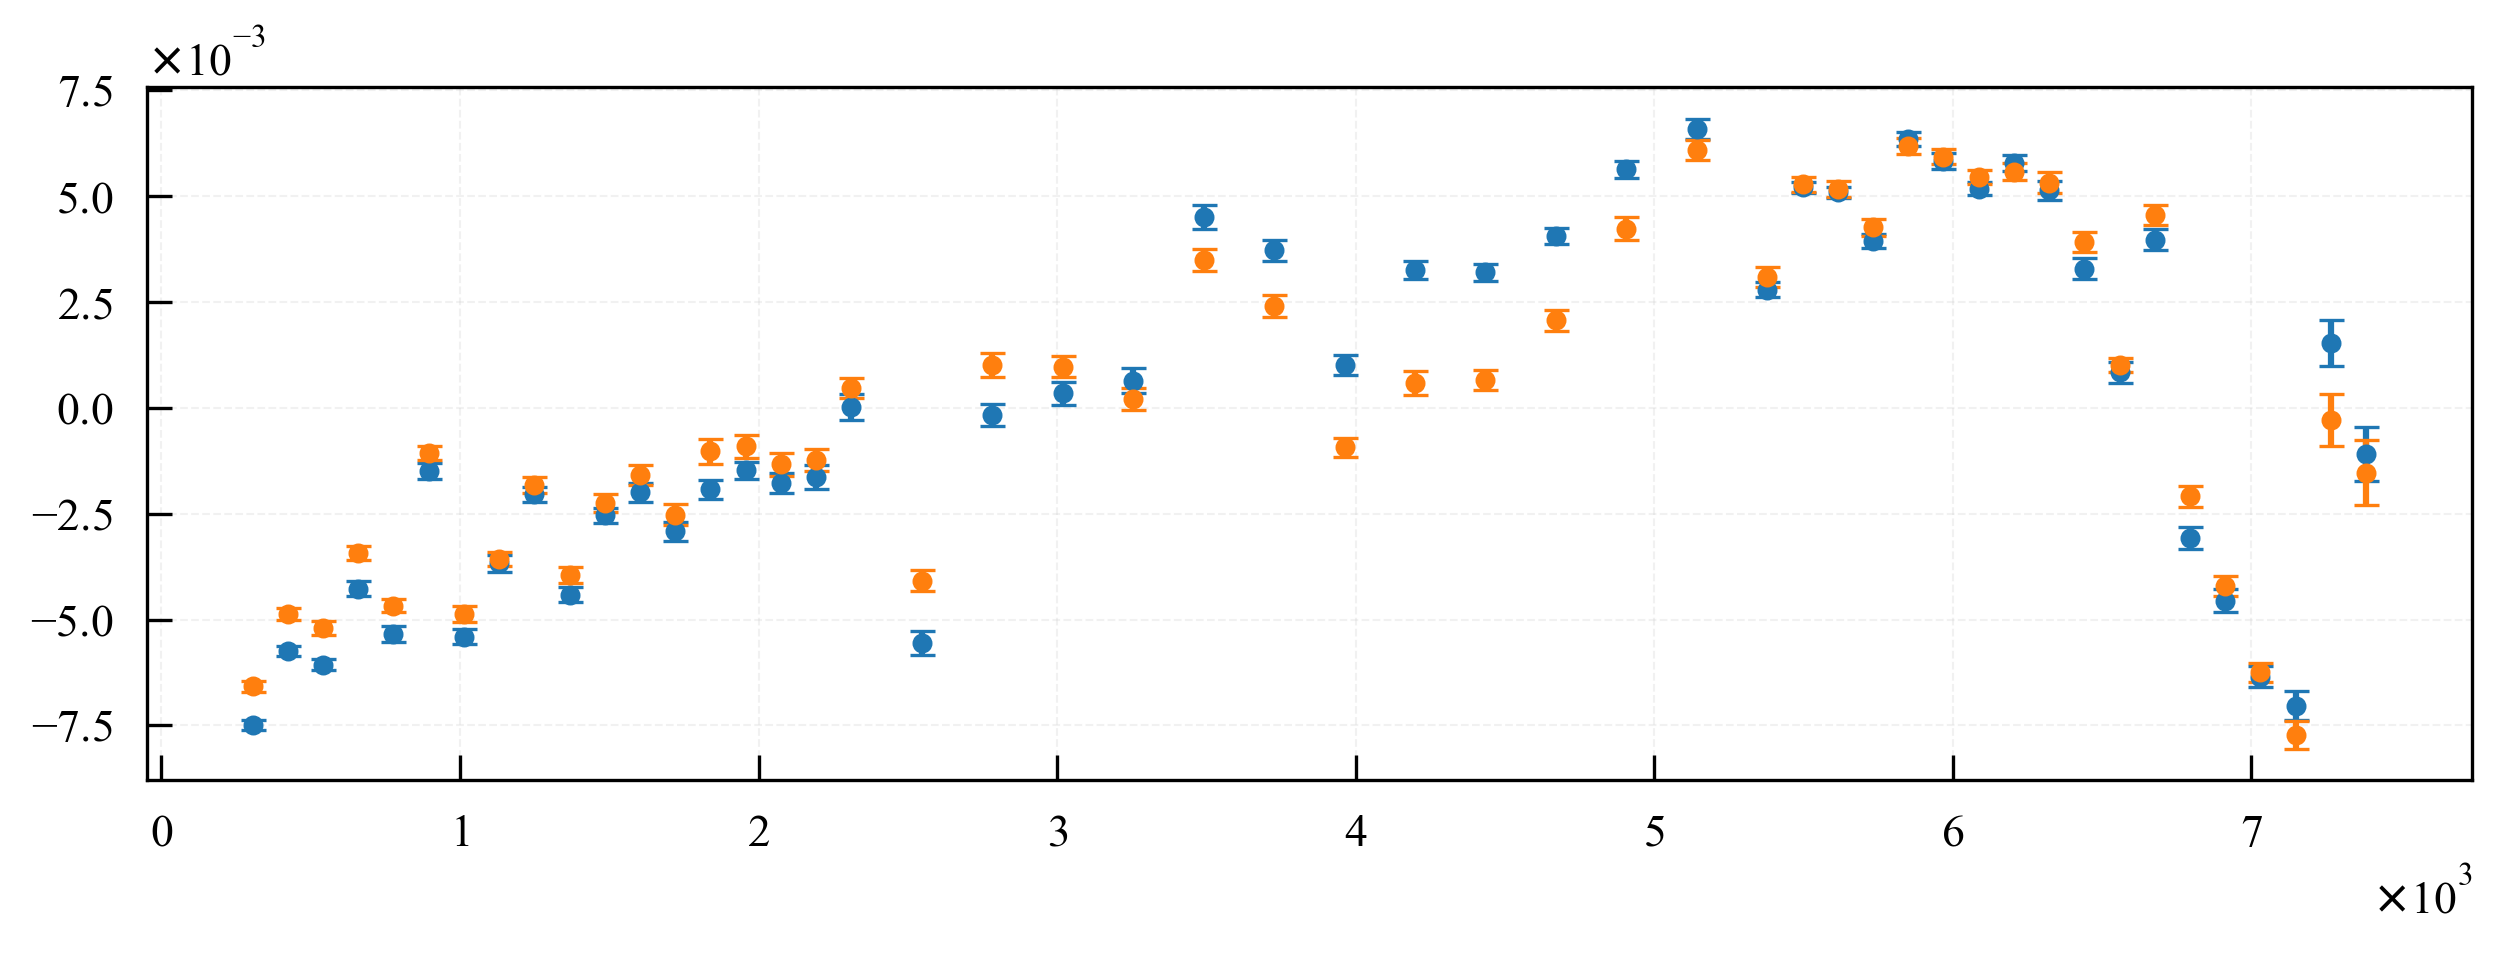

In [9]:
fig, axes = plt.subplots(1,1)
fig.set_size_inches(10, 3)
axes.errorbar(pre_tgrad["Y"].values, pre_tgrad["temp"].values - pre_tgrad["temp"].values.mean(), yerr=pre_tgrad["err"].values, marker="o", linestyle="None", label="TGRAD")
axes.errorbar(during_tgrad["Y"].values, during_tgrad["temp"].values - during_tgrad["temp"].values.mean(), yerr=during_tgrad["err"].values, marker="o", linestyle="None", label="TGRAD")

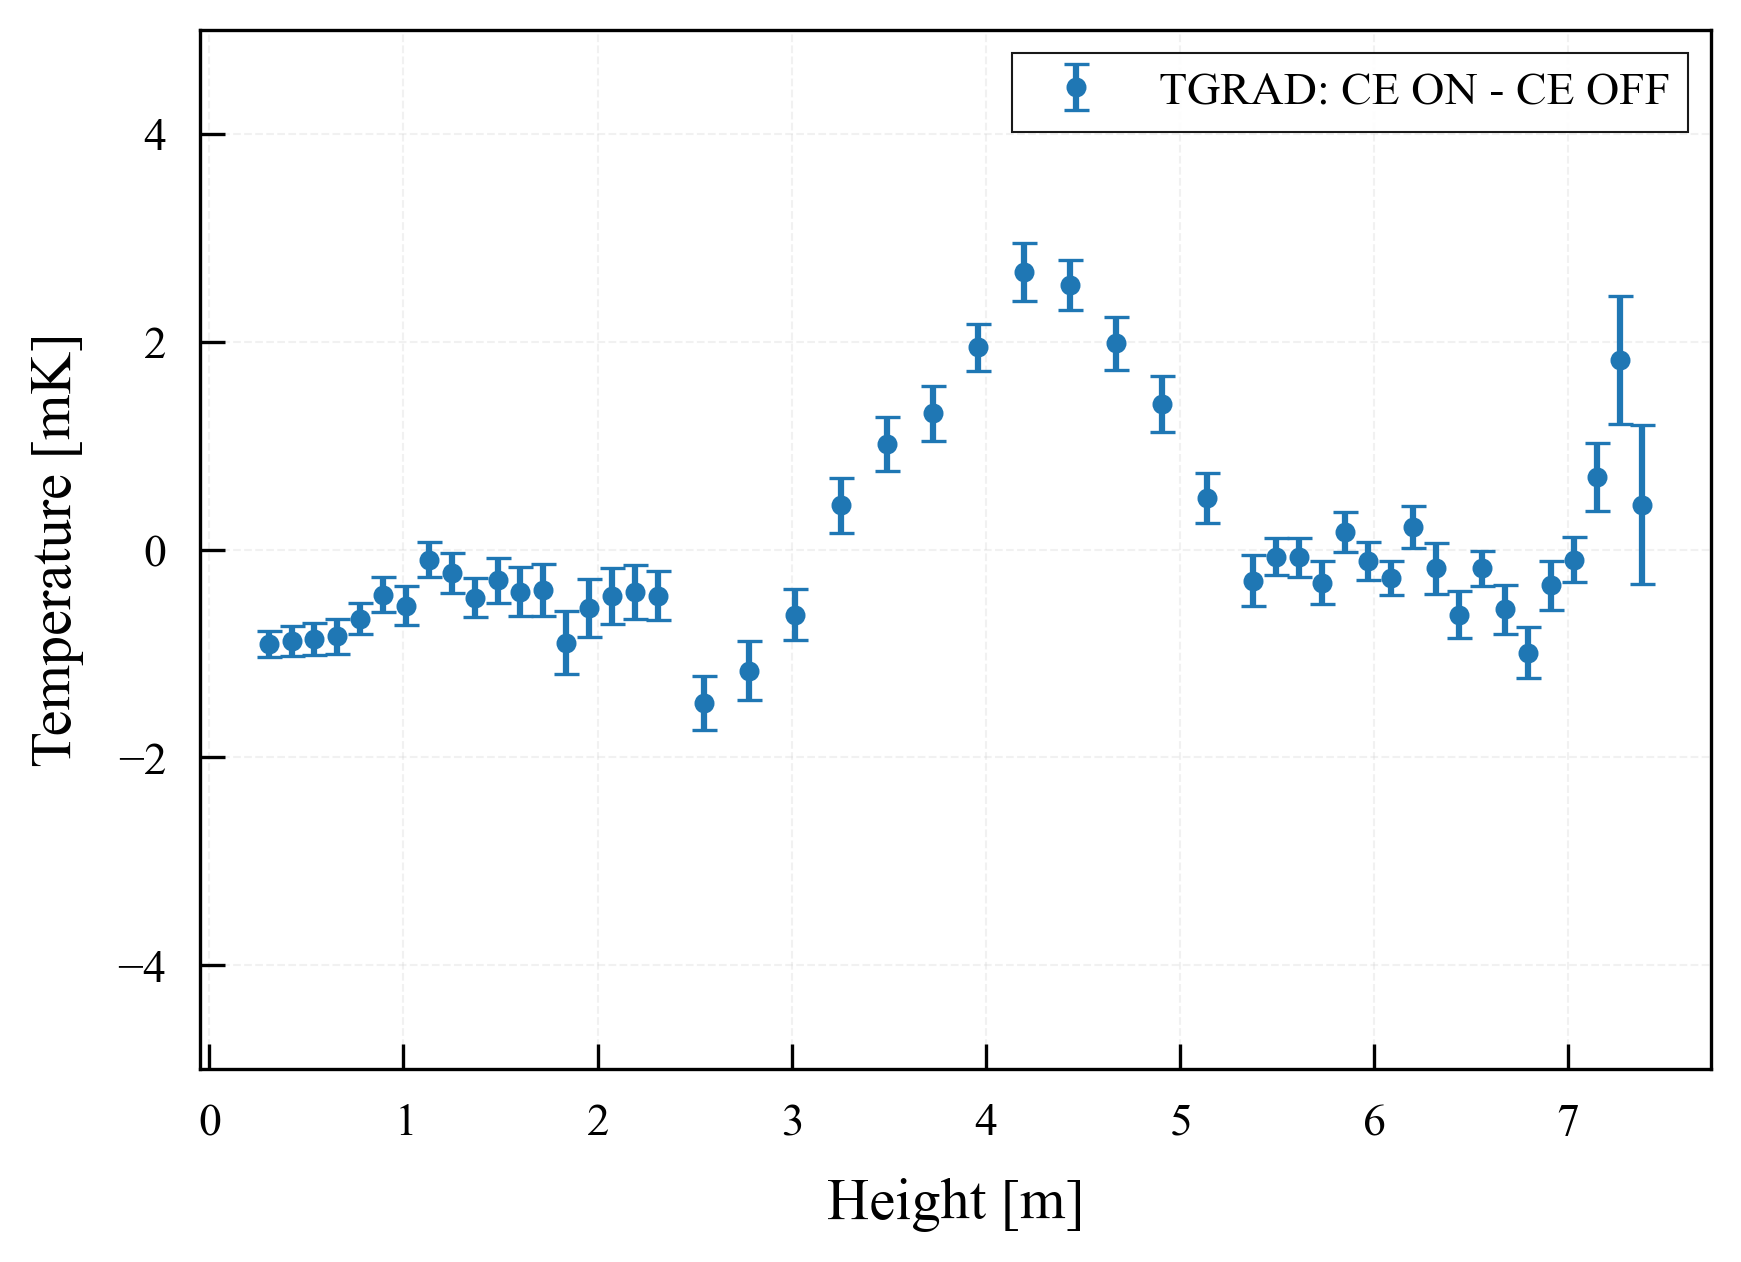

In [28]:
fig, axes = plt.subplots(1,1)
# axes.errorbar(1e-3*apa1_pre["Y"].values, 1e3*(apa1_during["temp"] - apa1_pre["temp"]).values - 1e3*(apa1_during["temp"] - apa1_pre["temp"]).mean(), yerr=1e3*np.sqrt(apa1_pre["err"].values**2 + apa1_during["err"].values**2)/np.sqrt(len(apa1_pre["temp"])), marker="o", linestyle="None", color="tab:gray", label="APA1: CE ON - CE OFF")
# axes.errorbar(1e-3*apa2_pre["Y"].values, 1e3*(apa2_during["temp"] - apa2_pre["temp"]).values - 1e3*(apa2_during["temp"] - apa2_pre["temp"]).mean(), yerr=1e3*np.sqrt(apa2_pre["err"].values**2 + apa2_during["err"].values**2)/np.sqrt(len(apa2_pre["temp"])), marker="o", linestyle="None", color="tab:pink", label="APA2: CE ON - CE OFF")
# axes.errorbar(1e-3*apa3_pre["Y"].values, 1e3*(apa3_during["temp"] - apa3_pre["temp"]).values - 1e3*(apa3_during["temp"] - apa3_pre["temp"]).mean(), yerr=1e3*np.sqrt(apa3_pre["err"].values**2 + apa3_during["err"].values**2)/np.sqrt(len(apa3_pre["temp"])), marker="o", linestyle="None", color="tab:olive", label="APA3: CE ON - CE OFF")
# axes.errorbar(1e-3*apa4_pre["Y"].values, 1e3*(apa4_during["temp"] - apa4_pre["temp"]).values - 1e3*(apa4_during["temp"] - apa4_pre["temp"]).mean(), yerr=1e3*np.sqrt(apa4_pre["err"].values**2 + apa4_during["err"].values**2)/np.sqrt(len(apa4_pre["temp"])), marker="o", linestyle="None", color="tab:cyan", label="APA4: CE ON - CE OFF")
axes.errorbar(1e-3*pre_tgrad["Y"].values, 1e3*(pre_tgrad["temp"] - during_tgrad["temp"]) - 1e3*(pre_tgrad["temp"] - during_tgrad["temp"]).mean(), yerr=1e3*during_tgrad["err"].values, marker="o", linestyle="None", label="TGRAD: CE ON - CE OFF")
# axes.errorbar(1e-3*pre_prm["Y"].values, 1e3*(during_prm["temp"] - pre_prm["temp"]) - 1e3*(during_prm["temp"] - pre_prm["temp"]).mean(), yerr=1e3*during_prm["err"].values, marker="o", linestyle="None", label="PRM: During - Before")
# axes.errorbar(1e-3*pre_hawai["Y"].values, 1e3*(during_hawai["temp"].values - pre_hawai["temp"].values - (during_hawai["temp"] - pre_hawai["temp"]).mean()), yerr=1e3*np.sqrt(pre_hawai["err"].values**2 + during_hawai["err"].values**2), marker="o", linestyle="None", label="CE ON - CE OFF (Before)")
# axes.errorbar(1e-3*during_hawai["Y"].values, 1e3*(during_hawai["temp"].values - post_hawai["temp"].values - (during_hawai["temp"] - post_hawai["temp"]).mean()), yerr=1e3*np.sqrt(during_hawai["err"].values**2 + post_hawai["err"].values**2)/np.sqrt(len(during_hawai["temp"])), marker="o", linestyle="None", color="tab:orange", label="Hawaii: CE ON - CE OFF")
axes.set_xlabel("Height [m]")
axes.set_ylabel("Temperature [mK]")
axes.set_ylim(-5,5)
axes.legend(ncol=1)
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/SENSITIVITY/CEON-CEOFF_valencia.png")

In [9]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
prm.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
pipes.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
pumps.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
inlet.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
upstream.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
middle.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
downstream.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
apa1.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
apa2.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
apa3.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))
apa4.makeProfiles(tini=datetime.datetime(2024, 12, 3, 17, 0), tend=datetime.datetime(2024, 12, 3, 17, 30))

pre_hawai = hawai.profiles
pre_tgrad = tgrad.profiles
apa1_pre = apa1.profiles
apa2_pre = apa2.profiles
apa3_pre = apa3.profiles
apa4_pre = apa4.profiles


In [10]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
pipes.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
pumps.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
inlet.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
upstream.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
middle.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
downstream.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
apa1.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
apa2.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
apa3.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))
apa4.makeProfiles(tini=datetime.datetime(2024, 12, 3, 18, 0), tend=datetime.datetime(2024, 12, 3, 19, 0))

during_hawai = hawai.profiles
during_tgrad = tgrad.profiles
apa1_during = apa1.profiles
apa2_during = apa2.profiles
apa3_during = apa3.profiles
apa4_during = apa4.profiles


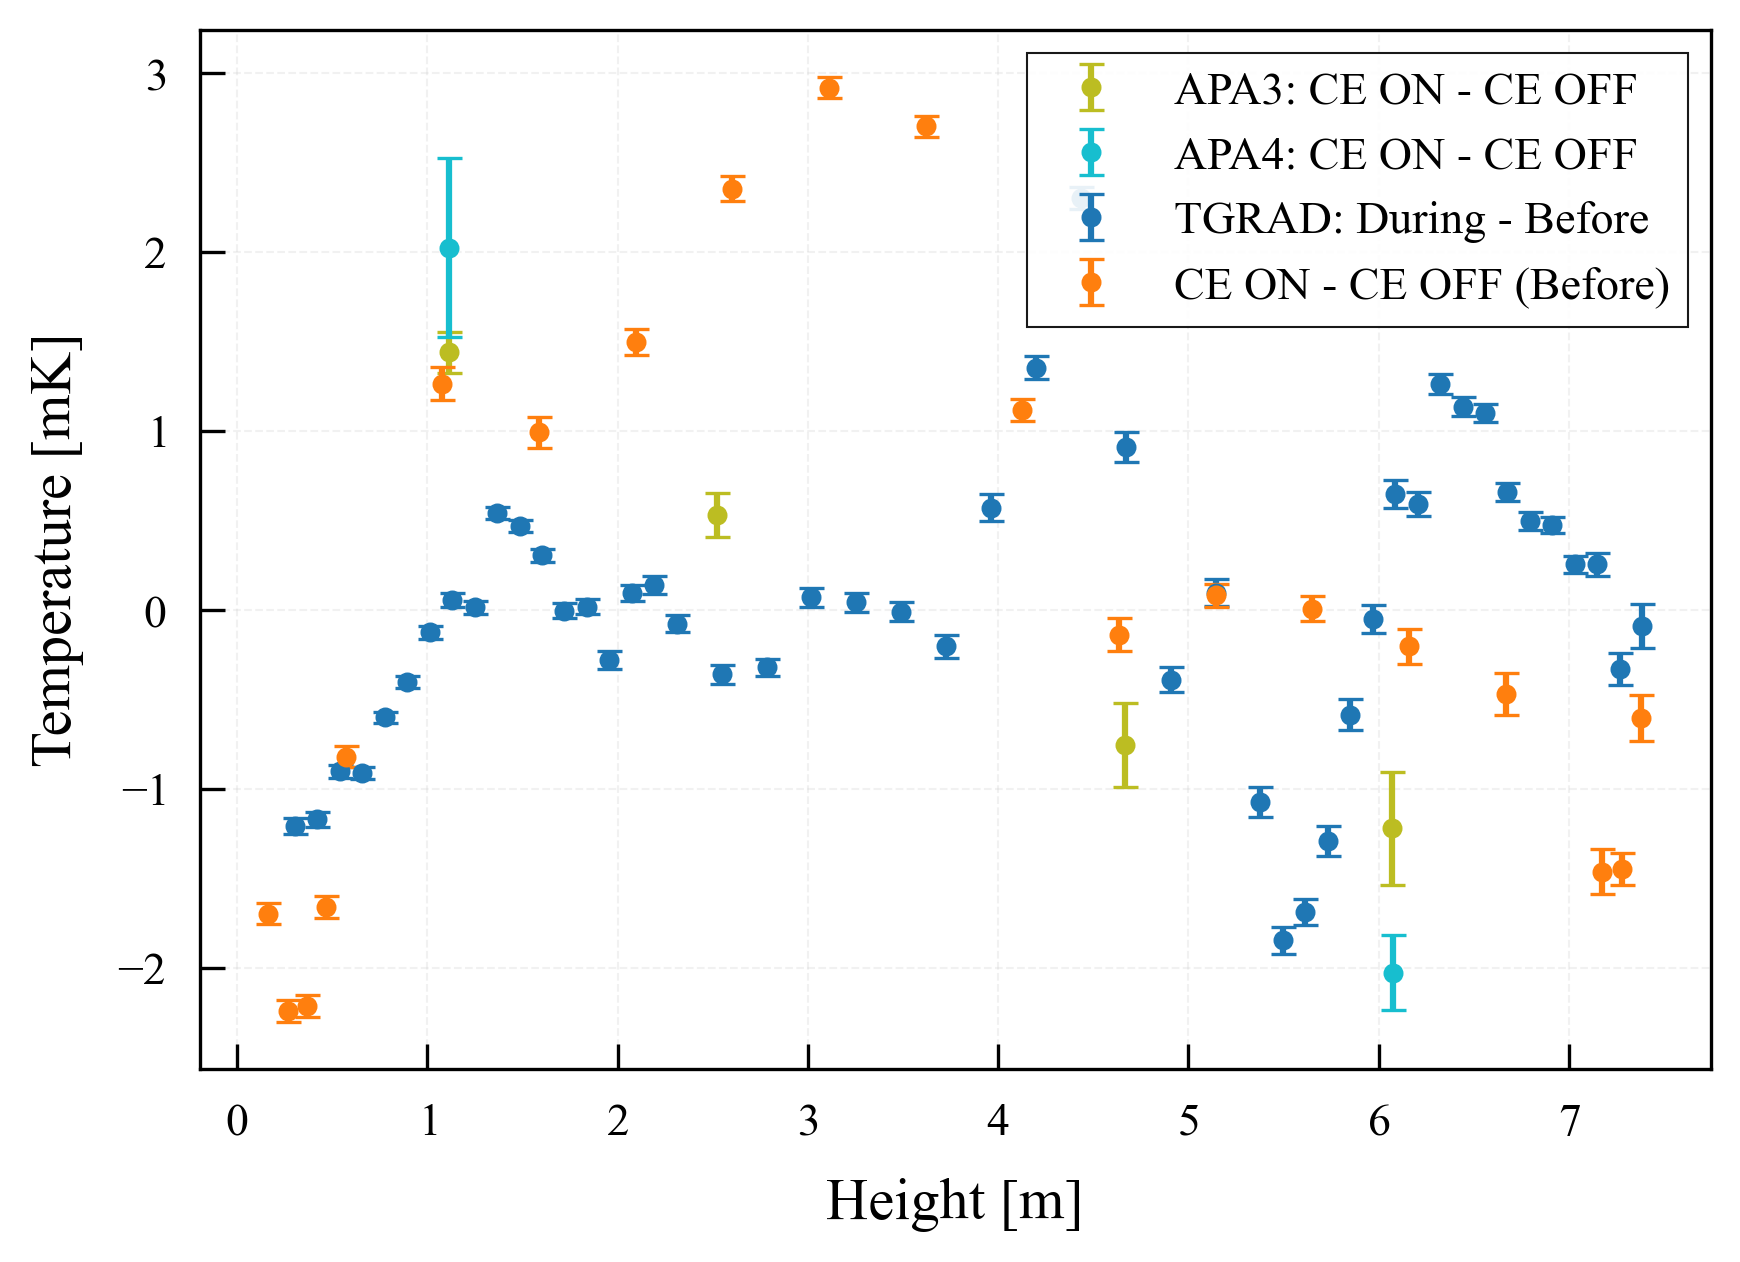

In [11]:
fig, axes = plt.subplots(1,1)
# axes.errorbar(1e-3*apa1_pre["Y"].values, 1e3*(apa1_during["temp"] - apa1_pre["temp"]).values - 1e3*(apa1_during["temp"] - apa1_pre["temp"]).mean(), yerr=1e3*np.sqrt(apa1_pre["err"].values**2 + apa1_during["err"].values**2)/np.sqrt(len(apa1_pre["temp"])), marker="o", linestyle="None", color="tab:gray", label="APA1: CE ON - CE OFF")
# axes.errorbar(1e-3*apa2_pre["Y"].values, 1e3*(apa2_during["temp"] - apa2_pre["temp"]).values - 1e3*(apa2_during["temp"] - apa2_pre["temp"]).mean(), yerr=1e3*np.sqrt(apa2_pre["err"].values**2 + apa2_during["err"].values**2)/np.sqrt(len(apa2_pre["temp"])), marker="o", linestyle="None", color="tab:pink", label="APA2: CE ON - CE OFF")
axes.errorbar(1e-3*apa3_pre["Y"].values, 1e3*(apa3_during["temp"] - apa3_pre["temp"]).values - 1e3*(apa3_during["temp"] - apa3_pre["temp"]).mean(), yerr=1e3*np.sqrt(apa3_pre["err"].values**2 + apa3_during["err"].values**2)/np.sqrt(len(apa3_pre["temp"])), marker="o", linestyle="None", color="tab:olive", label="APA3: CE ON - CE OFF")
axes.errorbar(1e-3*apa4_pre["Y"].values, 1e3*(apa4_during["temp"] - apa4_pre["temp"]).values - 1e3*(apa4_during["temp"] - apa4_pre["temp"]).mean(), yerr=1e3*np.sqrt(apa4_pre["err"].values**2 + apa4_during["err"].values**2)/np.sqrt(len(apa4_pre["temp"])), marker="o", linestyle="None", color="tab:cyan", label="APA4: CE ON - CE OFF")
axes.errorbar(1e-3*pre_tgrad["Y"].values, 1e3*(during_tgrad["temp"] - pre_tgrad["temp"]) - 1e3*(during_tgrad["temp"] - pre_tgrad["temp"]).mean(), yerr=1e3*np.sqrt(pre_tgrad["err"].values**2 + during_tgrad["err"].values**2)/np.sqrt(len(pre_tgrad["temp"])), marker="o", linestyle="None", label="TGRAD: During - Before")
axes.errorbar(1e-3*pre_hawai["Y"].values, 1e3*(during_hawai["temp"].values - pre_hawai["temp"].values - (during_hawai["temp"] - pre_hawai["temp"]).mean()), yerr=1e3*np.sqrt(pre_hawai["err"].values**2 + during_hawai["err"].values**2)/np.sqrt(len(pre_hawai["temp"])), marker="o", linestyle="None", label="CE ON - CE OFF (Before)")

axes.set_xlabel("Height [m]")
axes.set_ylabel("Temperature [mK]")
axes.legend(ncol=1)
# fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/SENSITIVITY/CEON-CEOFF_hawaii_apa.png")